# **1. Load and process data**

### 1.1. Parameters, packages and paths

In [1]:
# Core constants
CRUDE_BARREL_TO_TONS = 7.33  # barrel of crude per ton
BUFFER_KM = 10  # km radius for spatial buffer queries

discount_rate = 0.03 #OnStove uses 0.03 for social perspective, 0.15 for private perspective

# Ports parameters
STS_cost = 0.1  # US$/kg
pre_bottling_cost = 0.2  # 20% TO BE MODIFIED

# Border points parameters
border_point_time_hours = 39
ferry_cost_per_km = 0.78  # US$/ton/straight line km
ferry_time_per_km = 0.071  # hours/straight line km

# Driver parameters
driver_annual_salary_usd = 2604
salary_multiplier = 1.18
hours_per_day = 8 # working hours per day
days_per_year = 330 # working days per year

# Tankers parameters
tanker_capacity_kg = 24000
utilization_factor = 0.85
variable_cost_per_km = 0.635
tanker_overnight_cost_usd = 197673 
tanker_life_years = 35
license_cost_usd = 418
licence_life_years = 5
fixed_loading_unloading_hours = 1.0
tanker_annual_km = 42000 

# Stove parameters (OnStove defaults) (used for storage cost calculation and capacity estimation)
meals_per_day = 1.0
energy_per_meal_mj = 3.64
efficiency = 0.5
energy_content_mj_per_kg = 45.5
density_kg_per_l = 0.5
kg_per_m3 = 1000.0 * density_kg_per_l

# primary storage cost calculation options
USE_DEFAULT_RESIDENCE_TIME = True # Set to True for a fixed 15-day residence time
USE_DIFFERENTIATED_STORAGE_COSTS = False # Set to True for V1 (differentiated), False for V2 (average)

# Storage parameters
storage_overnight_cost_usd_kg = 12.5
storage_installation_fee = 760.0
storage_license_cost_usd = 3952.0
storage_life_years = 50
storage_license_life_years = 3
discount_rate_storage = float(globals().get("discount_rate", 0.03))
storage_cap = 0.25 #US$/kg, maximum price for storage cost, used to cap outliers in the data when USE_DIFFERENTIATED_STORAGE_COSTS is True

# Core dependencies for tabular, spatial, and raster work
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt 
import numpy as np
import rasterio
from rasterio.mask import mask as raster_mask
import shapely
from shapely.geometry import Point, box, shape, LineString
from skimage.graph import MCP_Geometric
from pyproj import Geod, CRS
from onstove.layer import VectorLayer, RasterLayer
from shapely.ops import nearest_points
from scipy.optimize import linprog
from openpyxl import Workbook
import warnings
from __future__ import annotations
import contextlib
import heapq
import io
import json
import math
import os
import shutil
import sqlite3
import time
from pathlib import Path
from typing import Dict, List, Sequence, Tuple, Optional
import rioxarray
import xarray as xr
from onstove import OnStove
from rasterio.features import geometry_mask, shapes
from rasterio.transform import rowcol
from rasterio.warp import Resampling, reproject, transform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree

# Workspace data folder 
data_dir = Path("dataset")
data_dir.mkdir(exist_ok=True)

# Default gpkg and layer names used when user files are missing
DEFAULT_GPKG = data_dir / "default.gpkg"
DEFAULT_LAYERS = {
    'refineries': 'refineries',
    'ports': 'ports',
    'gas_plants': 'gas_plants',
    'primary_storage': 'primary_storage',
    'border_points': 'border_points',
}

# Define mask layer
mask_layer = gpd.read_file(data_dir / "mask_layer.gpkg")

In [2]:
#if you want to skip, you need to have in the folder the file 
#huff_preferred_distributor_per_pixel.tif; filling_point_clients.gpkg; chain_with_cost.gpkg; sell_point_clients.gpkg
SKIP_SPATIAL_ALLOCATION = False  #boost the time of run


DATA_DIR = Path("dataset")
MODEL_PICKLE_PATH = DATA_DIR / ".." / ".." / ".." / "example" / "NGA_brutal" / "model_inputs.pkl"  # Onstove
SCENARIO_CSV_PATH = DATA_DIR / ".." / ".." / ".." / "example" / "soc_specs.csv"  # Onstove
INCOME_RASTER_PATH = DATA_DIR / "income_nigeria.tif"  # generated in 4.1
VEHICLE_POSSIBILITY_PATH = DATA_DIR / "vehicle_possibility.tif"  # generated in 4.1
VEHICLES_SHARE_PATH = DATA_DIR / "vehicles_allocation_share.tif"  # generated in 4.1
WALK_SHARE_PATH = DATA_DIR / "walk_allocation_share.tif"  # generated in 4.1
VEHICLES_N_PATH = DATA_DIR / "vehicles_allocation_n_effettivo.tif"  # generated in 4.1
POPULATION_RASTER_PATH = DATA_DIR / "Population.tif"  # Onstove
URBAN_RASTER_PATH = DATA_DIR / "Urban.tif"  # Onstove
COUNTRY_BOUNDARIES_PATH = DATA_DIR / "Country_boundaries.geojson"  # Onstove
FRICTION_WALK_PATH = DATA_DIR / "friction_walk.tif"  # Onstove
FRICTION_MOTO_PATH = DATA_DIR / "friction_moto.tif"  # Onstove
FULL_CHAIN_GPKG_PATH = DATA_DIR / "full_lpg_chain_nig_3857.gpkg"  # generated in 3
HUFF_PIXEL_RASTER_PATH = DATA_DIR / "huff_preferred_distributor_per_pixel.tif"  # generated in 4.2
HUFF_LOOKUP_CSV_PATH = DATA_DIR / "huff_reseller_lookup.csv"  # generated in 4.2
HUFF_PROFILE_JSON_PATH = DATA_DIR / "huff_run_profile.json"  # generated in 4.2
LPG_USE_SHARE_PATH = DATA_DIR / "lpg_use_share.tif"  # generated in 4.3
SELL_POINT_GPKG_PATH = DATA_DIR / "sell_point_clients.gpkg"  # generated in 4.3
CHAIN_WITH_COST_PATH = DATA_DIR / "chain_with_cost.gpkg"  # generated in 4.4/4.5
FILLING_POINT_CLIENTS_GPKG_PATH = DATA_DIR / "filling_point_clients.gpkg"  # generated in 4.4
ASSIGNED_COST_GPKG_PATH = DATA_DIR / "first_step.gpkg"  # supply parts
END_USER_PRICE_PATH = DATA_DIR / "end_user_price.tif"  # generated in 4.6
DATA_DIR.mkdir(parents=True, exist_ok=True)
essential_inputs = [
    MODEL_PICKLE_PATH,
    SCENARIO_CSV_PATH,
    POPULATION_RASTER_PATH,
    URBAN_RASTER_PATH,
    COUNTRY_BOUNDARIES_PATH,
    FRICTION_WALK_PATH,
    FRICTION_MOTO_PATH,
    FULL_CHAIN_GPKG_PATH,
    #ASSIGNED_COST_GPKG_PATH,
]
missing_inputs = [p for p in essential_inputs if not p.exists()]
if missing_inputs:
    raise FileNotFoundError("Missing essential input file(s): " + ", ".join(str(p) for p in missing_inputs))
save_outputs = {
    "income_nigeria.tif": False,
    "vehicle_possibility.tif": False,
    "vehicles_allocation_share.tif": False,
    "walk_allocation_share.tif": False,
    "vehicles_allocation_n_effettivo.tif": False,
    "huff_preferred_distributor_per_pixel.tif": True,
    "huff_reseller_lookup.csv": False,
    "huff_run_profile.json": False,
    "lpg_use_share.tif": False,
    "sell_point_clients.gpkg": True,
    "chain_with_cost.gpkg": True,  # redundant: all relevant data now written to first_step.gpkg
    "filling_point_clients.gpkg": True,
    "end_user_price.tif": True,
    #note first.step is corretly always true and contains the update data
}
memory_store = {
    "rasters": {},
    "rasters_da": {},
    "vectors": {},
    "tables": {},
    "json": {},
}
def _key_from_path(path: str | Path) -> str:
    return Path(path).name
def _cache_raster(path: str | Path, array: np.ndarray, profile: dict, nodata=None, descriptions=None) -> None:
    key = _key_from_path(path)
    memory_store["rasters"][key] = {
        "array": np.array(array, copy=True),
        "profile": profile.copy(),
        "nodata": nodata,
        "descriptions": list(descriptions) if descriptions is not None else None,
    }
def _get_profile_for_cache(path: str | Path, da) -> dict:
    if path is not None and os.path.exists(path):
        with rasterio.open(path) as src:
            return src.profile
    height = int(da.shape[-2])
    width = int(da.shape[-1])
    count = int(da.shape[0]) if da.ndim == 3 else 1
    return {
        "driver": "GTiff",
        "dtype": str(da.dtype),
        "nodata": da.rio.nodata,
        "width": width,
        "height": height,
        "count": count,
        "crs": da.rio.crs,
        "transform": da.rio.transform(),
    }
def _release_raster_handle(path: str | Path) -> None:
    key = _key_from_path(path)
    cached = memory_store["rasters_da"].pop(key, None)
    if cached is None:
        return
    if hasattr(cached, "close"):
        try:
            cached.close()
        except Exception:
            pass
    if hasattr(cached, "rio") and hasattr(cached.rio, "close"):
        try:
            cached.rio.close()
        except Exception:
            pass
def _get_descriptions_for_cache(path: str | Path, da):
    if path is not None and os.path.exists(path):
        with rasterio.open(path) as src:
            return list(src.descriptions) if src.descriptions is not None else None
    if hasattr(da, "rio") and hasattr(da.rio, "descriptions"):
        return da.rio.descriptions
    return None
def _cache_raster_da(path: str | Path, da) -> None:
    key = _key_from_path(path)
    memory_store["rasters_da"][key] = da
def _read_cached_raster(path: str | Path):
    return memory_store["rasters"].get(_key_from_path(path))
def _open_raster_da(path: str | Path):
    key = _key_from_path(path)
    cached = memory_store["rasters_da"].get(key)
    if cached is not None:
        return cached
    return rioxarray.open_rasterio(path)
def _cache_gpkg_layer(path: str | Path, layer: str, gdf: gpd.GeoDataFrame) -> None:
    key = _key_from_path(path)
    entry = memory_store["vectors"].setdefault(key, {})
    layers = entry.setdefault("layers", {})
    layers[layer] = gdf.copy()
def _read_gpkg_layer(path: str | Path, layer: str) -> gpd.GeoDataFrame:
    key = _key_from_path(path)
    entry = memory_store["vectors"].get(key)
    if entry is not None:
        layers = entry.get("layers", {})
        if layer in layers:
            return layers[layer].copy()
    return gpd.read_file(path, layer=layer)
def _write_gpkg_layer(path: str | Path, layer: str, gdf: gpd.GeoDataFrame) -> None:
    _cache_gpkg_layer(path, layer, gdf)
    if save_outputs.get(_key_from_path(path), True):
        gdf.to_file(path, layer=layer, driver="GPKG")
def _write_csv(path: str | Path, df: pd.DataFrame) -> None:
    key = _key_from_path(path)
    memory_store["tables"][key] = df.copy()
    if save_outputs.get(key, True):
        df.to_csv(path, index=False)
def _write_json(path: str | Path, payload: dict) -> None:
    key = _key_from_path(path)
    memory_store["json"][key] = payload
    if save_outputs.get(key, True):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
def _read_multiband_raster(path: str | Path):
    cached = _read_cached_raster(path)
    if cached is not None:
        arr = cached["array"]
        desc = cached.get("descriptions")
        nodata = cached.get("nodata")
        return arr, desc, nodata
    with rasterio.open(path) as src:
        arr = src.read()
        desc = list(src.descriptions)
        nodata = src.nodata
    return arr, desc, nodata

def _read_raster_base(path: str | Path, positive_only: bool = False):
    """Shared raster read logic for _read_raster and _read_friction."""
    cached = _read_cached_raster(path)
    if cached is not None:
        arr = cached["array"]
        if arr.ndim == 3:
            arr = arr[0]
        arr = arr.astype(np.float32, copy=False)
        nodata = cached.get("nodata")
        profile = cached["profile"].copy()
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr).astype(np.float32)
    else:
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32, copy=False)
            nodata = src.nodata
            profile = src.profile.copy()
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr).astype(np.float32)
    if positive_only:
        arr = np.where(arr > 0, arr, np.nan).astype(np.float32)
    return arr, profile, nodata


def _read_raster(path: str | Path):
    return _read_raster_base(path, positive_only=False)


def _read_friction(path: Path):
    arr, profile, _ = _read_raster_base(path, positive_only=True)
    return arr, profile


def _map_points_to_grid(gdf: gpd.GeoDataFrame, transform, width: int, height: int):
    rows, cols = rasterio.transform.rowcol(
        transform, gdf.geometry.x.values, gdf.geometry.y.values
    )
    rows = np.asarray(rows, dtype=np.int32)
    cols = np.asarray(cols, dtype=np.int32)
    inside = (rows >= 0) & (rows < height) & (cols >= 0) & (cols < width)
    return rows, cols, inside

def _safe_ratio(num: float, den: float) -> float:
    """Return num/den, or 0.0 if den == 0."""
    return float(num / den) if den else 0.0

def _print_progress(
    mode: str,
    assigned: int,
    total: int,
    elapsed: float,
) -> None:
    """Print progress with speed and ETA."""
    if total <= 0:
        return
    pct = 100.0 * assigned / total
    rate = _safe_ratio(assigned, elapsed)
    remaining = max(total - assigned, 0)
    eta_sec = _safe_ratio(remaining, max(rate, 1e-12))
    print(
        f"[{mode}] {assigned:,}/{total:,} ({pct:.2f}%) | "
        f"{rate:.1f} px/s | ETA {eta_sec/60:.1f} min"
    )

def read_reference_population(path: Path) -> Tuple[np.ndarray, Dict]:
    """Read population raster and return array + profile."""
    cached = _read_cached_raster(path)
    if cached is not None:
        arr = cached["array"]
        if arr.ndim == 3:
            arr = arr[0]
        pop = arr.astype(np.float32)
        profile = cached["profile"].copy()
        return pop, profile
    with rasterio.open(path) as src:
        pop = src.read(1).astype(np.float32)
        profile = src.profile.copy()
    return pop, profile

def reproject_to_reference(
    src_path: Path,
    ref_profile: Dict,
    resampling: Resampling,
) -> np.ndarray:
    """Reproject (or resample) a raster to match the reference grid."""
    cached = _read_cached_raster(src_path)
    dst = np.full(
        (ref_profile["height"], ref_profile["width"]),
        np.nan,
        dtype=np.float32,
    )
    if cached is not None:
        src_arr = cached["array"]
        if src_arr.ndim == 3:
            src_arr = src_arr[0]
        reproject(
            source=src_arr,
            destination=dst,
            src_transform=cached["profile"]["transform"],
            src_crs=cached["profile"]["crs"],
            src_nodata=cached.get("nodata"),
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
        )
        return dst
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
        )
    return dst

def normalize_car_share(arr: np.ndarray) -> np.ndarray:
    """Convert car share to fraction (0–1). Assumes input may be 0–100."""
    out = arr.astype(np.float32, copy=True)
    finite = np.isfinite(out)
    if finite.any():
        vmax = float(np.nanmax(out[finite]))
        if vmax > 1.0 + 1e-4 and vmax <= 100.0 + 1e-4:
            out[finite] = out[finite] / 100.0
    out[~finite] = 0.0
    np.clip(out, 0.0, 1.0, out=out)
    return out

def sanitize_friction(arr: np.ndarray) -> np.ndarray:
    """Set non‑positive or non‑finite friction to NaN."""
    out = arr.astype(np.float32, copy=True)
    invalid = ~np.isfinite(out) | (out <= 0.0)
    out[invalid] = np.nan
    return out

def connected_components_8(mask: np.ndarray) -> np.ndarray:
    """
    Label 8‑connected components of True cells.
    Returns an integer array (0 = background).
    Falls back to pure Python if scipy is not available.
    """
    # Try to use scipy first (much faster)
    try:
        from scipy import ndimage
        structure = np.ones((3, 3), dtype=np.uint8)
        labels, _ = ndimage.label(mask, structure=structure)
        return labels.astype(np.int32)
    except ImportError:
        # Fallback pure Python implementation
        h, w = mask.shape
        labels = np.zeros((h, w), dtype=np.int32)
        current = 0
        stack = []
        for r in range(h):
            for c in range(w):
                if not mask[r, c] or labels[r, c] != 0:
                    continue
                current += 1
                labels[r, c] = current
                stack.append((r, c))
                while stack:
                    rr, cc = stack.pop()
                    for dr, dc, _ in NEIGHBORS:
                        nr, nc = rr + dr, cc + dc
                        if nr < 0 or nr >= h or nc < 0 or nc >= w:
                            continue
                        if not mask[nr, nc] or labels[nr, nc] != 0:
                            continue
                        labels[nr, nc] = current
                        stack.append((nr, nc))
        return labels

def load_reseller_seeds(
    gpkg_path: Path,
    layer: str,
    id_col: str,
    attr_col: str,
    ref_profile: Dict,
) -> List[Dict]:
    """
    Load reseller points, reproject to reference CRS, and keep only those
    falling inside the raster extent. If multiple points map to the same pixel,
    keep the most attractive one.
    Returns a list of dicts with keys: reseller_id, attractiveness, row, col.
    """
    gdf = gpd.read_file(gpkg_path, layer=layer)
    if gdf.empty:
        raise ValueError("Reseller layer is empty.")
    ref_crs = ref_profile["crs"]
    if gdf.crs is None:
        raise ValueError("Reseller GeoPackage has no CRS.")
    if gdf.crs != ref_crs:
        gdf = gdf.to_crs(ref_crs)
    # Clean IDs and attractiveness
    ids = pd.to_numeric(gdf[id_col], errors="coerce")
    attrs = pd.to_numeric(gdf[attr_col], errors="coerce")
    attrs = attrs.fillna(ATTR_MIN).clip(lower=ATTR_MIN)
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()
    rows, cols = rowcol(ref_profile["transform"], xs, ys)
    h, w = ref_profile["height"], ref_profile["width"]
    seeds_dict = {}
    for rid, attr, r, c in zip(ids, attrs, rows, cols):
        if not np.isfinite(rid):
            continue
        rr = int(r)
        cc = int(c)
        if rr < 0 or rr >= h or cc < 0 or cc >= w:
            continue
        key = (rr, cc)
        candidate = {
            "reseller_id": float(rid),
            "attractiveness": float(attr),
            "row": rr,
            "col": cc,
        }
        prev = seeds_dict.get(key)
        if prev is None or candidate["attractiveness"] > prev["attractiveness"]:
            seeds_dict[key] = candidate
    seeds = list(seeds_dict.values())
    if not seeds:
        raise ValueError("No reseller seed mapped onto the reference grid.")
    return seeds

def run_multisource_dijkstra(
    mode_name: str,
    friction: np.ndarray,
    traversable: np.ndarray,
    target_mask: np.ndarray,
    labels: np.ndarray,
    seeds: List[Dict],
    pixel_size_m: float,
    log_every: int | None = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]:
    """
    Multi‑source Dijkstra con Huff‑style scoring (β=2).
    Returns:
        best_seed_idx : 2D array of seed indices (or -1)
        best_time_min : 2D array of travel times in minutes (or inf)
        best_dist_km  : 2D array of path distance in km (or inf)
        assigned      : number of target pixels assigned
        elapsed_sec   : solver wall time
    """
    if log_every is None:
        log_every = LOG_EVERY
    h, w = friction.shape
    n_seeds = len(seeds)
    # Precompute source data
    seed_rows = np.array([s["row"] for s in seeds], dtype=np.int32)
    seed_cols = np.array([s["col"] for s in seeds], dtype=np.int32)
    sqrt_attr = np.array(
        [math.sqrt(max(s["attractiveness"], ATTR_MIN)) for s in seeds],
        dtype=np.float64,
    )
    # Determine which connected components contain at least one seed
    seed_labels = labels[seed_rows, seed_cols]
    max_label = labels.max()
    has_seed = np.zeros(max_label + 1, dtype=bool)
    has_seed[seed_labels[seed_labels > 0]] = True
    # State arrays
    best_adj = np.full((h, w), np.inf, dtype=np.float64)   # adjusted time
    best_time = np.full((h, w), np.inf, dtype=np.float64)  # raw time (minutes)
    best_dist = np.full((h, w), np.inf, dtype=np.float64)  # distance (km)
    best_seed = np.full((h, w), -1, dtype=np.int32)
    finalized = np.zeros((h, w), dtype=bool)
    # Priority queue: (adj_time, row, col, seed_idx)
    heap = []
    for si in range(n_seeds):
        r = seed_rows[si]
        c = seed_cols[si]
        if not traversable[r, c]:
            continue
        # At source pixel, tie‑break in favour of higher attractiveness
        if (0.0 < best_adj[r, c]) or (
            best_adj[r, c] == 0.0
            and best_seed[r, c] >= 0
            and sqrt_attr[si] > sqrt_attr[best_seed[r, c]]
        ):
            best_adj[r, c] = 0.0
            best_time[r, c] = 0.0
            best_dist[r, c] = 0.0
            best_seed[r, c] = si
            heapq.heappush(heap, (0.0, r, c, si))
    total_targets = int(np.count_nonzero(target_mask & traversable))
    assigned = 0
    t_start = time.perf_counter()
    last_log = 0
    while heap and assigned < total_targets:
        adj, r, c, si = heapq.heappop(heap)
        if finalized[r, c]:
            continue
        if adj > best_adj[r, c]:
            continue
        finalized[r, c] = True
        if target_mask[r, c]:
            assigned += 1
            if assigned - last_log >= log_every:
                _print_progress(
                    mode_name,
                    assigned,
                    total_targets,
                    time.perf_counter() - t_start,
                )
                last_log = assigned
        inv_scale = 1.0 / sqrt_attr[si]
        t_curr = best_time[r, c]
        d_curr = best_dist[r, c]
        for dr, dc, dist_factor in NEIGHBORS:
            nr = r + dr
            nc = c + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            if finalized[nr, nc] or not traversable[nr, nc]:
                continue
            # Edge cost: average friction × distance (metres) → minutes
            edge_time = float(
                0.5 * (friction[r, c] + friction[nr, nc])
                * (pixel_size_m * dist_factor)
            )
            t_new = t_curr + edge_time
            adj_new = t_new * inv_scale
            # Distance in km (geometric, independent of friction)
            edge_km = (pixel_size_m * dist_factor) / 1000.0
            d_new = d_curr + edge_km
            # Lexicographic tie‑break: lower adjusted time, then lower raw time
            if (adj_new + 1e-12) < best_adj[nr, nc] or (
                abs(adj_new - best_adj[nr, nc]) <= 1e-12
                and t_new < best_time[nr, nc]
            ):
                best_adj[nr, nc] = adj_new
                best_time[nr, nc] = t_new
                best_dist[nr, nc] = d_new
                best_seed[nr, nc] = si
                heapq.heappush(heap, (adj_new, nr, nc, si))
    # -------------------------------------------------------------------------
    # Component‑aware fallback
    # -------------------------------------------------------------------------
    unassigned = target_mask & traversable & (best_seed < 0)
    eligible = unassigned & has_seed[labels]
    fallback_hits = 0
    if np.any(eligible):
        unique_lbls = np.unique(labels[eligible])
        for lbl in unique_lbls:
            if lbl <= 0:
                continue
            comp_mask = labels == lbl
            comp_targets = eligible & comp_mask
            if not np.any(comp_targets):
                continue
            comp_seed_idx = np.where(seed_labels == lbl)[0]
            if comp_seed_idx.size == 0:
                continue
            fallback_hits += int(np.count_nonzero(comp_targets))
            # Reset state inside the component
            best_adj_comp = np.full((h, w), np.inf, dtype=np.float64)
            best_time_comp = np.full((h, w), np.inf, dtype=np.float64)
            best_dist_comp = np.full((h, w), np.inf, dtype=np.float64)
            best_seed_comp = np.full((h, w), -1, dtype=np.int32)
            finalized_comp = np.zeros((h, w), dtype=bool)
            heap_comp = []
            for si in comp_seed_idx:
                r0 = seed_rows[si]
                c0 = seed_cols[si]
                if not comp_mask[r0, c0] or not traversable[r0, c0]:
                    continue
                best_adj_comp[r0, c0] = 0.0
                best_time_comp[r0, c0] = 0.0
                best_dist_comp[r0, c0] = 0.0
                best_seed_comp[r0, c0] = si
                heapq.heappush(heap_comp, (0.0, r0, c0, si))
            while heap_comp:
                adj, r, c, si = heapq.heappop(heap_comp)
                if finalized_comp[r, c]:
                    continue
                if adj > best_adj_comp[r, c]:
                    continue
                if not comp_mask[r, c]:
                    continue
                finalized_comp[r, c] = True
                inv_scale = 1.0 / sqrt_attr[si]
                t_curr = best_time_comp[r, c]
                d_curr = best_dist_comp[r, c]
                for dr, dc, dist_factor in NEIGHBORS:
                    nr = r + dr
                    nc = c + dc
                    if nr < 0 or nr >= h or nc < 0 or nc >= w:
                        continue
                    if (
                        finalized_comp[nr, nc]
                        or not traversable[nr, nc]
                        or not comp_mask[nr, nc]
                    ):
                        continue
                    edge_time = float(
                        0.5 * (friction[r, c] + friction[nr, nc])
                        * (pixel_size_m * dist_factor)
                    )
                    t_new = t_curr + edge_time
                    adj_new = t_new * inv_scale
                    edge_km = (pixel_size_m * dist_factor) / 1000.0
                    d_new = d_curr + edge_km
                    if (adj_new + 1e-12) < best_adj_comp[nr, nc] or (
                        abs(adj_new - best_adj_comp[nr, nc]) <= 1e-12
                        and t_new < best_time_comp[nr, nc]
                    ):
                        best_adj_comp[nr, nc] = adj_new
                        best_time_comp[nr, nc] = t_new
                        best_dist_comp[nr, nc] = d_new
                        best_seed_comp[nr, nc] = si
                        heapq.heappush(heap_comp, (adj_new, nr, nc, si))
            # Merge fallback results into global arrays
            update = comp_targets & (best_seed_comp >= 0)
            best_seed[update] = best_seed_comp[update]
            best_time[update] = best_time_comp[update]
            best_dist[update] = best_dist_comp[update]
    elapsed = time.perf_counter() - t_start
    assigned_final = int(np.count_nonzero(target_mask & traversable & (best_seed >= 0)))
    _print_progress(mode_name, assigned_final, total_targets, elapsed)
    return best_seed, best_time, best_dist, assigned_final, elapsed

def seeds_to_raster(
    best_seed_idx: np.ndarray,
    best_time_min: np.ndarray,
    best_dist_km: np.ndarray,
    seeds: List[Dict],
    inhabited_mask: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert seed indices, times and distances to final rasters."""
    h, w = best_seed_idx.shape
    id_raster = np.full((h, w), NODATA, dtype=np.float32)
    time_raster = np.full((h, w), NODATA, dtype=np.float32)
    dist_raster = np.full((h, w), NODATA, dtype=np.float32)
    valid = inhabited_mask & (best_seed_idx >= 0) & np.isfinite(best_time_min)
    if np.any(valid):
        seed_ids = np.array([s["reseller_id"] for s in seeds], dtype=np.float64)
        idx = best_seed_idx[valid]
        id_raster[valid] = seed_ids[idx].astype(np.float32)
        time_raster[valid] = best_time_min[valid].astype(np.float32)
        dist_raster[valid] = best_dist_km[valid].astype(np.float32)
    return id_raster, time_raster, dist_raster

def write_multiband_raster(
    out_path: Path,
    ref_profile: Dict,
    bands: Sequence[np.ndarray],
    band_names: Sequence[str],
) -> None:
    """Write a multi‑band GeoTIFF with LZW compression and band descriptions."""
    profile = ref_profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=len(bands),
        compress="lzw",
        nodata=NODATA,
        tiled=True,
        bigtiff="IF_SAFER",
    )
    # Ensure tile sizes are multiples of 16
    h, w = profile["height"], profile["width"]
    tile_x = min(256, w)
    tile_y = min(256, h)
    tile_x = max(16, (tile_x // 16) * 16)
    tile_y = max(16, (tile_y // 16) * 16)
    profile["blockxsize"] = tile_x
    profile["blockysize"] = tile_y
    if save_outputs.get(_key_from_path(out_path), True):
        with rasterio.open(out_path, "w", **profile) as dst:
            for i, (arr, name) in enumerate(zip(bands, band_names), start=1):
                dst.write(arr.astype(np.float32), i)
                dst.set_band_description(i, name)
    _cache_raster(out_path, np.stack([b.astype(np.float32, copy=False) for b in bands], axis=0), profile, NODATA, band_names)

def recompute_exact_metrics(
    mode_name: str,
    friction: np.ndarray,
    traversable: np.ndarray,
    id_raster: np.ndarray,                # Phase‑1 assignment (IDs, NODATA elsewhere)
    phase1_time_raster: np.ndarray,       # approximate times from Phase 1 (for limit)
    seeds: List[Dict],
    pixel_size_m: float,
    time_limit_factor: float | None = None,
    log_every: int = 500,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Recompute exact travel times and distances for pixels assigned to each reseller.
    For every seed, run a single‑source Dijkstra (no finalisation) and record
    the true metrics only for pixels whose Phase‑1 assignment matches the seed.
    Early termination:
        - Stop when all assigned pixels of the current seed have been reached.
        - Alternatively, stop when the time exceeds `max_phase1_time * time_limit_factor`.
          If this second condition triggers, a warning is printed.
    Returns:
        exact_time_raster : 2D array with exact travel times (minutes, NODATA for unassigned)
        exact_dist_raster : 2D array with exact distances (km, NODATA for unassigned)
    """
    if time_limit_factor is None:
        time_limit_factor = TIME_LIMIT_FACTOR
    h, w = friction.shape
    exact_time = np.full((h, w), NODATA, dtype=np.float32)
    exact_dist = np.full((h, w), NODATA, dtype=np.float32)
    # Build mapping from seed ID to its index
    seed_id_to_idx = {}
    for si, s in enumerate(seeds):
        sid = s["reseller_id"]
        if sid not in seed_id_to_idx:
            seed_id_to_idx[sid] = si
    assigned_mask = (id_raster != NODATA) & traversable
    unique_ids = np.unique(id_raster[assigned_mask])
    n_seeds_total = len(unique_ids)
    n_processed = 0
    t_start = time.perf_counter()
    last_log = 0
    warnings_issued = set()
    print(f"[{mode_name}-exact] Processing {n_seeds_total:,} resellers...")
    for sid in unique_ids:
        si = seed_id_to_idx.get(sid)
        if si is None:
            continue
        seed = seeds[si]
        sr, sc = seed["row"], seed["col"]
        if not traversable[sr, sc]:
            continue
        target_mask = assigned_mask & (id_raster == sid)
        target_coords = np.argwhere(target_mask)  # list of (r,c)
        target_count = len(target_coords)
        if target_count == 0:
            continue
        # Determine maximum allowed time for early termination
        phase1_times = phase1_time_raster[target_mask]
        max_phase1_time = np.max(phase1_times) if len(phase1_times) > 0 else 0.0
        time_limit = max_phase1_time * time_limit_factor if max_phase1_time > 0 else np.inf
        # Dijkstra state
        dist_time = np.full((h, w), np.inf, dtype=np.float64)
        dist_dist = np.full((h, w), np.inf, dtype=np.float64)
        visited = np.zeros((h, w), dtype=bool)
        dist_time[sr, sc] = 0.0
        dist_dist[sr, sc] = 0.0
        heap = [(0.0, sr, sc)]
        reached_targets = 0
        target_set = set((r, c) for r, c in target_coords)
        while heap:
            t, r, c = heapq.heappop(heap)
            if visited[r, c]:
                continue
            visited[r, c] = True
            # If time limit exceeded (and we haven't reached all targets), stop early
            if t > time_limit and reached_targets < target_count:
                if sid not in warnings_issued:
                    print(f"  Warning: Seed {sid} exceeded time limit ({t:.1f} > {time_limit:.1f} min) "
                          f"before reaching all targets ({reached_targets}/{target_count}).")
                    warnings_issued.add(sid)
                break
            # If this cell is a target for this seed, record exact metrics
            if (r, c) in target_set:
                exact_time[r, c] = t
                exact_dist[r, c] = dist_dist[r, c]
                reached_targets += 1
                if reached_targets == target_count:
                    break  # all done
            t_curr = t
            d_curr = dist_dist[r, c]
            for dr, dc, dist_factor in NEIGHBORS:
                nr = r + dr
                nc = c + dc
                if nr < 0 or nr >= h or nc < 0 or nc >= w:
                    continue
                if visited[nr, nc] or not traversable[nr, nc]:
                    continue
                edge_time = float(
                    0.5 * (friction[r, c] + friction[nr, nc])
                    * (pixel_size_m * dist_factor)
                )
                t_new = t_curr + edge_time
                edge_km = (pixel_size_m * dist_factor) / 1000.0
                d_new = d_curr + edge_km
                if t_new < dist_time[nr, nc] - 1e-12:
                    dist_time[nr, nc] = t_new
                    dist_dist[nr, nc] = d_new
                    heapq.heappush(heap, (t_new, nr, nc))
        # End while heap
        n_processed += 1
        if n_processed - last_log >= log_every:
            elapsed = time.perf_counter() - t_start
            pct = 100.0 * n_processed / n_seeds_total
            rate = _safe_ratio(n_processed, elapsed)
            remaining = n_seeds_total - n_processed
            eta = _safe_ratio(remaining, max(rate, 1e-12))
            print(
                f"[{mode_name}-exact] {n_processed:,}/{n_seeds_total:,} resellers done "
                f"({pct:.1f}%) | {rate:.1f} res/s | ETA {eta/60:.1f} min"
            )
            last_log = n_processed
    # End loop over seeds
    elapsed = time.perf_counter() - t_start
    print(f"[{mode_name}-exact] All resellers processed. Assigned pixels recomputed.")
    return exact_time, exact_dist

def _read_pixel_preference_raster(path: str) -> dict[str, np.ndarray]:
    cached = _read_cached_raster(path)
    if cached is not None:
        arr = cached["array"]
        if arr.ndim == 2:
            raise RuntimeError(f"Expected at least 7 bands in {path}, found 1.")
        if arr.shape[0] < 7:
            raise RuntimeError(f"Expected at least 7 bands in {path}, found {arr.shape[0]}.")
        nodata = cached.get("nodata")
        arr = arr.astype(np.float32, copy=False)
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr).astype(np.float32)
        return {
            "car_share": arr[0],
            "walk_share": arr[1],
            "best_reseller_id_walk": arr[2],
            "best_time_walk_min": arr[3],
            "best_reseller_id_car": arr[5],
            "best_time_car_min": arr[6],
        }
    with rasterio.open(path) as src:
        if src.count < 7:   # almeno fino a banda 7 (best_time_car_min)
            raise RuntimeError(f"Expected at least 7 bands in {path}, found {src.count}.")
        # Leggi le bande nell'ordine corretto:
        # 1: car_share, 2: walk_share, 3: best_reseller_id_walk, 4: best_time_walk_min,
        # 6: best_reseller_id_car, 7: best_time_car_min
        # (saltiamo banda 5: distanza walk, banda 8: distanza car)
        arr = src.read(indexes=[1, 2, 3, 4, 6, 7]).astype(np.float32, copy=False)
        nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr).astype(np.float32)
    return {
        "car_share": arr[0],
        "walk_share": arr[1],
        "best_reseller_id_walk": arr[2],
        "best_time_walk_min": arr[3],
        "best_reseller_id_car": arr[4],
        "best_time_car_min": arr[5],
    }

def _read_reseller_ids(gdf: gpd.GeoDataFrame) -> np.ndarray:
    if RESELLER_ID_COLUMN not in gdf.columns:
        raise KeyError(f"Missing column '{RESELLER_ID_COLUMN}' in reseller layer.")
    rid = pd.to_numeric(gdf[RESELLER_ID_COLUMN], errors="coerce")
    if rid.isna().any():
        raise ValueError(f"Column '{RESELLER_ID_COLUMN}' contains non-numeric values.")
    if (rid <= 0).any():
        raise ValueError(f"Column '{RESELLER_ID_COLUMN}' must contain positive values.")
    if not rid.is_unique:
        raise ValueError(f"Column '{RESELLER_ID_COLUMN}' must be unique in layer '{RESELLER_LAYER}'.")
    return rid.astype(np.int64).to_numpy()

def _write_float_raster(path: str, array: np.ndarray, ref_profile: dict):
    profile = ref_profile.copy()
    profile.update(dtype="float32", count=1, nodata=NODATA_FLOAT, compress="lzw")
    out = np.where(np.isfinite(array), array, NODATA_FLOAT).astype(np.float32)
    if save_outputs.get(_key_from_path(path), True):
        with rasterio.open(path, "w", **profile) as dst:
            dst.write(out, 1)
    _cache_raster(path, out, profile, NODATA_FLOAT, None)

def _map_effective_cost(ids_int: np.ndarray, map_resell: dict[int, float], map_filling: dict[int, float]) -> np.ndarray:
    out = np.full(ids_int.shape, np.nan, dtype=np.float64)
    valid = ids_int > 0
    if not np.any(valid):
        return out
    uniq, inv = np.unique(ids_int[valid], return_inverse=True)
    mapped = np.fromiter((map_resell.get(int(rid), np.nan) for rid in uniq), dtype=np.float64, count=uniq.size)
    miss = ~np.isfinite(mapped)
    if np.any(miss):
        miss_ids = uniq[miss]
        mapped[miss] = np.fromiter((map_filling.get(int(rid), np.nan) for rid in miss_ids), dtype=np.float64, count=miss_ids.size)
    out_valid = mapped[inv]
    out[valid] = out_valid
    return out

def _read_single_band(path: Path) -> tuple[np.ndarray, dict]:
    arr, profile, _ = _read_raster(path)
    return arr, profile

### [FUNCTIONS DEFINITION] data loading and fill missing values

In [3]:
def _as_vector_layer(gdf, name="mask"):
    """
    Wrap a GeoDataFrame in a VectorLayer for in-memory masking.
    Avoids writing temporary files and keeps attributes intact.
    Returns a VectorLayer ready for VectorLayer.mask.
    """
    vect = VectorLayer(name=name)
    vect.data = gdf.copy()
    return vect


def load_raster_means(raster_path, band_names, mask_gdf):
    """
    Clip each band by mask and compute mean values.
    Returns a single-column DataFrame indexed by band names.
    Raises if any band has no valid pixels inside the mask.
    """
    if not raster_path.exists():
        raise FileNotFoundError(f"Missing raster file: {raster_path}")

    if mask_gdf.crs is None:
        raise ValueError("mask_layer has no CRS")

    mask_vect = _as_vector_layer(mask_gdf, name="mask_layer")
    values = {}

    for band_idx, band_name in enumerate(band_names, start=1):
        raster = RasterLayer(name=f"{raster_path.stem}_{band_name}", path=str(raster_path), band=band_idx)
        raster.mask(mask_vect, crop=True, all_touched=False)

        arr = raster.data.astype(np.float64)
        nodata = raster.meta.get('nodata')
        if nodata is not None:
            if pd.notna(nodata):
                arr[arr == nodata] = np.nan

        mean_val = np.nanmean(arr)
        if np.isnan(mean_val):
            raise ValueError(
                f"Band '{band_name}' in {raster_path.name} has no valid data inside mask_layer"
            )
        values[band_name] = float(mean_val)

    result = pd.DataFrame.from_dict(values, orient='index')
    result.columns = [1]
    return result


def load_or_use_default(gpkg_name, default_gpkg_path, default_layer_name, mask_gdf, data_dir=data_dir):
    """
    Load a layer from user data or defaults, then clip it to mask_gdf.
    Returns a GeoDataFrame with a stable id_supply column.
    No files are written during the fallback path.
    """
    gpkg_path = data_dir / f"{gpkg_name}.gpkg"
    mask_vect = _as_vector_layer(mask_gdf, name="mask_layer")

    if gpkg_path.exists():
        # Phase 1: User data found
        layer = VectorLayer(name=gpkg_name, path=str(gpkg_path))
        layer.mask(mask_vect, keep_geom_type=False)
        gdf = layer.data
        gdf = gdf.reset_index(drop=True)
        gdf['id_supply'] = f"{gpkg_name}_" + gdf.index.astype(str)
        print(f"{gpkg_name}: loaded and clipped in memory ({len(gdf)} records)")
        return gdf

    # Phase 2: Use default.gpkg layer and clip with mask_layer (no file creation)
    if not default_gpkg_path.exists():
        raise FileNotFoundError(f"Missing default gpkg: {default_gpkg_path}")

    default_gdf = gpd.read_file(default_gpkg_path, layer=default_layer_name)
    default_layer = _as_vector_layer(default_gdf, name=gpkg_name)
    default_layer.mask(mask_vect, keep_geom_type=False)

    gdf = default_layer.data
    gdf = gdf.reset_index(drop=True)
    gdf['id_supply'] = f"{gpkg_name}_" + gdf.index.astype(str)
    print(f"{gpkg_name}: clipped from default.gpkg/{default_layer_name} in memory ({len(gdf)} records)")
    return gdf


def load_border_points_or_default(mask_gdf, data_dir=data_dir, near_km=5):
    """
    Load border points, then keep, snap, or drop by distance to mask_gdf.
    Points within near_km get snapped to the mask boundary.
    Returns a GeoDataFrame with id_supply and original attributes.
    """
    user_path = data_dir / "border_points.gpkg"

    if user_path.exists():
        try:
            points = gpd.read_file(user_path, layer="border_points")
        except Exception:
            points = gpd.read_file(user_path)
        source_name = f"{user_path.name}"
    else:
        if not DEFAULT_GPKG.exists():
            raise FileNotFoundError(f"Missing default gpkg: {DEFAULT_GPKG}")
        points = gpd.read_file(DEFAULT_GPKG, layer=DEFAULT_LAYERS['border_points'])
        source_name = f"default.gpkg/{DEFAULT_LAYERS['border_points']}"

    if points.empty:
        print(f"border_points: loaded 0 records from {source_name}")
        points = points.reset_index(drop=True)
        points['id_supply'] = "border_points_" + points.index.astype(str)
        return points

    if mask_gdf.crs is None:
        raise ValueError("mask_layer has no CRS")
    if points.crs is None:
        raise ValueError("border_points has no CRS")

    pts = points.to_crs(mask_gdf.crs).copy()

    pts_m = pts.to_crs("EPSG:3857").copy()
    mask_m = mask_gdf.to_crs("EPSG:3857")
    mask_union_m = mask_m.geometry.union_all()

    inside_count = 0
    moved_count = 0
    dropped_count = 0

    keep_rows = []
    new_geom_m = []

    for idx, geom_m in zip(pts_m.index, pts_m.geometry):
        if geom_m is None or geom_m.is_empty:
            dropped_count += 1
            continue

        if mask_union_m.covers(geom_m):
            inside_count += 1
            keep_rows.append(idx)
            new_geom_m.append(geom_m)
            continue

        dist_m = float(geom_m.distance(mask_union_m))
        if dist_m <= near_km * 1000:
            snapped = nearest_points(geom_m, mask_union_m)[1]
            moved_count += 1
            keep_rows.append(idx)
            new_geom_m.append(snapped)
        else:
            dropped_count += 1

    if len(keep_rows) == 0:
        out = pts.iloc[0:0].copy()
    else:
        out_m = pts_m.loc[keep_rows].copy()
        out_m.geometry = new_geom_m
        out = out_m.to_crs(mask_gdf.crs)

    out = out.reset_index(drop=True)
    out['id_supply'] = "border_points_" + out.index.astype(str)
    print(
        f"border_points: loaded from {source_name} | inside={inside_count}, moved_to_mask={moved_count}, dropped_far={dropped_count}"
    )
    return out


def _metric_crs_for_gdf(gdf):
    """
    Return a metric CRS for distance operations.
    If input is projected, return its CRS.
    If geographic, derive a local azimuthal projection from the centroid.
    Raises if CRS is missing or geometry is empty.
    """
    if gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")
    if not gdf.crs.is_geographic:
        return gdf.crs
    centroid = gdf.geometry.union_all().centroid
    if centroid.is_empty:
        raise ValueError("Cannot derive metric CRS from empty geometry")
    return CRS.from_proj4(
        f"+proj=aeqd +lat_0={centroid.y} +lon_0={centroid.x} +datum=WGS84 +units=m +no_defs"
    )


def _metric_views_for_buffer(gdf, other_gdf):
    """
    Return both layers in a metric CRS for buffering.
    If input is geographic, reproject both to a local metric CRS.
    Otherwise return the inputs unchanged.
    """
    metric_crs = _metric_crs_for_gdf(gdf)
    if gdf.crs.is_geographic:
        return gdf.to_crs(metric_crs), other_gdf.to_crs(metric_crs)
    return gdf, other_gdf


def fill_from_buffer(gdf, default_gdf, cols, buffer_km=BUFFER_KM):
    """
    Fill missing values by searching nearby features within a buffer radius.
    Uses a metric CRS to compute distances safely.
    Keeps original geometry and CRS on output.
    """
    gdf, default_gdf = gdf.copy(), default_gdf.to_crs(gdf.crs)
    if gdf.crs is None or default_gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")
    gdf_metric, default_metric = _metric_views_for_buffer(gdf, default_gdf)
    buffer_dist = buffer_km * 1000.0

    for col in cols:
        if col not in gdf.columns:
            continue
        missing_idx = gdf[gdf[col].isna() | (gdf[col] == '')].index
        if len(missing_idx) == 0:
            continue

        for idx in missing_idx:
            geom = gdf_metric.loc[idx, 'geometry']
            if geom is None or geom.is_empty:
                continue
            port_buffer = geom.buffer(buffer_dist)
            nearby = default_metric[default_metric.geometry.intersects(port_buffer)]

            if len(nearby) > 0 and col in nearby.columns:
                val = nearby[col].dropna()
                if len(val) > 0:
                    gdf.at[idx, col] = val.iloc[0]
    return gdf


def fill_lpg_price_from_raster(gdf, raster_path, band_index=1, overwrite=False):
    """
    Sample a raster at facility locations and fill LPG_price.
    Handles non-point geometries via centroids.
    Only fills missing values unless overwrite=True.
    """
    out = gdf.copy()

    if out.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")

    if 'LPG_price' not in out.columns:
        out['LPG_price'] = np.nan

    raster_file = Path(raster_path)
    if not raster_file.exists():
        raise FileNotFoundError(f"Missing LPG price raster: {raster_file}")

    with rasterio.open(raster_file) as src:
        if src.crs is None:
            raise ValueError("LPG price raster has no CRS")
        if band_index < 1 or band_index > src.count:
            raise ValueError(
                f"Requested band {band_index} for {raster_file.name}, but raster has {src.count} band(s)"
            )

        work = out.to_crs(src.crs).copy()
        geom_series = work.geometry
        if not work.geom_type.eq('Point').all():
            geom_series = work.geometry.centroid

        sampled_values = np.full(len(work), np.nan, dtype=np.float64)
        valid_positions = []
        valid_coords = []

        for pos, geom in enumerate(geom_series):
            if geom is None or geom.is_empty:
                continue
            valid_positions.append(pos)
            valid_coords.append((geom.x, geom.y))

        if len(valid_coords) > 0:
            for pos, sample in zip(valid_positions, src.sample(valid_coords, indexes=band_index)):
                sampled_values[pos] = float(sample[0])

        nodata = src.nodata
        if nodata is not None:
            sampled_values[sampled_values == nodata] = np.nan

    sampled_series = pd.Series(sampled_values, index=out.index)
    if overwrite:
        mask = sampled_series.notna()
    else:
        mask = out['LPG_price'].isna() & sampled_series.notna()

    out.loc[mask, 'LPG_price'] = sampled_series.loc[mask]
    return out


def _as_bool_series(series):
    """
    Normalize mixed-type flag values to booleans.
    Accepts common truthy strings and numeric flags.
    Missing values are treated as False.
    """
    def _to_bool(v):
        if isinstance(v, bool):
            return v
        if pd.isna(v):
            return False
        s = str(v).strip().lower()
        return s in {'true', '1', 'yes', 'y', 't'}

    return series.apply(_to_bool)


def redistribute_small_national_shares(nat_shares_df, min_share_pct=1.0):
    """
    Remove shares below a threshold and re-normalize to 100%.
    Preserves the original index and emits a sanity warning if needed.
    """
    if nat_shares_df.shape[1] == 0:
        raise ValueError("nat_shares_df has no numeric column")

    out = nat_shares_df.copy()
    share_col = out.columns[0]

    # Convert to numeric, handle missing values
    shares = pd.to_numeric(out[share_col], errors='coerce').fillna(0.0)

    # Identify which shares to keep
    keep = shares >= float(min_share_pct)

    # Set dropped shares to 0
    redistributed = shares.where(keep, 0.0)
    total_keep = float(redistributed.sum())

    # Redistribute proportionally to reach 100%
    redistributed = redistributed * (100.0 / total_keep)
    out[share_col] = redistributed
    
    return out

### [FUNCTIONS DEFINITION] Facility processing

In [4]:
def process_refineries(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Fill missing values and add LPG price from raster sampling.
    Ensures crude capacity is numeric and non-null.
    Applies buffer-based defaults before raster sampling.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer
    fill_cols = ['crude_capacity', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure production and fill LPG_price from raster
    if 'crude_capacity' not in gdf.columns:
        gdf['crude_capacity'] = 0.0
    else:
        gdf['crude_capacity'] = pd.to_numeric(gdf['crude_capacity'], errors='coerce').fillna(0.0)

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} refinery rows still have missing LPG_price after raster sampling")

    return gdf


def process_gas_plants(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Fill missing values and add LPG price from raster sampling.
    Normalizes LPG production to numeric values.
    Applies buffer-based defaults before raster sampling.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer
    fill_cols = ['LPG_prod', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure production and fill LPG_price from raster
    if 'LPG_prod' not in gdf.columns:
        gdf['LPG_prod'] = 0.0
    else:
        gdf['LPG_prod'] = pd.to_numeric(gdf['LPG_prod'], errors='coerce').fillna(0.0)

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} gas plant rows still have missing LPG_price after raster sampling")

    return gdf


def process_ports(gdf, default_gdf, storage_gdf, lpg_price_raster_path, price_band=1):
    """
    Handles data cleaning, spatial linking with storage facilities, 
    and sampling the base LPG price from the raster.
    """
    gdf = gdf.copy()

    # Phase 1: Fill missing values from buffer
    fill_cols = ['VLGC_compliance', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure LPG_price exists and sample from raster
    if 'LPG_price' not in gdf.columns:
        gdf['LPG_price'] = np.nan
    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    # Phase 3: Initialize spatial and technical fields
    gdf['LPG_capacity'] = 0.0
    gdf['tanks_nearby'] = 0.0
    gdf['LPG_compliance'] = False

    # Ensure VLGC_compliance exists and handle NaNs
    if 'VLGC_compliance' not in gdf.columns:
        gdf['VLGC_compliance'] = False
    else:
        gdf['VLGC_compliance'] = gdf['VLGC_compliance'].fillna(False)

    # Phase 4: Spatial join with storage facilities
    if storage_gdf is not None:
        gdf = gdf.to_crs(storage_gdf.crs)
        gdf_metric, storage_metric = _metric_views_for_buffer(gdf, storage_gdf)
        buffer_dist = BUFFER_KM * 1000.0

        # Precompute buffers for all ports
        port_buffers = {idx: geom.buffer(buffer_dist) for idx, geom in gdf_metric.geometry.items()}

        # Count connections per storage to allow capacity de-duplication
        storage_connection_counts = {}
        for s_idx, s_row in storage_metric.iterrows():
            s_geom = s_row.geometry
            n_connected_ports = sum(1 for p_buf in port_buffers.values() if p_buf.intersects(s_geom))
            storage_connection_counts[s_idx] = n_connected_ports

        # Allocate capacity to ports based on nearby storage
        for idx, port_buffer in port_buffers.items():
            nearby = storage_metric[storage_metric.geometry.intersects(port_buffer)]
            if len(nearby) > 0:
                allocated_caps = []
                for s_idx, s_row in nearby.iterrows():
                    raw_cap = float(s_row['LPG_capacity']) if ('LPG_capacity' in nearby.columns and pd.notna(s_row.get('LPG_capacity'))) else 0.0
                    n_conn = storage_connection_counts.get(s_idx, 0)
                    if n_conn > 0:
                        allocated_caps.append(raw_cap / n_conn)

                gdf.at[idx, 'LPG_capacity'] = float(sum(allocated_caps))
                gdf.at[idx, 'tanks_nearby'] = len(nearby)
                gdf.at[idx, 'LPG_compliance'] = True
            else:
                gdf.at[idx, 'LPG_compliance'] = False

    return gdf


def process_primary_storage(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Ensure storage capacity fields exist and are numeric.
    Fills LPG_capacity from nearby defaults when missing.
    Initializes LPG_price as NaN for later steps.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer for LPG_capacity 
    fill_cols = ['LPG_capacity']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure storage capacity
    if 'LPG_capacity' not in gdf.columns:
        gdf['LPG_capacity'] = 0.0
    else:
        gdf['LPG_capacity'] = gdf['LPG_capacity'].fillna(0.0)

    gdf['LPG_price'] = np.nan

    return gdf


def process_border_points(gdf, default_gdf, nat_shares_df, lpg_price_raster_path, price_band=1):
    """
    Handles data initialization, spatial filling, raster sampling, 
    and supply share allocation for border points.
    """
    bp = gdf.copy()

    if bp.empty:
        for col in ['LPG_price', 'osbp', 'border_ferry', 'percentage', 'category']:
            bp[col] = pd.Series(dtype='float64' if col not in ['osbp', 'border_ferry', 'category'] else 'object')
        return bp

    # Phase 1: Initialize columns and handle missing data
    if 'LPG_price' not in bp.columns: bp['LPG_price'] = np.nan
    if 'osbp' not in bp.columns: 
        bp['osbp'] = np.nan
    if 'border_ferry' not in bp.columns: 
        bp['border_ferry'] = np.nan

    # Phase 2: Fill from buffer and raster
    bp = fill_from_buffer(bp, default_gdf, ['LPG_price', 'osbp', 'border_ferry'])
    bp = fill_lpg_price_from_raster(bp, lpg_price_raster_path, band_index=price_band, overwrite=False)

    bp['osbp'] = bp['osbp'].replace('', np.nan).fillna('no')
    bp['border_ferry'] = bp['border_ferry'].replace('', np.nan).fillna('no')

    # Phase 3: Share (percentage) logic
    border_share = float(nat_shares_df.loc['border_points'].iloc[0]) / 100.0

    if 'percentage' in bp.columns and bp['percentage'].notna().any():
        bp['percentage'] = bp['percentage'].fillna(0.0)
    elif 'LPG_capacity' in bp.columns and pd.to_numeric(bp['LPG_capacity'], errors='coerce').sum() > 0:
        weights = pd.to_numeric(bp['LPG_capacity'], errors='coerce').fillna(0.0)
        bp['percentage'] = border_share * (weights / weights.sum())
    else:
        osbp_flag = _as_bool_series(bp['osbp'])
        weights = pd.Series(np.where(osbp_flag, 2.0, 1.0), index=bp.index)
        bp['percentage'] = border_share * (weights / weights.sum())
        
    return bp

### [FUNCTION DEFINITION] save step by step

In [5]:
def save_first_step(points, stage=""):
    output_path = data_dir / "first_step.gpkg"
        
    order = ["refineries", "ports", "gas_plants", "primary_storage", "border_points", "filling_points", "primary_storage_allocated"]
    
    written = 0
    for name in order:
        gdf = points.get(name)
        if gdf is None or gdf.empty:
            continue

        current_mode = "w"
        gdf.to_file(output_path, layer=name, driver="GPKG", mode=current_mode)
        written += 1

### 1.2. Data loading

In [6]:
# Load facility layers (user files first, otherwise defaults)
try:
    refineries = load_or_use_default("refineries", DEFAULT_GPKG, DEFAULT_LAYERS['refineries'], mask_layer)
    ports = load_or_use_default("ports", DEFAULT_GPKG, DEFAULT_LAYERS['ports'], mask_layer)
    gas_plants = load_or_use_default("gas_plants", DEFAULT_GPKG, DEFAULT_LAYERS['gas_plants'], mask_layer)
    primary_storage = load_or_use_default("primary_storage", DEFAULT_GPKG, DEFAULT_LAYERS['primary_storage'], mask_layer)
    border_points = load_border_points_or_default(mask_layer)

    # Read multiband rasters and use average over mask_layer as actual values
    national_shares = load_raster_means(
        data_dir / "national_shares.tif",
        ['ports', 'refineries', 'gas_plants', 'border_points'],
        mask_layer,
    )
    lpg_import_cost = load_raster_means(
        data_dir / "lpg_import_cost.tif",
        ['import_land', 'import_sea'],
        mask_layer,
    )
    # Calculate the mean of lpg_household_shares.tif over the masked area
    lpg_household_shares_df = load_raster_means(
        data_dir / "lpg_household_shares.tif",
        ['percentage_house'],
        mask_layer,
    )

    print("\nNational shares (mean over masked area, raw):")
    print(national_shares)

    # Redistribute shares below 1% across the remaining supply modes
    national_shares = redistribute_small_national_shares(national_shares, min_share_pct=1.0)

    print("\nNational shares (after redistribution of modes < 1%):")
    print(national_shares)

    print("\nLPG import costs (mean over masked area):")
    print(lpg_import_cost)

    # Load defaults once (reuse for all fillings)
    default_data = {name: gpd.read_file(DEFAULT_GPKG, layer=layer_name) for name, layer_name in DEFAULT_LAYERS.items()}

except (FileNotFoundError, ValueError) as e:
    print(f"Data loading error: {e}")

refineries: clipped from default.gpkg/refineries in memory (4 records)
ports: clipped from default.gpkg/ports in memory (11 records)
gas_plants: clipped from default.gpkg/gas_plants in memory (5 records)
primary_storage: clipped from default.gpkg/primary_storage in memory (19 records)
border_points: loaded from default.gpkg/border_points | inside=3, moved_to_mask=3, dropped_far=179


c:\Users\matti\miniconda3\envs\oxstove\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_ports layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
c:\Users\matti\miniconda3\envs\oxstove\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_refineries layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
c:\Users\matti\miniconda3\envs\oxstove\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_gas_plants layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
c:\Users\matti\miniconda3\envs\oxstove\Lib\site-packages\onstove\layer.py:946: UserWarning


National shares (mean over masked area, raw):
                       1
ports          50.664368
refineries      0.785131
gas_plants     48.199532
border_points   0.350969

National shares (after redistribution of modes < 1%):
                       1
ports          51.246581
refineries      0.000000
gas_plants     48.753419
border_points   0.000000

LPG import costs (mean over masked area):
                    1
import_land  0.094122
import_sea   0.019422


### 1.3. Data processing

In [7]:
# Apply processing for each facility type
lpg_price_raster = data_dir / 'fob_per_kg.tif'  # TODO: replace with actual fob_per_kg raster path
refineries = process_refineries(refineries, default_data['refineries'], lpg_price_raster_path=lpg_price_raster, price_band=1)
primary_storage = process_primary_storage(primary_storage, default_data['primary_storage'], lpg_price_raster_path=lpg_price_raster, price_band=1)
ports = process_ports(ports, default_data['ports'], primary_storage, lpg_price_raster_path=lpg_price_raster, price_band=1)
gas_plants = process_gas_plants(gas_plants, default_data['gas_plants'], lpg_price_raster_path=lpg_price_raster, price_band=1)
border_points = process_border_points(border_points, default_data['border_points'], national_shares, lpg_price_raster_path=lpg_price_raster, price_band=1)

points = {
    "refineries": refineries,
    "ports": ports,
    "gas_plants": gas_plants,
    "primary_storage": primary_storage,
    "border_points": border_points,
}
save_first_step(points, "processed")



# **2. Allocations**

### [FUNCTION DEFINITION] Assign nearest storage

In [8]:
def build_cost_surface(friction_path):
    """
    Build a cost surface from friction data and expose CRS utilities.
    Converts friction values to hours/km and sets nodata to inf.
    Returns the cost array, transform, geodesic helper, and CRS.
    Use the returned CRS for routing projections.
    """
    friction = RasterLayer(name='friction_surface', path=str(friction_path))
    cost_layer = friction.data.astype(np.float64).copy()
    cost_layer *= (1000.0 / 60.0)  # Convert to hours/km equivalent
    
    nodata = friction.meta.get('nodata')
    cost_layer[np.isnan(cost_layer)] = np.inf
    if nodata is not None:
        cost_layer[cost_layer == nodata] = np.inf
    cost_layer[cost_layer < 0] = np.inf
    
    crs_obj = friction.meta.get('crs')
    use_geodesic = bool(getattr(crs_obj, 'is_geographic', False))
    geod = Geod(ellps='WGS84') if use_geodesic else None
    
    return cost_layer, friction.meta['transform'], geod, crs_obj


def calculate_mcp_routes(origin_row, origin_col, dest_rows, dest_cols, cost_layer, transform, geod):
    """
    Compute travel time and path distance from one origin to many destinations.
    Uses MCP to find least-time paths on the cost surface.
    Returns arrays of hours and km aligned to destination lists.
    Invalid destinations remain NaN.
    """
    max_row, max_col = cost_layer.shape
    times_hours = np.full(len(dest_rows), np.nan, dtype=np.float64)
    distances_km = np.full(len(dest_rows), np.nan, dtype=np.float64)

    if not (0 <= origin_row < max_row and 0 <= origin_col < max_col):
        return times_hours, distances_km

    mcp = MCP_Geometric(cost_layer, fully_connected=True)
    cumulative_costs, _ = mcp.find_costs(starts=np.array([[origin_row, origin_col]], dtype=np.int64))

    for idx, (d_row, d_col) in enumerate(zip(dest_rows, dest_cols)):
        if 0 <= d_row < max_row and 0 <= d_col < max_col:
            val = cumulative_costs[d_row, d_col]
            if np.isfinite(val):
                times_hours[idx] = float(val)
                
                path = mcp.traceback((d_row, d_col))
                if len(path) <= 1:
                    distances_km[idx] = 0.0
                    continue
                    
                p_rows = np.array([p[0] for p in path], dtype=np.int64)
                p_cols = np.array([p[1] for p in path], dtype=np.int64)
                xs, ys = rasterio.transform.xy(transform, p_rows, p_cols, offset='center')
                
                xs = np.asarray(xs, dtype=np.float64)
                ys = np.asarray(ys, dtype=np.float64)

                if geod is not None:
                    _, _, seg_m = geod.inv(xs[:-1], ys[:-1], xs[1:], ys[1:])
                    distances_km[idx] = float(np.nansum(np.abs(seg_m)) / 1000.0)
                else:
                    dx = np.diff(xs)
                    dy = np.diff(ys)
                    distances_km[idx] = float(np.nansum(np.hypot(dx, dy)) / 1000.0)
                    
    return times_hours, distances_km


def assign_nearest_storage_by_traveltime(facilities_gdf, storage_gdf, friction_path=None, cost_surface_data=None):
    """
    Assign nearest storage by least-time path and compute route distance.
    Adds storage id/name, travel time (minutes), and route distance (km).
    Uses the friction raster cost surface for routing.
    Returns a GeoDataFrame in the original CRS.
    """
    facilities = facilities_gdf.copy()

    if facilities.empty:
        facilities['tank_fid'] = pd.Series(dtype='object')
        facilities['tank_name'] = pd.Series(dtype='object')
        facilities['tank_distance'] = pd.Series(dtype='float64')
        facilities['tank_traveltime'] = pd.Series(dtype='float64')
        return facilities

    if storage_gdf is None or storage_gdf.empty:
        facilities['tank_fid'] = None
        facilities['tank_name'] = None
        facilities['tank_distance'] = np.nan
        facilities['tank_traveltime'] = np.nan
        return facilities

    # Build cost surface and get projection info once
    if cost_surface_data is not None:
        cost_layer, transform, geod, friction_crs = cost_surface_data
    else:
        friction_file = Path(friction_path)
        if not friction_file.exists():
            raise FileNotFoundError(f"Missing friction raster: {friction_file}")
        cost_layer, transform, geod, friction_crs = build_cost_surface(friction_file)

    if friction_crs is None:
        raise ValueError("Friction raster has no CRS in metadata")

    facilities_tt = facilities.to_crs(friction_crs).copy()
    storage_tt = storage_gdf.to_crs(friction_crs).copy().reset_index(drop=True)

    # Build a guaranteed unique tank identifier
    fid_col = next((col for col in ['FID', 'fid', 'id', 'id_res&fil'] if col in storage_tt.columns), None)

    storage_tt['__tank_fid'] = storage_tt.index.astype(str)
    if fid_col is not None:
        fid_vals = storage_tt[fid_col].astype(str)
        invalid = fid_vals.str.strip().isin(['', 'nan', 'None'])
        duplicated = fid_vals.duplicated(keep=False)
        use_col = (~invalid) & (~duplicated)
        storage_tt.loc[use_col, '__tank_fid'] = fid_vals.loc[use_col]

    name_col = next((col for col in storage_tt.columns if str(col).lower() == 'name'), None)
    if name_col is None:
        storage_tt['__tank_name'] = [f'primary_storage_{i}' for i in storage_tt.index]
        name_col = '__tank_name'
    else:
        storage_tt[name_col] = storage_tt[name_col].astype(str)
        missing_names = storage_tt[name_col].str.strip().isin(['', 'nan', 'None'])
        storage_tt.loc[missing_names, name_col] = [f'primary_storage_{i}' for i in storage_tt.index[missing_names]]

    facility_points = facilities_tt.geometry
    if not facilities_tt.geom_type.eq('Point').all():
        facility_points = facilities_tt.geometry.centroid

    storage_points = storage_tt.geometry
    if not storage_tt.geom_type.eq('Point').all():
        storage_points = storage_tt.geometry.centroid

    # Precompute raster indices for facilities and tanks once
    fac_rows, fac_cols = [], []
    for geom in facility_points:
        row, col = rasterio.transform.rowcol(transform, geom.x, geom.y)
        fac_rows.append(row)
        fac_cols.append(col)

    tank_rows, tank_cols = [], []
    for geom in storage_points:
        row, col = rasterio.transform.rowcol(transform, geom.x, geom.y)
        tank_rows.append(row)
        tank_cols.append(col)

    travel_matrix = np.full((len(facilities_tt), len(storage_tt)), np.nan, dtype=np.float64)
    distance_matrix = np.full((len(facilities_tt), len(storage_tt)), np.nan, dtype=np.float64)

    # Compute routes from each tank to all facilities
    for tank_idx, (t_row, t_col) in enumerate(zip(tank_rows, tank_cols)):
        t_times, t_dists = calculate_mcp_routes(
            t_row, t_col, fac_rows, fac_cols, cost_layer, transform, geod
        )
        travel_matrix[:, tank_idx] = t_times
        distance_matrix[:, tank_idx] = t_dists

    # Assign nearest storage based on travel time
    tank_id_supply = np.array([None] * len(facilities_tt), dtype=object)
    tank_name = np.array([None] * len(facilities_tt), dtype=object)
    tank_distance = np.full(len(facilities_tt), np.nan, dtype=np.float64)
    tank_traveltime = np.full(len(facilities_tt), np.nan, dtype=np.float64)

    valid = np.any(np.isfinite(travel_matrix), axis=1)
    if np.any(valid):
        best_tank_idx = np.nanargmin(travel_matrix[valid], axis=1)
        valid_rows = np.where(valid)[0]

        storage_ids = storage_tt['id_supply'].astype(str).to_numpy()
        storage_names = storage_tt[name_col].astype(str).to_numpy()
        
        tank_id_supply[valid] = storage_ids[best_tank_idx]
        tank_name[valid] = storage_names[best_tank_idx]

        best_tt_hours = travel_matrix[valid_rows, best_tank_idx]
        best_tt_min = best_tt_hours * 60.0
        tank_traveltime[valid] = best_tt_min

        tank_distance[valid] = distance_matrix[valid_rows, best_tank_idx]

    facilities['tank_id_supply'] = tank_id_supply
    facilities['tank_name'] = tank_name
    facilities['tank_distance'] = tank_distance
    facilities['tank_traveltime'] = tank_traveltime
    
    return facilities

### [FUNCTION DEFINITION] Calculate market share %

In [9]:
def calculate_percentages(refineries_gdf, ports_gdf, gas_plants_gdf, border_points_gdf, nat_shares_df):
    """
    Calculate facility-level market shares from national shares and capacities.
    Uses capacity-based weights for refineries, ports, and gas plants.
    Keeps border point percentages computed earlier.
    Returns a combined GeoDataFrame and a per-category dict.
    """

    # Choose a common CRS for all facility layers before concatenation
    target_crs = refineries_gdf.crs or ports_gdf.crs or gas_plants_gdf.crs or border_points_gdf.crs

    # For refineries, use crude_capacity for proportional split
    refineries_weight_col = 'crude_capacity'

    def _numeric_series_or_zero(gdf, col):
        if col in gdf.columns:
            return pd.to_numeric(gdf[col], errors='coerce').fillna(0.0)
        return pd.Series(0.0, index=gdf.index, dtype='float64')

    # Calculate totals
    totals = {
        'refineries': _numeric_series_or_zero(refineries_gdf, refineries_weight_col).sum(),
        'ports': _numeric_series_or_zero(ports_gdf, 'LPG_capacity').sum(),
        'gas_plants': _numeric_series_or_zero(gas_plants_gdf, 'LPG_prod').sum(),
    }

    # Get national shares from raster-derived values (no fallback defaults)
    nat_shares = {
        'refineries': nat_shares_df.loc['refineries'].iloc[0] / 100,
        'ports': nat_shares_df.loc['ports'].iloc[0] / 100,
        'gas_plants': nat_shares_df.loc['gas_plants'].iloc[0] / 100,
        'border_points': nat_shares_df.loc['border_points'].iloc[0] / 100,
    }

    print(f"Shares: {nat_shares}")

    by_category = {}
    specs = [
        ('refineries', refineries_gdf, refineries_weight_col),
        ('ports', ports_gdf, 'LPG_capacity'),
        ('gas_plants', gas_plants_gdf, 'LPG_prod'),
    ]

    for src_name, src_gdf, weight_col in specs:
        gdf = src_gdf.copy()

        # Reproject each layer to a common CRS to avoid concat CRS conflicts
        if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
            gdf = gdf.to_crs(target_crs)

        # Ensure required columns used later in the pipeline are present
        if 'name' not in gdf.columns:
            gdf['name'] = [f'{src_name}_{idx}' for idx in gdf.index]

        if 'LPG_price' not in gdf.columns:
            gdf['LPG_price'] = np.nan
        else:
            gdf['LPG_price'] = pd.to_numeric(gdf['LPG_price'], errors='coerce')

        if 'country' not in gdf.columns:
            gdf['country'] = 'Unknown'
        else:
            gdf['country'] = gdf['country'].fillna('Unknown')

        # Keep category in each layer and compute percentage
        gdf['category'] = src_name if src_name != 'gas_plants' else 'gasplants'

        weights = _numeric_series_or_zero(gdf, weight_col)

        if totals[src_name] > 0:
            gdf['percentage'] = nat_shares[src_name] * (weights / totals[src_name])
        else:
            gdf['percentage'] = 0.0

        by_category[src_name] = gdf

    # Border points: keep precomputed percentages from processing step
    border = border_points_gdf.copy()
    if target_crs is not None and border.crs is not None and border.crs != target_crs:
        border = border.to_crs(target_crs)

    if 'name' not in border.columns:
        border['name'] = [f'border_points_{idx}' for idx in border.index]

    if 'LPG_price' not in border.columns:
        border['LPG_price'] = np.nan
    else:
        border['LPG_price'] = pd.to_numeric(border['LPG_price'], errors='coerce')

    if 'country' not in border.columns:
        border['country'] = 'Unknown'
    else:
        border['country'] = border['country'].fillna('Unknown')

    border['category'] = 'border_points'
    if 'percentage' not in border.columns:
        border['percentage'] = 0.0
    else:
        border['percentage'] = pd.to_numeric(border['percentage'], errors='coerce').fillna(0.0)

    by_category['border_points'] = border

    result = gpd.GeoDataFrame(
        pd.concat(
            [
                by_category['refineries'],
                by_category['ports'],
                by_category['gas_plants'],
                by_category['border_points'],
            ],
            ignore_index=True,
        ),
        crs=target_crs,
    )

    print(f"✓ {len(result)} sources calculated | Total share: {result['percentage'].sum():.2%}")
    return result, by_category

### 2.1. Assign nearest storage - supply side

In [10]:
# Assign nearest primary storage by travel time (OnStove)
friction_path = data_dir / 'friction_moto.tif'

# Precompute cost surface once to save memory and processing time
cost_surface_data = build_cost_surface(friction_path)

refineries = assign_nearest_storage_by_traveltime(refineries, primary_storage, cost_surface_data=cost_surface_data)
ports = assign_nearest_storage_by_traveltime(ports, primary_storage, cost_surface_data=cost_surface_data)
gas_plants = assign_nearest_storage_by_traveltime(gas_plants, primary_storage, cost_surface_data=cost_surface_data)
border_points = assign_nearest_storage_by_traveltime(border_points, primary_storage, cost_surface_data=cost_surface_data)

points.update({
    "refineries": refineries,
    "ports": ports,
    "gas_plants": gas_plants,
    "border_points": border_points,
    "primary_storage": primary_storage,
})
save_first_step(points, "nearest storage")

### 2.2. Calculate share - supply side

In [11]:
first_step, layers_by_category = calculate_percentages(refineries, ports, gas_plants, border_points, national_shares)
points = {
    "refineries": layers_by_category["refineries"],
    "ports": layers_by_category["ports"],
    "gas_plants": layers_by_category["gas_plants"],
    "primary_storage": primary_storage,
    "border_points": layers_by_category["border_points"],
}
save_first_step(points, "percentage")

Shares: {'refineries': np.float64(0.0), 'ports': np.float64(0.512465805709868), 'gas_plants': np.float64(0.487534194290132), 'border_points': np.float64(0.0)}
✓ 26 sources calculated | Total share: 100.00%


## mattia 1

In [12]:

"""Create an income raster for Nigeria using OnStove income_estimation.
This script uses onstove method 1 (AWE estimation)"""

# User parameters (paths relative to this notebook folder)
model_pickle_path = os.path.normpath(str(MODEL_PICKLE_PATH))
scenario_csv_path = os.path.normpath(str(SCENARIO_CSV_PATH))
output_directory = str(DATA_DIR)
# Required for AWE mode
gini_value = 0.339      # Example: 0.35
gdp_pc_value = 2139    # Example: 2200.0
pareto_weight = 0.32
# Output raster column and name (AWE writes absolute_wealth)
output_variable = "absolute_wealth"
output_raster_name = "income_nigeria"
# Basic input checks
if not os.path.exists(model_pickle_path):
    raise FileNotFoundError(f"Model pickle not found: {model_pickle_path}")
if not os.path.exists(scenario_csv_path):
    raise FileNotFoundError(f"Scenario csv not found: {scenario_csv_path}")
os.makedirs(output_directory, exist_ok=True)
# 1) Load prepared model and scenario
model = OnStove.read_model(model_pickle_path)
model.read_scenario_data(scenario_csv_path, delimiter=",")
model.output_directory = output_directory
# 2) Configure inputs for selected income mode
# AWE only branch
if gini_value is None or gdp_pc_value is None:
    raise ValueError("Set gini_value and gdp_pc_value for AWE mode")
model.specs["gini"] = float(gini_value)
model.specs["gdp_pc"] = float(gdp_pc_value)
model.income_estimation(awe=True, income_data=None, pareto_weight=pareto_weight)
# 3) Quick checks
if "relative_wealth" not in model.gdf.columns:
    raise KeyError("Model gdf is missing 'relative_wealth', required by income_estimation")
if output_variable not in model.gdf.columns:
    raise KeyError(f"Expected output column '{output_variable}' not found in model.gdf")
# 4) Export raster (suppresses OnStove's internal print statements)
with contextlib.redirect_stdout(io.StringIO()):
    model.to_raster(variable=output_variable)
# Move file to final destination and clean up
src_name = f"{output_variable}_mean.tif"
src_path = os.path.join(output_directory, "Rasters", src_name)
dst_path = os.path.join(output_directory, f"{output_raster_name}.tif")
if os.path.exists(src_path):
    if os.path.exists(dst_path):
        _release_raster_handle(dst_path)
        existing_income_da = globals().get("income_da")
        if existing_income_da is not None:
            if hasattr(existing_income_da, "close"):
                try:
                    existing_income_da.close()
                except Exception:
                    pass
            if hasattr(existing_income_da, "rio") and hasattr(existing_income_da.rio, "close"):
                try:
                    existing_income_da.rio.close()
                except Exception:
                    pass
        os.remove(dst_path)
    os.replace(src_path, dst_path)
    print(f"Raster moved to: {dst_path}")
if os.path.exists(dst_path):
    income_da = rioxarray.open_rasterio(dst_path)
    _cache_raster_da(dst_path, income_da)
    _cache_raster(dst_path, income_da.values, _get_profile_for_cache(dst_path, income_da), income_da.rio.nodata, _get_descriptions_for_cache(dst_path, income_da))
    income_da.close()
    if not save_outputs.get(_key_from_path(dst_path), True):
        os.remove(dst_path)
# Delete the temporary Rasters directory
rasters_dir = os.path.join(output_directory, "Rasters")
if os.path.exists(rasters_dir):
    try:
        shutil.rmtree(rasters_dir)
        print(f"Temporary directory deleted: {rasters_dir}")
    except PermissionError as exc:
        print(f"Warning: could not delete temporary directory {rasters_dir}: {exc}")
print("Income mode: AWE")
print(f"Final raster: {dst_path if os.path.exists(dst_path) else 'NOT FOUND'}")

"""Reproject income raster to EPSG:3857 (Web Mercator), normalize, and create vehicle_possibility.
Vehicle possibility = normalized income with exponent applied."""
def main():
    # User parameters
    input_path = str(INCOME_RASTER_PATH)
    output_vehicle_path = str(VEHICLE_POSSIBILITY_PATH)
    target_crs = "EPSG:3857"
    target_resolution = 1000  # meters in EPSG:3857 (1 km)
    output_nodata = -9999.0
    # Shape parameter for vehicle possibility (applied on normalized income).
    # 1.0 keeps linear relation, >1 emphasizes high-income pixels, <1 flattens differences.
    income_exponent = 1.0
    # Read the income raster in its original CRS (already on Nigeria from OnStove)
    print(f"Reading income raster from {input_path}...")
    income_da = _open_raster_da(input_path)
    original_crs = income_da.rio.crs
    original_nodata = income_da.rio.nodata
    print(f"Original CRS: {original_crs}")
    print(f"Original resolution: {income_da.rio.resolution()}")
    print(f"Original nodata value: {original_nodata}")
    print(f"Array contains NaN values: {np.isnan(income_da.values).any()}")
    # Reproject to target CRS
    print(f"Reprojecting to {target_crs} with resolution {target_resolution} m...")
    income_3857 = income_da.rio.reproject(
        target_crs,
        resolution=target_resolution,
        resampling=Resampling.nearest
    )
    income_3857 = income_3857.fillna(output_nodata)
    income_3857.rio.write_nodata(output_nodata, inplace=True)
    # Normalize income to [0, 1] and apply exponent to create vehicle_possibility.
    print("Normalizing income to [0, 1] and applying exponent...")
    data = income_3857.values.astype(np.float32, copy=True)
    valid = (np.isfinite(data)) & (data != output_nodata)
    if original_nodata is not None:
        valid = valid & (data != original_nodata)
    if valid.any():
        vmin = data[valid].min()
        vmax = data[valid].max()
        if vmax > vmin:
            data[valid] = (data[valid] - vmin) / (vmax - vmin)
        else:
            data[valid] = 0.0
        # Apply exponent on already normalized data
        data[valid] = np.clip(data[valid], 0.0, 1.0)
        data[valid] = np.power(data[valid], income_exponent, dtype=np.float32)
        data[~valid] = output_nodata
        print(f"Data normalized and exponent applied: min={float(data[valid].min()):.4f}, max={float(data[valid].max()):.4f}")
        print(f"Nodata value={output_nodata}, nodata pixels={int((~valid).sum())}")
    else:
        raise ValueError("No valid pixels found for normalization.")
    # Build vehicle_possibility raster (single output)
    vehicle_possibility = xr.DataArray(
        data,
        coords=income_3857.coords,
        dims=income_3857.dims,
        attrs=income_3857.attrs,
        name="vehicle_possibility",
    )
    vehicle_possibility.rio.write_crs(target_crs, inplace=True)
    vehicle_possibility.rio.write_nodata(output_nodata, inplace=True)
    vehicle_possibility.attrs["source"] = "income_only"
    vehicle_possibility.attrs["income_exponent"] = float(income_exponent)
    print(f"Writing vehicle possibility raster to {output_vehicle_path}...")
    if save_outputs.get(_key_from_path(output_vehicle_path), True):
        vehicle_possibility.rio.to_raster(output_vehicle_path, compress="DEFLATE", nodata=output_nodata)
    _cache_raster_da(output_vehicle_path, vehicle_possibility)
    _cache_raster(output_vehicle_path, vehicle_possibility.values, _get_profile_for_cache(output_vehicle_path, vehicle_possibility), output_nodata, _get_descriptions_for_cache(output_vehicle_path, vehicle_possibility))
    out = vehicle_possibility.values
    out_valid = np.isfinite(out) & (out != output_nodata)
    print(f"Done. Vehicle possibility raster saved as {output_vehicle_path} in {target_crs}")
    print(f"Approach: income normalized with exponent={income_exponent}")
    print(f"Output range: min={float(out[out_valid].min()):.4f}, max={float(out[out_valid].max()):.4f}")
if __name__ == "__main__":
    main()

"""Vehicle-access allocation rationale

"""
# Inputs
vehicle_possibility_path = str(VEHICLE_POSSIBILITY_PATH)
population_path = str(POPULATION_RASTER_PATH)
output_share_car_access_path = str(VEHICLES_SHARE_PATH)
output_share_walk_access_path = str(WALK_SHARE_PATH)
output_cars_path = str(VEHICLES_N_PATH)
urban_raster_path = str(URBAN_RASTER_PATH)        # values: 0–100 (urbanisation degree)
URBAN_THRESHOLD = 20                                # cells >= 20 considered urban
reference_total_vehicles = 11_600_000
f_urban = 4.50      # users_urban
f_rural = 5.42      # users_rural
target_vehicles = reference_total_vehicles   #target
output_nodata = -9999.0
min_vehicle_share = 1e-5
def total_vehicles_for_alpha(alpha, s_norm, pop, F_arr, min_share):
    """Return total allocated vehicles for a given alpha after share flooring."""
    rates = np.power(s_norm, alpha, dtype=np.float64)
    rates = np.where(rates < min_share, 0.0, rates)
    vehicles = pop * rates / F_arr
    return float(np.sum(vehicles, dtype=np.float64))
# 1) Read rasters and align population to the vehicle-possibility grid
score_da = _open_raster_da(vehicle_possibility_path)
pop_da = _open_raster_da(population_path)
pop_da = pop_da.rio.reproject_match(score_da, resampling=Resampling.nearest)
# Read urban raster and align to the same grid
urban_da = _open_raster_da(urban_raster_path)
urban_da = urban_da.rio.reproject_match(score_da, resampling=Resampling.nearest)
score_nodata = score_da.rio.nodata
pop_nodata = pop_da.rio.nodata
score = score_da.values.astype(np.float64, copy=False)
pop = pop_da.values.astype(np.float64, copy=False)
urban = urban_da.values.astype(np.float64, copy=False)
urban_nodata = urban_da.rio.nodata
# 2) Build valid mask: finite, positive population, and non-nodata values
valid = (np.isfinite(score) & np.isfinite(pop) & np.isfinite(urban) & (pop > 0))
if score_nodata is not None:
    valid &= score != score_nodata
if pop_nodata is not None:
    valid &= pop != pop_nodata
if urban_nodata is not None:
    valid &= urban != urban_nodata
if not valid.any():
    raise ValueError("No valid pixels found after masking.")
# 3) Convert vehicle possibility to [0, 1] among valid pixels
s = score[valid]
s_min = float(np.min(s))
s_max = float(np.max(s))
if s_max <= s_min:
    raise ValueError("Vehicle possibility has no variation on valid pixels.")
s_norm = (s - s_min) / (s_max - s_min)
s_norm = np.clip(s_norm, 0.0, 1.0)
# Force one max pixel to exactly 1.0 => 100% access in that pixel
max_idx = int(np.argmax(s))
s_norm[max_idx] = 1.0
pop_valid = pop[valid]
urban_valid = urban[valid]
urban_flag = urban_valid >= URBAN_THRESHOLD
F_valid = np.where(urban_flag, f_urban, f_rural).astype(np.float64)
# 4) Calibrate alpha with bisection so “sum(vehicles) = target_vehicles”.
max_vehicles_at_alpha0 = total_vehicles_for_alpha(0.0, s_norm, pop_valid, F_valid, min_vehicle_share)
if target_vehicles > max_vehicles_at_alpha0:
    raise ValueError(
        f"Requested target_vehicles={target_vehicles:,} exceeds maximum theoretical capacity={max_vehicles_at_alpha0:,.0f}."
    )
left, right = 0.0, 40.0
for _ in range(80):
    mid = 0.5 * (left + right)
    veh_mid = total_vehicles_for_alpha(mid, s_norm, pop_valid, F_valid, min_vehicle_share)
    if veh_mid > target_vehicles:
        left = mid
    else:
        right = mid
alpha = 0.5 * (left + right)
# 5) Compute final per-pixel outputs
raw_rates_valid = np.power(s_norm, alpha, dtype=np.float64)
rates_valid = np.where(raw_rates_valid < min_vehicle_share, 0.0, raw_rates_valid)
zeroed_small_positive = int(np.sum((raw_rates_valid > 0.0) & (raw_rates_valid < min_vehicle_share)))
vehicles_valid = pop_valid * rates_valid / F_valid
total_allocated_vehicles = float(np.sum(vehicles_valid))
access_people_valid = pop_valid * rates_valid
share_car_access_percent = np.full(score.shape, output_nodata, dtype=np.float32)
share_walk_access_percent = np.full(score.shape, output_nodata, dtype=np.float32)
n_effettivo = np.full(score.shape, output_nodata, dtype=np.float32)
share_car_access_percent[valid] = (rates_valid * 100.0).astype(np.float32)
share_walk_access_percent[valid] = (100.0 - share_car_access_percent[valid]).astype(np.float32)
n_effettivo[valid] = access_people_valid.astype(np.float32)
# 6) Save to separate GeoTIFF files (same grid, same CRS)
share_car_access_da = xr.DataArray(
    share_car_access_percent,
    coords=score_da.coords,
    dims=score_da.dims,
    name="share_car_access",
)
share_car_access_da.rio.write_crs(score_da.rio.crs, inplace=True)
share_car_access_da.rio.write_nodata(output_nodata, inplace=True)
share_car_access_da.attrs["long_name"] = "vehicles_allocation_share_percent"
share_car_access_da.attrs["reference_total_vehicles"] = int(reference_total_vehicles)
share_car_access_da.attrs["alpha"] = float(alpha)
share_car_access_da.attrs["min_vehicle_share"] = float(min_vehicle_share)
share_car_access_da.attrs["f_urban"] = float(f_urban)
share_car_access_da.attrs["f_rural"] = float(f_rural)
share_car_access_da.attrs["target_vehicles"] = int(target_vehicles)
share_car_access_da.attrs["allocated_vehicles"] = float(total_allocated_vehicles)   
if save_outputs.get(_key_from_path(output_share_car_access_path), True):
    share_car_access_da.rio.to_raster(output_share_car_access_path, compress="DEFLATE", nodata=output_nodata)
_cache_raster_da(output_share_car_access_path, share_car_access_da)
_cache_raster(output_share_car_access_path, share_car_access_da.values, _get_profile_for_cache(output_share_car_access_path, share_car_access_da), output_nodata, _get_descriptions_for_cache(output_share_car_access_path, share_car_access_da))
share_walk_access_da = xr.DataArray(
    share_walk_access_percent,
    coords=score_da.coords,
    dims=score_da.dims,
    name="share_walk_access",
)
share_walk_access_da.rio.write_crs(score_da.rio.crs, inplace=True)
share_walk_access_da.rio.write_nodata(output_nodata, inplace=True)
share_walk_access_da.attrs["long_name"] = "walk_allocation_share_percent"
share_walk_access_da.attrs["derived_from"] = "100 - vehicles_allocation_share"
share_walk_access_da.attrs["reference_total_vehicles"] = int(reference_total_vehicles)
share_walk_access_da.attrs["f_urban"] = float(f_urban)
share_walk_access_da.attrs["f_rural"] = float(f_rural)
share_walk_access_da.attrs["target_vehicles"] = int(target_vehicles)
share_walk_access_da.attrs["allocated_vehicles"] = float(total_allocated_vehicles)
share_walk_access_da.attrs["alpha"] = float(alpha)
share_walk_access_da.attrs["min_vehicle_share"] = float(min_vehicle_share)
if save_outputs.get(_key_from_path(output_share_walk_access_path), True):
    share_walk_access_da.rio.to_raster(output_share_walk_access_path, compress="DEFLATE", nodata=output_nodata)
_cache_raster_da(output_share_walk_access_path, share_walk_access_da)
_cache_raster(output_share_walk_access_path, share_walk_access_da.values, _get_profile_for_cache(output_share_walk_access_path, share_walk_access_da), output_nodata, _get_descriptions_for_cache(output_share_walk_access_path, share_walk_access_da))
cars_da = xr.DataArray(
    n_effettivo,
    coords=score_da.coords,
    dims=score_da.dims,
    name="n_effettivo",
)
cars_da.rio.write_crs(score_da.rio.crs, inplace=True)
cars_da.rio.write_nodata(output_nodata, inplace=True)
cars_da.attrs["long_name"] = "vehicle_access_allocated_people"
cars_da.attrs["reference_total_vehicles"] = int(reference_total_vehicles)
cars_da.attrs["f_urban"] = float(f_urban)
cars_da.attrs["f_rural"] = float(f_rural)
cars_da.attrs["target_vehicles"] = int(target_vehicles)
cars_da.attrs["allocated_vehicles"] = float(total_allocated_vehicles)
cars_da.attrs["alpha"] = float(alpha)
cars_da.attrs["min_vehicle_share"] = float(min_vehicle_share)
if save_outputs.get(_key_from_path(output_cars_path), True):
    cars_da.rio.to_raster(output_cars_path, compress="DEFLATE", nodata=output_nodata)
_cache_raster_da(output_cars_path, cars_da)
_cache_raster(output_cars_path, cars_da.values, _get_profile_for_cache(output_cars_path, cars_da), output_nodata, _get_descriptions_for_cache(output_cars_path, cars_da))
# 7) Minimal summary of allocation result
total_allocated_people = float(np.sum(n_effettivo[n_effettivo != output_nodata], dtype=np.float64))

vehicle_gap = total_allocated_vehicles - target_vehicles
vehicle_gap_pct = (vehicle_gap / target_vehicles) * 100.0
effective_f = total_allocated_people / total_allocated_vehicles if total_allocated_vehicles > 0 else 0.0
max_share_car_access = float(np.max(share_car_access_percent[share_car_access_percent != output_nodata]))
min_share_walk_access = float(np.min(share_walk_access_percent[share_walk_access_percent != output_nodata]))
print(f"Estimated alpha: {alpha:.6f}")
print(f"Reference total vehicles: {reference_total_vehicles:,.0f}")
print(f"F urban: {f_urban}, F rural: {f_rural}")
print(f"Target vehicles: {target_vehicles:,.0f}")
print(f"Allocated vehicles: {total_allocated_vehicles:,.0f}")
print(f"Vehicle gap (allocated - target): {vehicle_gap:+,.3f} ({vehicle_gap_pct:+.6f}%)")
print(f"Total people with car access: {total_allocated_people:,.0f}")
print(f"Effective national average users/vehicle: {effective_f:.2f}")
print(f"Min vehicle share threshold applied: {min_vehicle_share:.1e}")
print(f"Pixels floored to zero by threshold: {zeroed_small_positive:,}")
print(f"Max car access share (%): {max_share_car_access:.2f}")
print(f"Min walk access share (%): {min_share_walk_access:.2f}")
print(f"Car share raster written: {output_share_car_access_path}")
print(f"Walk share raster written: {output_share_walk_access_path}")
print(f"Access-people raster written: {output_cars_path}")
# Quick stats on car-ownership share distribution per pixel
share_path = str(VEHICLES_SHARE_PATH)
share_da = _open_raster_da(share_path)
nodata = share_da.rio.nodata
data = share_da.values.astype(np.float64, copy=False)
valid = np.isfinite(data)
if nodata is not None:
    valid &= data != nodata
vals = data[valid]
if vals.size == 0:
    raise ValueError("No valid values found in share raster.")
print("=== SHARE DISTRIBUTION (% auto per pixel) ===")
print(f"Valid cells: {vals.size:,}")
print(f"Min: {vals.min():.2f}%")
print(f"P10: {np.percentile(vals, 10):.2f}%")
print(f"P25: {np.percentile(vals, 25):.2f}%")
print(f"Median: {np.percentile(vals, 50):.2f}%")
print(f"Mean: {vals.mean():.2f}%")
print(f"P75: {np.percentile(vals, 75):.2f}%")
print(f"P90: {np.percentile(vals, 90):.2f}%")
print(f"P95: {np.percentile(vals, 95):.2f}%")
print(f"Max: {vals.max():.2f}%")
# Bins in percentage points
bins = np.array([0, 1, 5, 10, 20, 40, 60, 80, 95, 100.0001], dtype=np.float64)
labels = [
    "0-1%", "1-5%", "5-10%", "10-20%", "20-40%",
    "40-60%", "60-80%", "80-95%", "95-100%"
]
counts, _ = np.histogram(vals, bins=bins)
shares = counts / vals.size * 100.0
print("\n=== CELLS BY SHARE CLASS ===")
for lbl, c, s in zip(labels, counts, shares):
    print(f"{lbl:>8}: {c:>8,} cells ({s:>6.2f}%)")
# Extra: how many cells are near full adoption
above_90 = np.sum(vals >= 90)
above_50 = np.sum(vals >= 50)
print("\n=== QUICK THRESHOLDS ===")
print(f"Cells >= 50%: {above_50:,} ({above_50/vals.size*100:.2f}%)")
print(f"Cells >= 90%: {above_90:,} ({above_90/vals.size*100:.2f}%)")




"""
Huff‑based LPG Distributor Assignment (Multi‑source Dijkstra)

"""
if not SKIP_SPATIAL_ALLOCATION:
    print("Running spatial allocation pipeline (Huff and Dijkstra)...")

    # -----------------------------------------------------------------------------
    # USER CONFIGURATION – adjust these paths and parameters as needed
    # -----------------------------------------------------------------------------
    DATASET_DIR = DATA_DIR
    # Input files (relative to DATASET_DIR)
    POPULATION_TIF = POPULATION_RASTER_PATH.name
    CAR_SHARE_TIF = VEHICLES_SHARE_PATH.name
    FRICTION_WALK_TIF = FRICTION_WALK_PATH.name
    FRICTION_MOTO_TIF = FRICTION_MOTO_PATH.name
    RESELLER_GPKG = FULL_CHAIN_GPKG_PATH.name
    RESELLER_LAYER = "resell_and_filling"
    # Column names in the reseller layer
    RESELLER_ID_COL = "id_res&fil"
    ATTRACTIVENESS_COL = "attractiveness"
    # Output files (saved inside DATASET_DIR)
    OUTPUT_RASTER = HUFF_PIXEL_RASTER_PATH.name
    OUTPUT_LOOKUP = HUFF_LOOKUP_CSV_PATH.name
    OUTPUT_PROFILE = HUFF_PROFILE_JSON_PATH.name          # set to None to disable
    # Huff model parameters
    BETA = 2.0
    EPS = 1e-6
    ATTR_MIN = 1e-6
    # Raster nodata value
    NODATA = -9999.0
    # Progress reporting frequency (pixels)
    LOG_EVERY = 100000
    # Pixel size in metres (grid is EPSG:3857, 1 km cells)
    PIXEL_SIZE_M = 1000.0
    # Factor for early termination in exact recomputation (multiply max observed time from Phase 1)
    TIME_LIMIT_FACTOR = 1.5
    if not save_outputs.get(OUTPUT_PROFILE, True):
        OUTPUT_PROFILE = None
    # -----------------------------------------------------------------------------
    # 8‑neighbour moves with Euclidean distance factors (in pixel units)
    # -----------------------------------------------------------------------------
    NEIGHBORS = (
        (-1,  0, 1.0),
        ( 1,  0, 1.0),
        ( 0, -1, 1.0),
        ( 0,  1, 1.0),
        (-1, -1, math.sqrt(2.0)),
        (-1,  1, math.sqrt(2.0)),
        ( 1, -1, math.sqrt(2.0)),
        ( 1,  1, math.sqrt(2.0)),
    )
    # -----------------------------------------------------------------------------
    # Main pipeline
    # -----------------------------------------------------------------------------
    def run_huff_pipeline(dataset_dir: Path = DATASET_DIR) -> Dict:
        """
        Execute the full Huff assignment and write outputs.
        Returns a dictionary with run statistics.
        """
        ds = Path(dataset_dir)
        t_total_start = time.perf_counter()
        # -------------------------------------------------------------------------
        # Load and prepare rasters
        # -------------------------------------------------------------------------
        t0 = time.perf_counter()
        pop, ref_profile = read_reference_population(ds / POPULATION_TIF)
        inhabited = np.isfinite(pop) & (pop > 0.0)
        t_read_pop = time.perf_counter() - t0
        t0 = time.perf_counter()
        car_share_raw = reproject_to_reference(
            ds / CAR_SHARE_TIF, ref_profile, Resampling.bilinear
        )
        walk_friction = reproject_to_reference(
            ds / FRICTION_WALK_TIF, ref_profile, Resampling.bilinear
        )
        moto_friction = reproject_to_reference(
            ds / FRICTION_MOTO_TIF, ref_profile, Resampling.bilinear
        )
        car_share = normalize_car_share(car_share_raw)
        walk_share = 1.0 - car_share
        walk_friction = sanitize_friction(walk_friction)
        moto_friction = sanitize_friction(moto_friction)
        t_reproject = time.perf_counter() - t0
        # -------------------------------------------------------------------------
        # Load reseller seeds
        # -------------------------------------------------------------------------
        t0 = time.perf_counter()
        seeds_all = load_reseller_seeds(
            gpkg_path=ds / RESELLER_GPKG,
            layer=RESELLER_LAYER,
            id_col=RESELLER_ID_COL,
            attr_col=ATTRACTIVENESS_COL,
            ref_profile=ref_profile,
        )
        t_load_seeds = time.perf_counter() - t0
        # Build traversable masks
        walk_traversable = np.isfinite(walk_friction) & (walk_friction > 0.0)
        moto_traversable = np.isfinite(moto_friction) & (moto_friction > 0.0)
        seeds_walk = [s for s in seeds_all if walk_traversable[s["row"], s["col"]]]
        seeds_moto = [s for s in seeds_all if moto_traversable[s["row"], s["col"]]]
        if not seeds_walk:
            raise RuntimeError("No walkable reseller seeds.")
        if not seeds_moto:
            raise RuntimeError("No motorised‑accessible reseller seeds.")
        # Save lookup CSV (unique seeds per pixel, merging both modes)
        lookup_dict = {}
        for s in seeds_walk + seeds_moto:
            key = (s["row"], s["col"])
            lookup_dict[key] = s
        lookup_seeds = list(lookup_dict.values())
        _write_csv(ds / OUTPUT_LOOKUP, pd.DataFrame(lookup_seeds))
        # -------------------------------------------------------------------------
        # Connected components
        # -------------------------------------------------------------------------
        t0 = time.perf_counter()
        walk_labels = connected_components_8(walk_traversable)
        moto_labels = connected_components_8(moto_traversable)
        t_components = time.perf_counter() - t0
        print(
            f"Inhabited pixels: {inhabited.sum():,} | "
            f"Walk seeds: {len(seeds_walk):,} | Moto seeds: {len(seeds_moto):,}"
        )
        # -------------------------------------------------------------------------
        # Phase 1: Approximate assignment (multi‑source Dijkstra)
        # -------------------------------------------------------------------------
        walk_seed_idx, walk_time_approx, walk_dist_approx, walk_assigned, t_walk_solver = run_multisource_dijkstra(
            mode_name="walk",
            friction=walk_friction,
            traversable=walk_traversable,
            target_mask=inhabited,
            labels=walk_labels,
            seeds=seeds_walk,
            pixel_size_m=PIXEL_SIZE_M,
        )
        moto_seed_idx, moto_time_approx, moto_dist_approx, moto_assigned, t_moto_solver = run_multisource_dijkstra(
            mode_name="moto",
            friction=moto_friction,
            traversable=moto_traversable,
            target_mask=inhabited,
            labels=moto_labels,
            seeds=seeds_moto,
            pixel_size_m=PIXEL_SIZE_M,
        )
        # Convert to ID rasters (using approximate times/distances for now)
        walk_id, walk_time_approx_out, walk_dist_approx_out = seeds_to_raster(
            walk_seed_idx, walk_time_approx, walk_dist_approx, seeds_walk, inhabited
        )
        moto_id, moto_time_approx_out, moto_dist_approx_out = seeds_to_raster(
            moto_seed_idx, moto_time_approx, moto_dist_approx, seeds_moto, inhabited
        )
        # -------------------------------------------------------------------------
        # Phase 2: Exact metric recomputation
        # -------------------------------------------------------------------------
        t0_exact = time.perf_counter()
        walk_time_exact, walk_dist_exact = recompute_exact_metrics(
            mode_name="walk",
            friction=walk_friction,
            traversable=walk_traversable,
            id_raster=walk_id,
            phase1_time_raster=walk_time_approx_out,
            seeds=seeds_walk,
            pixel_size_m=PIXEL_SIZE_M,
        )
        moto_time_exact, moto_dist_exact = recompute_exact_metrics(
            mode_name="moto",
            friction=moto_friction,
            traversable=moto_traversable,
            id_raster=moto_id,
            phase1_time_raster=moto_time_approx_out,
            seeds=seeds_moto,
            pixel_size_m=PIXEL_SIZE_M,
        )
        t_exact = time.perf_counter() - t0_exact
        # ---------------------------------------------------------------------
        # Optional diagnostic: compare approximate vs exact metrics
        # ---------------------------------------------------------------------
        def _print_comparison(mode, approx_time, exact_time, approx_dist, exact_dist, mask):
            valid = mask & (approx_time != NODATA) & (exact_time != NODATA)
            if np.any(valid):
                time_diff = np.abs(approx_time[valid] - exact_time[valid])
                dist_diff = np.abs(approx_dist[valid] - exact_dist[valid])
                print(f"[{mode}] Approx vs exact time diff (min): median={np.median(time_diff):.2f}, max={np.max(time_diff):.2f}")
                print(f"[{mode}] Approx vs exact dist diff (km):  median={np.median(dist_diff):.2f}, max={np.max(dist_diff):.2f}")
        _print_comparison("walk", walk_time_approx_out, walk_time_exact, walk_dist_approx_out, walk_dist_exact, inhabited)
        _print_comparison("moto", moto_time_approx_out, moto_time_exact, moto_dist_approx_out, moto_dist_exact, inhabited)
        # Replace approximate time/distance rasters with exact ones
        walk_time_out = walk_time_exact
        walk_dist_out = walk_dist_exact
        moto_time_out = moto_time_exact
        moto_dist_out = moto_dist_exact
        # -------------------------------------------------------------------------
        # Prepare share bands with nodata outside inhabited areas
        # -------------------------------------------------------------------------
        car_band = np.full_like(car_share, NODATA, dtype=np.float32)
        walk_band = np.full_like(walk_share, NODATA, dtype=np.float32)
        car_band[inhabited] = car_share[inhabited]
        walk_band[inhabited] = walk_share[inhabited]
        # -------------------------------------------------------------------------
        # Write multi‑band GeoTIFF
        # -------------------------------------------------------------------------
        write_multiband_raster(
            ds / OUTPUT_RASTER,
            ref_profile,
            bands=(
                car_band,
                walk_band,
                walk_id,
                walk_time_out,
                walk_dist_out,
                moto_id,
                moto_time_out,
                moto_dist_out,
            ),
            band_names=[
                "car_share",
                "walk_share",
                "best_reseller_id_walk",
                "best_time_walk_min",
                "best_distance_walk_km",
                "best_reseller_id_car",
                "best_time_car_min",
                "best_distance_car_km",
            ],
        )
        # -------------------------------------------------------------------------
        # Final statistics and JSON profile
        # -------------------------------------------------------------------------
        inhabited_n = int(inhabited.sum())
        walk_assigned_final = int(np.count_nonzero(inhabited & (walk_id != NODATA)))
        moto_assigned_final = int(np.count_nonzero(inhabited & (moto_id != NODATA)))
        # Compute summary statistics from exact values
        walk_valid_times = walk_time_out[(inhabited) & (walk_id != NODATA)]
        moto_valid_times = moto_time_out[(inhabited) & (moto_id != NODATA)]
        walk_valid_dist = walk_dist_out[(inhabited) & (walk_id != NODATA)]
        moto_valid_dist = moto_dist_out[(inhabited) & (moto_id != NODATA)]
        total_elapsed = time.perf_counter() - t_total_start
        stats = {
            "run_date": time.strftime("%Y-%m-%d %H:%M:%S"),
            "inputs": {
                "dataset_dir": str(ds),
                "population": POPULATION_TIF,
                "car_share": CAR_SHARE_TIF,
                "friction_walk": FRICTION_WALK_TIF,
                "friction_moto": FRICTION_MOTO_TIF,
                "resellers": f"{RESELLER_GPKG}:{RESELLER_LAYER}",
            },
            "parameters": {
                "beta": BETA,
                "epsilon": EPS,
                "attr_min": ATTR_MIN,
                "pixel_size_m": PIXEL_SIZE_M,
            },
            "counts": {
                "inhabited_pixels": inhabited_n,
                "seeds_walk": len(seeds_walk),
                "seeds_moto": len(seeds_moto),
                "assigned_walk": walk_assigned_final,
                "assigned_moto": moto_assigned_final,
            },
            "percentages": {
                "walk_assignment_pct": 100.0 * _safe_ratio(walk_assigned_final, inhabited_n),
                "moto_assignment_pct": 100.0 * _safe_ratio(moto_assigned_final, inhabited_n),
            },
            "timings_seconds": {
                "read_population": t_read_pop,
                "reproject": t_reproject,
                "load_seeds": t_load_seeds,
                "connected_components": t_components,
                "walk_solver_phase1": t_walk_solver,
                "moto_solver_phase1": t_moto_solver,
                "exact_recomputation": t_exact,
                "total": total_elapsed,
            },
            "outputs": {
                "raster": OUTPUT_RASTER,
                "lookup_csv": OUTPUT_LOOKUP,
            },
        }
        if OUTPUT_PROFILE:
            _write_json(ds / OUTPUT_PROFILE, stats)
        # Print summary
        print("\n=== SUMMARY ===")
        print(f"Pixels processed      : {inhabited_n:,}")
        print(f"Walk assigned         : {walk_assigned_final:,} ({stats['percentages']['walk_assignment_pct']:.2f}%)")
        print(f"Moto assigned         : {moto_assigned_final:,} ({stats['percentages']['moto_assignment_pct']:.2f}%)")
        if len(walk_valid_times) > 0:
            print(f"Walk time (min)       : min={np.min(walk_valid_times):.2f} median={np.median(walk_valid_times):.2f} max={np.max(walk_valid_times):.2f}")
        if len(moto_valid_times) > 0:
            print(f"Moto time (min)       : min={np.min(moto_valid_times):.2f} median={np.median(moto_valid_times):.2f} max={np.max(moto_valid_times):.2f}")
        print(f"Total elapsed time    : {total_elapsed:.2f} seconds")
        print(f"Output raster         : {ds / OUTPUT_RASTER}")
        print(f"Lookup CSV            : {ds / OUTPUT_LOOKUP}")
        if OUTPUT_PROFILE:
            print(f"Run profile           : {ds / OUTPUT_PROFILE}")
        if len(walk_valid_dist) > 0:
            print(f"Walk distance (km)    : min={np.min(walk_valid_dist):.2f} median={np.median(walk_valid_dist):.2f} max={np.max(walk_valid_dist):.2f}")
        if len(moto_valid_dist) > 0:
            print(f"Moto distance (km)    : min={np.min(moto_valid_dist):.2f} median={np.median(moto_valid_dist):.2f} max={np.max(moto_valid_dist):.2f}")
        return stats
    # -----------------------------------------------------------------------------
    # Execute the pipeline
    # -----------------------------------------------------------------------------
    if __name__ == "__main__":
        run_stats = run_huff_pipeline()

    """LPG demand calibration and reseller client allocation (Nigeria, 1 km, EPSG:3857)
    This version reads pixel preference from a multilayer raster produced in step 4.2"""
    DATA_DIR_str = str(DATA_DIR)
    # Inputs
    PIXEL_PREFERENCE_RASTER = str(HUFF_PIXEL_RASTER_PATH)
    RESELLER_GPKG = str(FULL_CHAIN_GPKG_PATH)
    RESELLER_LAYER = "resell_and_filling"
    POPULATION_RASTER = str(POPULATION_RASTER_PATH)
    URBAN_RASTER = str(URBAN_RASTER_PATH)
    BOUNDARY_FILE = str(COUNTRY_BOUNDARIES_PATH)
    # Outputs
    OUTPUT_LPG_USE_RASTER = str(LPG_USE_SHARE_PATH)
    OUTPUT_RESELLER_GPKG = str(SELL_POINT_GPKG_PATH)
    OUTPUT_RESELLER_LAYER = "sell_point_clients"
    RESELLER_ID_COLUMN = "id_res&fil"
    # Calibration parameters
    WALK_THRESHOLD_MIN = 30
    CAR_THRESHOLD_MIN = 45
    urban_share = 0.25468  #  source ONSTOVE
    rural_share = 0.027905  #  source ONSTOVE
    URBAN_THRESHOLD = 20
    # Nodata conventions
    NODATA_FLOAT = -9999.0
    NODATA_INT = -1
    pixel_pref = _read_pixel_preference_raster(PIXEL_PREFERENCE_RASTER)
    pop, pop_profile, _ = _read_raster(POPULATION_RASTER)
    transform = pop_profile["transform"]
    crs = pop_profile["crs"]
    height, width = pop.shape
    urban = reproject_to_reference(URBAN_RASTER, pop_profile, Resampling.nearest)
    urban = np.where(np.isfinite(urban), urban, np.nan).astype(np.float32)
    print(f"Grid: {width} x {height}, CRS={crs}")
    boundary = gpd.read_file(BOUNDARY_FILE)
    if boundary.crs != crs:
        boundary = boundary.to_crs(crs)
    nigeria_geom = boundary.geometry.union_all()
    mask_nigeria = geometry_mask(
        [nigeria_geom],
        transform=transform,
        invert=True,
        out_shape=(height, width),
    )
    pop = np.where(np.isfinite(pop), np.maximum(pop, 0.0), np.nan).astype(np.float32)
    valid_pref = np.isfinite(pixel_pref["walk_share"]) & np.isfinite(pixel_pref["car_share"])
    valid_pref = valid_pref & ((pixel_pref["best_reseller_id_walk"] >= 0) | (pixel_pref["best_reseller_id_car"] >= 0))
    rows, cols = np.where(valid_pref)
    rows = rows.astype(np.int64)
    cols = cols.astype(np.int64)
    if rows.size == 0:
        raise RuntimeError("No valid preference pixels found in multilayer raster.")
    pixel_pop = pop[rows, cols].astype(np.float64)
    valid_pop = np.isfinite(pixel_pop) & (pixel_pop > 0)
    rows = rows[valid_pop]
    cols = cols[valid_pop]
    pixel_pop = pixel_pop[valid_pop]
    walk_share = np.clip(pixel_pref["walk_share"][rows, cols].astype(np.float64), 0.0, 1.0)
    car_share = np.clip(pixel_pref["car_share"][rows, cols].astype(np.float64), 0.0, 1.0)
    share_sum = walk_share + car_share
    if np.any(share_sum <= 0):
        raise RuntimeError("Invalid walk/car shares: at least one pixel has zero total share.")
    walk_share = walk_share / share_sum
    car_share = car_share / share_sum
    walk_time = pixel_pref["best_time_walk_min"][rows, cols].astype(np.float64)
    car_time = pixel_pref["best_time_car_min"][rows, cols].astype(np.float64)
    walk_reseller_id = np.where(np.isfinite(pixel_pref["best_reseller_id_walk"][rows, cols]), pixel_pref["best_reseller_id_walk"][rows, cols], NODATA_INT).astype(np.int64)
    car_reseller_id = np.where(np.isfinite(pixel_pref["best_reseller_id_car"][rows, cols]), pixel_pref["best_reseller_id_car"][rows, cols], NODATA_INT).astype(np.int64)
    walk_eligible = np.isfinite(walk_time) & (walk_time <= WALK_THRESHOLD_MIN)
    car_eligible = np.isfinite(car_time) & (car_time <= CAR_THRESHOLD_MIN)
    urban_pixel = urban[rows, cols]
    urban_flag = np.where(np.isfinite(urban_pixel), urban_pixel >= URBAN_THRESHOLD, False)
    rural_flag = ~urban_flag
    urban_pop_total = float(np.nansum(pixel_pop[urban_flag]))
    rural_pop_total = float(np.nansum(pixel_pop[rural_flag]))
    if urban_pop_total <= 0 or rural_pop_total <= 0:
        raise RuntimeError("Urban or rural population total is zero. Check urban/pop alignment.")
    urban_eligible_pop = float(np.nansum(pixel_pop[urban_flag] * (walk_share[urban_flag] * walk_eligible[urban_flag] + car_share[urban_flag] * car_eligible[urban_flag])))
    rural_eligible_pop = float(np.nansum(pixel_pop[rural_flag] * (walk_share[rural_flag] * walk_eligible[rural_flag] + car_share[rural_flag] * car_eligible[rural_flag])))
    if urban_eligible_pop <= 0:
        raise RuntimeError("Urban eligible population is zero.")
    if rural_eligible_pop <= 0:
        raise RuntimeError("Rural eligible population is zero.")
    urban_factor = (urban_share * urban_pop_total) / urban_eligible_pop
    rural_factor = (rural_share * rural_pop_total) / rural_eligible_pop
    if urban_factor > 1.0 + 1e-9:
        raise RuntimeError(f"Urban calibration factor is above 1 ({urban_factor:.4f}).")
    if rural_factor > 1.0 + 1e-9:
        raise RuntimeError(f"Rural calibration factor is above 1 ({rural_factor:.4f}).")
    eligible_weight = walk_share * walk_eligible.astype(np.float64) + car_share * car_eligible.astype(np.float64)
    region_factor = np.where(urban_flag, urban_factor, rural_factor)
    lpg_use_share_pixel = np.clip(region_factor * eligible_weight, 0.0, 1.0)
    clients_walk_pixel = pixel_pop * walk_share * walk_eligible.astype(np.float64) * region_factor
    clients_car_pixel = pixel_pop * car_share * car_eligible.astype(np.float64) * region_factor
    clients_pixel = clients_walk_pixel + clients_car_pixel
    clients_max_ideal_walk_pixel = pixel_pop * walk_share
    clients_max_ideal_car_pixel = pixel_pop * car_share
    national_pop = float(np.nansum(pixel_pop))
    national_eligible_pop = float(np.nansum(pixel_pop * eligible_weight))
    national_clients = float(np.nansum(clients_pixel))
    expected_national_clients = float(urban_share * urban_pop_total + rural_share * rural_pop_total)
    print("\n=== Calibration factors ===")
    print(f"Urban factor: {urban_factor:.6f}")
    print(f"Rural factor: {rural_factor:.6f}")
    print("\n=== Pre-output checks ===")
    print(f"National population: {national_pop:,.0f}")
    print(f"National eligible population: {national_eligible_pop:,.0f}")
    print(f"Expected national LPG users: {expected_national_clients:,.0f}")
    print(f"Actual national LPG users   : {national_clients:,.0f}")
    print(f"Difference                  : {national_clients - expected_national_clients:+,.6f}")
    lpg_use_share_raster = np.zeros((height, width), dtype=np.float32)
    lpg_use_share_raster[~mask_nigeria] = NODATA_FLOAT
    lpg_use_share_raster[rows, cols] = lpg_use_share_pixel.astype(np.float32)
    _write_float_raster(OUTPUT_LPG_USE_RASTER, lpg_use_share_raster, pop_profile)
    print(f"Saved raster: {OUTPUT_LPG_USE_RASTER}")
    reseller_df = gpd.read_file(RESELLER_GPKG, layer=RESELLER_LAYER)
    if reseller_df.empty:
        raise RuntimeError("Reseller layer is empty.")
    if reseller_df.crs != crs:
        reseller_df = reseller_df.to_crs(crs)
    reseller_df = reseller_df[reseller_df.geometry.notna()].copy()
    reseller_df = reseller_df[reseller_df.geometry.geom_type == "Point"].copy()
    if reseller_df.empty:
        raise RuntimeError("No point geometries found in reseller layer.")
    reseller_id = _read_reseller_ids(reseller_df)
    reseller_df = reseller_df.copy()
    reseller_df["reseller_id"] = reseller_id.astype(np.int64)
    walk_clients = (
        pd.DataFrame(
            {
                "reseller_id": walk_reseller_id,
                "clients_walk": clients_walk_pixel,
                "clients_max_ideal_walk": clients_max_ideal_walk_pixel,
            }
        )
        .loc[lambda d: d["reseller_id"] >= 0]
        .groupby("reseller_id", as_index=False)
        .agg(
            clients_walk=("clients_walk", "sum"),
            clients_max_ideal_walk=("clients_max_ideal_walk", "sum"),
        )
    )
    car_clients = (
        pd.DataFrame(
            {
                "reseller_id": car_reseller_id,
                "clients_car": clients_car_pixel,
                "clients_max_ideal_car": clients_max_ideal_car_pixel,
            }
        )
        .loc[lambda d: d["reseller_id"] >= 0]
        .groupby("reseller_id", as_index=False)
        .agg(
            clients_car=("clients_car", "sum"),
            clients_max_ideal_car=("clients_max_ideal_car", "sum"),
        )
    )
    clients_agg = walk_clients.merge(car_clients, on="reseller_id", how="outer")
    clients_agg["clients_walk"] = clients_agg["clients_walk"].fillna(0.0)
    clients_agg["clients_car"] = clients_agg["clients_car"].fillna(0.0)
    clients_agg["clients"] = clients_agg["clients_walk"] + clients_agg["clients_car"]
    clients_agg["clients_max_ideal_walk"] = clients_agg["clients_max_ideal_walk"].fillna(0.0)
    clients_agg["clients_max_ideal_car"] = clients_agg["clients_max_ideal_car"].fillna(0.0)
    clients_agg["clients_max_ideal"] = clients_agg["clients_max_ideal_walk"] + clients_agg["clients_max_ideal_car"]
    reseller_out = reseller_df.merge(clients_agg, on="reseller_id", how="left")
    for col in ["clients_walk", "clients_car", "clients", "clients_max_ideal_walk", "clients_max_ideal_car", "clients_max_ideal"]:
        reseller_out[col] = reseller_out[col].fillna(0.0).astype(np.float64)
    reseller_out = gpd.GeoDataFrame(reseller_out, geometry="geometry", crs=crs)
    _write_gpkg_layer(OUTPUT_RESELLER_GPKG, OUTPUT_RESELLER_LAYER, reseller_out)
    print(f"Saved reseller clients table: {OUTPUT_RESELLER_GPKG} | layer={OUTPUT_RESELLER_LAYER}")
    print(f"Reseller id column: {RESELLER_ID_COLUMN}")
    print("\n=== MAIN SUMMARY ===")
    print(f"Urban population total  : {urban_pop_total:,.0f}")
    print(f"Urban eligible population: {urban_eligible_pop:,.0f}")
    print(f"Urban target share      : {urban_share:.6f}")
    print(f"Urban achieved share    : {(urban_factor * urban_eligible_pop / urban_pop_total):.6f}")
    print(f"Urban factor applied    : {urban_factor:.6f}")
    print(f"Rural population total  : {rural_pop_total:,.0f}")
    print(f"Rural eligible population: {rural_eligible_pop:,.0f}")
    print(f"Rural target share      : {rural_share:.6f}")
    print(f"Rural achieved share    : {(rural_factor * rural_eligible_pop / rural_pop_total):.6f}")
    print(f"Rural factor applied    : {rural_factor:.6f}")
    print(f"National actual share    : {national_clients / national_pop:.6f}")
    print(f"National target share    : {expected_national_clients / national_pop:.6f}")
    print("\nDone.")
    # Diagnostics and final calibration checks
    cached_lpg = _read_cached_raster(OUTPUT_LPG_USE_RASTER)
    if cached_lpg is not None:
        lpg_use = cached_lpg["array"]
        if lpg_use.ndim == 3:
            lpg_use = lpg_use[0]
        lpg_nodata = cached_lpg.get("nodata")
    else:
        with rasterio.open(OUTPUT_LPG_USE_RASTER) as src:
            lpg_use = src.read(1).astype(np.float32)
            lpg_nodata = src.nodata
    if lpg_nodata is not None:
        lpg_use = np.where(lpg_use == lpg_nodata, np.nan, lpg_use)
    pop, pop_profile, _ = _read_raster(POPULATION_RASTER)
    urban = reproject_to_reference(URBAN_RASTER, pop_profile, Resampling.nearest)
    urban = np.where(np.isfinite(urban), urban, np.nan).astype(np.float32)
    transform = pop_profile["transform"]
    crs = pop_profile["crs"]
    height, width = pop.shape
    boundary = gpd.read_file(BOUNDARY_FILE)
    if boundary.crs != crs:
        boundary = boundary.to_crs(crs)
    nigeria_geom = boundary.geometry.union_all()
    mask_nigeria = geometry_mask(
        [nigeria_geom],
        transform=transform,
        invert=True,
        out_shape=(height, width),
    )
    pop = np.where(np.isfinite(pop), np.maximum(pop, 0.0), np.nan).astype(np.float32)
    urban_mask = mask_nigeria & np.isfinite(urban) & (urban >= URBAN_THRESHOLD)
    rural_mask = mask_nigeria & ~urban_mask
    urban_pop = float(np.nansum(pop[urban_mask]))
    rural_pop = float(np.nansum(pop[rural_mask]))
    national_pop = float(np.nansum(pop[mask_nigeria]))
    urban_clients = float(np.nansum(pop[urban_mask] * lpg_use[urban_mask]))
    rural_clients = float(np.nansum(pop[rural_mask] * lpg_use[rural_mask]))
    national_clients = float(np.nansum(pop[mask_nigeria] * lpg_use[mask_nigeria]))
    urban_actual = urban_clients / urban_pop if urban_pop > 0 else np.nan
    rural_actual = rural_clients / rural_pop if rural_pop > 0 else np.nan
    national_actual = national_clients / national_pop if national_pop > 0 else np.nan
    target_national = (urban_share * urban_pop + rural_share * rural_pop) / national_pop if national_pop > 0 else np.nan
    check_table = pd.DataFrame(
        {
            "group": ["urban", "rural", "national"],
            "target_share": [urban_share, rural_share, target_national],
            "actual_share": [urban_actual, rural_actual, national_actual],
        }
    )
    check_table["difference"] = check_table["actual_share"] - check_table["target_share"]
    print("=== CALIBRATION CHECK ===")
    print(check_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    # Check reseller aggregation
    reseller_clients = _read_gpkg_layer(OUTPUT_RESELLER_GPKG, OUTPUT_RESELLER_LAYER)
    for col in ["clients_walk", "clients_car", "clients", "clients_max_ideal"]:
        reseller_clients[col] = pd.to_numeric(reseller_clients[col], errors="coerce").fillna(0.0)
    print("\n=== RESELLER SUMMARY ===")
    print(f"Resellers in output            : {len(reseller_clients):,}")
    print(f"Resellers with clients > 0     : {int((reseller_clients['clients'] > 0).sum()):,}")
    print(f"National clients from raster   : {national_clients:,.0f}")
    print(f"National clients from resellers: {float(reseller_clients['clients'].sum()):,.0f}")
    print(f"Difference                     : {float(reseller_clients['clients'].sum() - national_clients):+.6f}")
    print("\nTop 10 resellers by actual clients")
    cols_to_show = [
        c for c in ["reseller_id", "id_res&fil", "id_depot", "clients", "clients_walk", "clients_car", "clients_max_ideal"]
        if c in reseller_clients.columns
    ]
    print(
        reseller_clients.sort_values("clients", ascending=False)[cols_to_show]
        .head(10)
        .to_string(index=False)
    )
    print("\nTop 10 resellers by ideal assigned population")
    print(
        reseller_clients.sort_values("clients_max_ideal", ascending=False)[cols_to_show]
        .head(10)
        .to_string(index=False)
    )

    """Prepare working GeoPackage for chain logistics (copy + temporary filling costs).
    Behavior:
    1) verify source file exists,
    2) create/overwrite chain_with_cost.gpkg with only resell and filling,
    3) set temporary split filling costs in filling layer (cost_fil_kg_out / cost_fil_kg_in).
    time for the run: 7 min"""
    SOURCE_GPKG_PATH = FULL_CHAIN_GPKG_PATH
    OUTPUT_GPKG_PATH = CHAIN_WITH_COST_PATH
    RESELL_LAYER = "resell"
    FILLING_LAYER = "filling"
    FILL_COST_OUT_COL = "cost_fil_kg_out"
    FILL_COST_IN_COL = "cost_fil_kg_in"
    LEGACY_COST_COL = "cost_kg"
    TEMP_FILLING_COST_OUT = 0.6
    TEMP_FILLING_COST_IN = 0.5
    if not SOURCE_GPKG_PATH.exists():
        raise FileNotFoundError(f"Source file not found: {SOURCE_GPKG_PATH}")
    if save_outputs.get(_key_from_path(OUTPUT_GPKG_PATH), True) and OUTPUT_GPKG_PATH.exists():
        OUTPUT_GPKG_PATH.unlink()
    with sqlite3.connect(str(SOURCE_GPKG_PATH)) as conn:
        cur = conn.cursor()
        layers = cur.execute(
            "SELECT table_name FROM gpkg_contents WHERE data_type IN ('features', 'attributes')"
        ).fetchall()
        source_layer_names = {name for (name,) in layers}
    required_layers = {RESELL_LAYER, FILLING_LAYER}
    missing_source_layers = required_layers.difference(source_layer_names)
    if missing_source_layers:
        raise KeyError(
            f"Missing required source layer(s): {sorted(missing_source_layers)} in {SOURCE_GPKG_PATH}"
        )
    resell_src = gpd.read_file(SOURCE_GPKG_PATH, layer=RESELL_LAYER)
    filling_src = gpd.read_file(SOURCE_GPKG_PATH, layer=FILLING_LAYER)
    # Remove empty geometries to avoid issues with SQL spatial functions
    resell_src = resell_src[~resell_src.geometry.is_empty]
    filling_src = filling_src[~filling_src.geometry.is_empty]
    if resell_src.empty:
        raise RuntimeError(f"Layer '{RESELL_LAYER}' is empty in source file.")
    if filling_src.empty:
        raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in source file.")
    _write_gpkg_layer(OUTPUT_GPKG_PATH, RESELL_LAYER, resell_src)
    _write_gpkg_layer(OUTPUT_GPKG_PATH, FILLING_LAYER, filling_src)
    print(
        f"Created reduced copy: {OUTPUT_GPKG_PATH} | "
        f"resell={len(resell_src):,}, filling={len(filling_src):,}"
    )
    if save_outputs.get(_key_from_path(OUTPUT_GPKG_PATH), True):
        with sqlite3.connect(str(OUTPUT_GPKG_PATH)) as conn:
            cur = conn.cursor()
            layers = cur.execute(
                "SELECT table_name FROM gpkg_contents WHERE data_type IN ('features', 'attributes')"
            ).fetchall()
            layer_names = {name for (name,) in layers}
            if not layer_names:
                raise RuntimeError(f"No layers found in copied file: {OUTPUT_GPKG_PATH}")
            if FILLING_LAYER not in layer_names:
                raise KeyError(f"Required layer '{FILLING_LAYER}' not found in {OUTPUT_GPKG_PATH}")
    else:
        layer_names = set(memory_store.get("vectors", {}).get(_key_from_path(OUTPUT_GPKG_PATH), {}).get("layers", {}).keys())
        if not layer_names:
            raise RuntimeError(f"No layers found in copied file: {OUTPUT_GPKG_PATH}")
        if FILLING_LAYER not in layer_names:
            raise KeyError(f"Required layer '{FILLING_LAYER}' not found in {OUTPUT_GPKG_PATH}")
    filling_out = _read_gpkg_layer(OUTPUT_GPKG_PATH, layer=FILLING_LAYER)
    # Remove empty geometries before updating costs
    filling_out = filling_out[~filling_out.geometry.is_empty]
    if filling_out.empty:
        raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in copied file.")
    filling_out[FILL_COST_OUT_COL] = float(TEMP_FILLING_COST_OUT)
    filling_out[FILL_COST_IN_COL] = float(TEMP_FILLING_COST_IN)
    # Keep legacy column for compatibility only.
    filling_out[LEGACY_COST_COL] = filling_out[FILL_COST_OUT_COL].astype(float)
    _write_gpkg_layer(OUTPUT_GPKG_PATH, FILLING_LAYER, filling_out)
    print(f"Done. Updated {len(filling_out):,} filling rows in copied file.")
    print(f"Set {FILL_COST_OUT_COL}={TEMP_FILLING_COST_OUT} and {FILL_COST_IN_COL}={TEMP_FILLING_COST_IN}")
    print(f"Source unchanged: {SOURCE_GPKG_PATH}")
    print(f"Output file:      {OUTPUT_GPKG_PATH}")

    # ---------------------------------------------------------------------
    # CONFIG for filling assignment
    # ---------------------------------------------------------------------
    WORK_GPKG = CHAIN_WITH_COST_PATH
    RESELL_LAYER = "resell"
    FILLING_LAYER = "filling"
    MOTO_FRICTION_RASTER = FRICTION_MOTO_PATH
    ID_COL = "id_res&fil"
    OUT_REF_COL = "filling_reference"
    OUT_TIME_COL = "filling_ref_time_min"
    CELL_SIZE_METERS = 1000.0
    USE_8_NEIGHBORS = True
    NODATA_INT = -1
    UNASSIGNED_TIME_MIN = 7000.0
    # ---------------------------------------------------------------------
    # MAIN
    # ---------------------------------------------------------------------
    t0 = time.time()
    cached_layers = memory_store.get("vectors", {}).get(_key_from_path(WORK_GPKG), {}).get("layers", {})
    if not WORK_GPKG.exists() and not cached_layers:
        raise FileNotFoundError(f"Missing working GeoPackage: {WORK_GPKG}")
    if not MOTO_FRICTION_RASTER.exists():
        raise FileNotFoundError(f"Missing raster: {MOTO_FRICTION_RASTER}")
    friction, ref_profile = _read_friction(MOTO_FRICTION_RASTER)
    height, width = friction.shape
    transform = ref_profile["transform"]
    crs = ref_profile["crs"]
    valid = np.isfinite(friction)
    if not np.any(valid):
        raise RuntimeError("No valid cells in motorized friction raster.")
    print(f"Grid: {width} x {height} | valid cells: {int(valid.sum()):,}")
    resell = _read_gpkg_layer(WORK_GPKG, layer=RESELL_LAYER)
    filling = _read_gpkg_layer(WORK_GPKG, layer=FILLING_LAYER)
    if resell.empty:
        raise RuntimeError("Resell layer is empty.")
    if filling.empty:
        raise RuntimeError("Filling layer is empty.")
    for name, gdf in ((RESELL_LAYER, resell), (FILLING_LAYER, filling)):
        if ID_COL not in gdf.columns:
            raise KeyError(f"Missing '{ID_COL}' in layer '{name}'.")
        if gdf.geometry.isna().all():
            raise RuntimeError(f"All geometries are null in layer '{name}'.")
    if resell.crs != crs:
        resell = resell.to_crs(crs)
    if filling.crs != crs:
        filling = filling.to_crs(crs)
    resell = resell[
        resell.geometry.notna() & resell.geometry.geom_type.isin(["Point"])
    ].copy()
    filling = filling[
        filling.geometry.notna() & filling.geometry.geom_type.isin(["Point"])
    ].copy()
    rid_resell = pd.to_numeric(resell[ID_COL], errors="coerce")
    rid_fill = pd.to_numeric(filling[ID_COL], errors="coerce")
    if rid_resell.isna().any() or (rid_resell <= 0).any() or (not rid_resell.is_unique):
        raise ValueError(
            f"Layer '{RESELL_LAYER}' must have unique positive numeric '{ID_COL}'."
        )
    if rid_fill.isna().any() or (rid_fill <= 0).any() or (not rid_fill.is_unique):
        raise ValueError(
            f"Layer '{FILLING_LAYER}' must have unique positive numeric '{ID_COL}'."
        )
    res_rows, res_cols, in_res = _map_points_to_grid(resell, transform, width, height)
    fill_rows, fill_cols, in_fill = _map_points_to_grid(filling, transform, width, height)
    resell = resell.loc[in_res].copy()
    filling = filling.loc[in_fill].copy()
    res_rows = res_rows[in_res]
    res_cols = res_cols[in_res]
    fill_rows = fill_rows[in_fill]
    fill_cols = fill_cols[in_fill]
    rid_resell = rid_resell.loc[in_res].astype(np.int32).to_numpy()
    rid_fill = rid_fill.loc[in_fill].astype(np.int32).to_numpy()
    if len(resell) == 0 or len(filling) == 0:
        raise RuntimeError("No points left inside raster extent after mapping.")
    print(f"Resellers on grid: {len(resell):,}")
    print(f"Fillings on grid : {len(filling):,}")
    res_ok = valid[res_rows, res_cols]
    fill_ok = valid[fill_rows, fill_cols]
    res_rows = res_rows[res_ok]
    res_cols = res_cols[res_ok]
    rid_resell = rid_resell[res_ok]
    fill_rows = fill_rows[fill_ok]
    fill_cols = fill_cols[fill_ok]
    rid_fill = rid_fill[fill_ok]
    if len(res_rows) == 0 or len(fill_rows) == 0:
        raise RuntimeError("No reseller/filling mapped to traversable cells.")
    traversable = valid
    labels = connected_components_8(traversable)
    seeds = []
    seen_cells = set()
    for r, c, fid in zip(fill_rows, fill_cols, rid_fill):
        key = (int(r), int(c))
        if key in seen_cells:
            continue
        if not traversable[key]:
            continue
        seeds.append({
            "reseller_id": float(fid),
            "attractiveness": 1.0,
            "row": int(r),
            "col": int(c),
        })
        seen_cells.add(key)
    if not seeds:
        raise RuntimeError("No filling seeds on traversable cells.")
    target_mask = traversable
    _prev_neighbors = NEIGHBORS
    if USE_8_NEIGHBORS:
        NEIGHBORS = (
            (-1, 0, 1.0),
            (1, 0, 1.0),
            (0, -1, 1.0),
            (0, 1, 1.0),
            (-1, -1, math.sqrt(2.0)),
            (-1, 1, math.sqrt(2.0)),
            (1, -1, math.sqrt(2.0)),
            (1, 1, math.sqrt(2.0)),
        )
    else:
        NEIGHBORS = (
            (-1, 0, 1.0),
            (1, 0, 1.0),
            (0, -1, 1.0),
            (0, 1, 1.0),
        )
    try:
        best_seed_idx, best_time_min, best_dist_km, assigned_cells, _ = run_multisource_dijkstra(
            mode_name="filling",
            friction=friction,
            traversable=traversable,
            target_mask=target_mask,
            labels=labels,
            seeds=seeds,
            pixel_size_m=CELL_SIZE_METERS,
        )
    finally:
        NEIGHBORS = _prev_neighbors
    seed_ids = np.array([s["reseller_id"] for s in seeds], dtype=np.int32)
    n_res = len(res_rows)
    ref_id = np.full(n_res, NODATA_INT, dtype=np.int32)
    ref_time = np.full(n_res, UNASSIGNED_TIME_MIN, dtype=np.float32)
    ref_dist = np.full(n_res, np.nan, dtype=np.float32)
    for i, (r, c) in enumerate(zip(res_rows, res_cols)):
        si = int(best_seed_idx[r, c])
        if si >= 0:
            tmin = float(best_time_min[r, c])
            if np.isfinite(tmin) and tmin < UNASSIGNED_TIME_MIN:
                ref_id[i] = int(seed_ids[si])
                ref_time[i] = tmin
                ref_dist[i] = float(best_dist_km[r, c])
    assigned = (ref_id >= 0) & (ref_time < UNASSIGNED_TIME_MIN)
    print(f"Assigned resellers: {int(assigned.sum()):,}/{n_res:,}")
    # Prepare updates DataFrame with distance
    updates = pd.DataFrame({
        ID_COL: rid_resell,
        OUT_REF_COL: ref_id,
        OUT_TIME_COL: ref_time,
        "filling_ref_distance_km": ref_dist,          # <-- NUOVO
    })
    # Read existing layer
    resell_gdf = _read_gpkg_layer(WORK_GPKG, layer=RESELL_LAYER)
    # Create columns if missing
    if OUT_REF_COL not in resell_gdf.columns:
        resell_gdf[OUT_REF_COL] = NODATA_INT
    if OUT_TIME_COL not in resell_gdf.columns:
        resell_gdf[OUT_TIME_COL] = UNASSIGNED_TIME_MIN
    if "filling_ref_distance_km" not in resell_gdf.columns:
        resell_gdf["filling_ref_distance_km"] = np.nan   # <-- NUOVO
    # Build update dictionary
    update_dict = {
        row[ID_COL]: (row[OUT_REF_COL], row[OUT_TIME_COL], row["filling_ref_distance_km"])
        for _, row in updates.iterrows()
    }
    # Apply updates
    for idx, row in resell_gdf.iterrows():
        res_id = row[ID_COL]
        if res_id in update_dict:
            new_ref, new_time, new_dist = update_dict[res_id]
            resell_gdf.at[idx, OUT_REF_COL] = int(new_ref)
            resell_gdf.at[idx, OUT_TIME_COL] = float(new_time)
            resell_gdf.at[idx, "filling_ref_distance_km"] = float(new_dist)   # <-- NUOVO
    # Save back
    _write_gpkg_layer(WORK_GPKG, RESELL_LAYER, resell_gdf)
    points['resell'] = resell_gdf
    save_first_step(points, "filling_assignment")

    print(f"Updated layer: {WORK_GPKG} | {RESELL_LAYER}")
    print(f"- Column added/updated: {OUT_REF_COL}")
    print(f"- Column added/updated: {OUT_TIME_COL}")
    print(f"- Column added/updated: filling_ref_distance_km")               # <-- NUOVO
    print(f"Done in {(time.time() - t0)/60:.1f} min")

    """Quick QA on reseller -> filling assignment (compact) with distance."""
    WORK_GPKG = CHAIN_WITH_COST_PATH
    RESELL_LAYER = "resell"
    FILLING_LAYER = "filling"
    ID_COL = "id_res&fil"
    FILL_REF_COL = "filling_reference"
    FILL_TIME_COL = "filling_ref_time_min"
    FILL_DIST_COL = "filling_ref_distance_km"   # <-- NUOVO
    resell = _read_gpkg_layer(WORK_GPKG, layer=RESELL_LAYER)
    filling = _read_gpkg_layer(WORK_GPKG, layer=FILLING_LAYER)
    res_ref = pd.to_numeric(resell[FILL_REF_COL], errors="coerce")
    res_tmin = pd.to_numeric(resell[FILL_TIME_COL], errors="coerce")
    res_dist = pd.to_numeric(resell[FILL_DIST_COL], errors="coerce")   # <-- NUOVO
    fill_ids = pd.to_numeric(filling[ID_COL], errors="coerce")
    fill_id_set = set(fill_ids[np.isfinite(fill_ids)].astype(np.int64).tolist())
    valid_ref = np.isfinite(res_ref) & (res_ref > 0) & pd.Series(res_ref.astype("Int64")).isin(fill_id_set).to_numpy()
    valid_time = np.isfinite(res_tmin) & (res_tmin >= 0) & (res_tmin < 7000)
    valid_dist = np.isfinite(res_dist) & (res_dist >= 0) & (res_dist < 7000)   # <-- NUOVO
    valid = valid_ref & valid_time & valid_dist
    n = len(resell)
    print("=== QUICK ASSIGNMENT QA ===")
    print(f"Valid assignments: {int(valid.sum()):,}/{n:,} ({100.0*valid.mean():.2f}%)")
    print(f"Invalid reference: {int((~valid_ref).sum()):,}")
    print(f"Invalid time:      {int((~valid_time).sum()):,}")
    print(f"Invalid distance:  {int((~valid_dist).sum()):,}")   # <-- NUOVO
    if int(valid.sum()) > 0:
        t = res_tmin[valid].to_numpy(dtype=float)
        d = res_dist[valid].to_numpy(dtype=float)               # <-- NUOVO
        print(
            "Time min/p50/p95/p99/max (min): "
            f"{float(np.nanmin(t)):.2f} / {float(np.nanmedian(t)):.2f} / "
            f"{float(np.nanpercentile(t, 95)):.2f} / {float(np.nanpercentile(t, 99)):.2f} / "
            f"{float(np.nanmax(t)):.2f}"
        )
        print(
            "Distance min/p50/p95/p99/max (km): "
            f"{float(np.nanmin(d)):.2f} / {float(np.nanmedian(d)):.2f} / "
            f"{float(np.nanpercentile(d, 95)):.2f} / {float(np.nanpercentile(d, 99)):.2f} / "
            f"{float(np.nanmax(d)):.2f}"
        )

    """Build filling_point_clients from 4.3 output + reseller->filling linkage."""
    SELL_POINT_GPKG = SELL_POINT_GPKG_PATH
    SELL_POINT_LAYER = "sell_point_clients"
    CHAIN_GPKG = CHAIN_WITH_COST_PATH
    RESELL_LAYER = "resell"
    FILLING_LAYER = "filling"
    OUTPUT_GPKG = FILLING_POINT_CLIENTS_GPKG_PATH
    OUTPUT_LAYER = "filling_point_clients"
    ID_COL = "id_res&fil"
    FILL_REF_COL = "filling_reference"
    CLIENT_COLS = [
        "clients_walk",
        "clients_max_ideal_walk",
        "clients_car",
        "clients_max_ideal_car",
        "clients",
        "clients_max_ideal",
    ]
    filling_44 = _read_gpkg_layer(CHAIN_GPKG, layer=FILLING_LAYER)
    if filling_44.empty:
        raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in {CHAIN_GPKG}")
    if ID_COL not in filling_44.columns:
        raise KeyError(f"Missing '{ID_COL}' in layer '{FILLING_LAYER}' of {CHAIN_GPKG}")
    filling_44[ID_COL] = pd.to_numeric(filling_44[ID_COL], errors="coerce")
    filling_44 = filling_44[filling_44[ID_COL].notna() & (filling_44[ID_COL] > 0)].copy()
    filling_44[ID_COL] = filling_44[ID_COL].astype("int64")
    if filling_44.empty:
        raise RuntimeError("No valid filling IDs found in filling layer.")
    filling_base_cols = [c for c in [ID_COL, "place_id", "lat", "lon", "geometry"] if c in filling_44.columns]
    filling_base = filling_44[filling_base_cols].copy()
    filling_id_set = set(filling_base[ID_COL].tolist())
    print(f"Filling points in chain_with_cost: {len(filling_base):,}")
    sell_points = _read_gpkg_layer(SELL_POINT_GPKG, layer=SELL_POINT_LAYER)
    if sell_points.empty:
        raise RuntimeError(f"Layer '{SELL_POINT_LAYER}' is empty in {SELL_POINT_GPKG}")
    required = [ID_COL] + CLIENT_COLS
    missing = [c for c in required if c not in sell_points.columns]
    if missing:
        raise KeyError(f"Missing required column(s) in sell_point_clients: {missing}")
    sell_points[ID_COL] = pd.to_numeric(sell_points[ID_COL], errors="coerce")
    sell_points = sell_points[sell_points[ID_COL].notna() & (sell_points[ID_COL] > 0)].copy()
    sell_points[ID_COL] = sell_points[ID_COL].astype("int64")
    for c in CLIENT_COLS:
        sell_points[c] = pd.to_numeric(sell_points[c], errors="coerce").fillna(0.0).astype(float)
    marker_candidates = ["id_filling_only", "id_fillingonly", "id_fillingOnly"]
    marker_col = next((c for c in marker_candidates if c in sell_points.columns), None)
    local_cols = [ID_COL] + CLIENT_COLS
    for c in ["place_id", "lat", "lon"]:
        if c in sell_points.columns and c not in local_cols:
            local_cols.append(c)
    if marker_col is not None and marker_col not in local_cols:
        local_cols.append(marker_col)
    local_metrics = sell_points[local_cols].copy()
    local_metrics = local_metrics.drop_duplicates(subset=[ID_COL], keep="first")
    out = filling_base.merge(local_metrics, on=ID_COL, how="left", suffixes=("", "_sp"))
    for c in CLIENT_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0).astype(float)
    if marker_col is None:
        out["id_filling_only"] = pd.NA
        marker_col = "id_filling_only"
    resell_44 = _read_gpkg_layer(CHAIN_GPKG, layer=RESELL_LAYER)
    for c in [ID_COL, FILL_REF_COL]:
        if c not in resell_44.columns:
            raise KeyError(f"Missing '{c}' in layer '{RESELL_LAYER}' of {CHAIN_GPKG}")
    res_assign = resell_44[[ID_COL, FILL_REF_COL]].copy()
    res_assign[ID_COL] = pd.to_numeric(res_assign[ID_COL], errors="coerce")
    res_assign[FILL_REF_COL] = pd.to_numeric(res_assign[FILL_REF_COL], errors="coerce")
    res_assign = res_assign[
        res_assign[ID_COL].notna()
        & res_assign[FILL_REF_COL].notna()
        & (res_assign[ID_COL] > 0)
        & (res_assign[FILL_REF_COL] > 0)
    ]
    res_assign[ID_COL] = res_assign[ID_COL].astype("int64")
    res_assign[FILL_REF_COL] = res_assign[FILL_REF_COL].astype("int64")
    res_assign = res_assign[res_assign[FILL_REF_COL].isin(filling_id_set)].copy()
    point_clients = sell_points[[ID_COL, "clients", "clients_max_ideal"]].copy()
    assigned = res_assign.merge(point_clients, on=ID_COL, how="left")
    assigned["clients"] = pd.to_numeric(assigned["clients"], errors="coerce").fillna(0.0).astype(float)
    assigned["clients_max_ideal"] = pd.to_numeric(assigned["clients_max_ideal"], errors="coerce").fillna(0.0).astype(float)
    agg = (
        assigned.groupby(FILL_REF_COL, as_index=False)[["clients", "clients_max_ideal"]]
        .sum()
        .rename(
            columns={
                FILL_REF_COL: ID_COL,
                "clients": "assigned_fil_clients",
                "clients_max_ideal": "assigned_fil_max_ideal_clients",
            }
        )
    )
    out = out.merge(agg, on=ID_COL, how="left")
    out["assigned_fil_clients"] = pd.to_numeric(out["assigned_fil_clients"], errors="coerce").fillna(0.0).astype(float)
    out["assigned_fil_max_ideal_clients"] = pd.to_numeric(out["assigned_fil_max_ideal_clients"], errors="coerce").fillna(0.0).astype(float)
    out["total_fil_clients"] = out["clients"].astype(float) + out["assigned_fil_clients"]
    out["total_max_ideal_clients"] = out["clients_max_ideal"].astype(float) + out["assigned_fil_max_ideal_clients"]
    keep_cols = [
        ID_COL,
        marker_col,
        "place_id",
        "lat",
        "lon",
        "clients_walk",
        "clients_max_ideal_walk",
        "clients_car",
        "clients_max_ideal_car",
        "clients",
        "clients_max_ideal",
        "total_fil_clients",
        "total_max_ideal_clients",
        "geometry",
    ]
    keep_cols = [c for c in keep_cols if c in out.columns]
    out = out[keep_cols].copy()
    out = gpd.GeoDataFrame(out, geometry="geometry", crs=filling_44.crs)
    sum_43_clients = float(sell_points["clients"].sum())
    sum_43_max = float(sell_points["clients_max_ideal"].sum())
    sum_fill_clients = float(out["total_fil_clients"].sum())
    sum_fill_max = float(out["total_max_ideal_clients"].sum())
    diff_clients = sum_fill_clients - sum_43_clients
    diff_max = sum_fill_max - sum_43_max
    print("=== TOTALS COMPARISON (filling aggregation vs sell_point_clients) ===")
    print(f"4.3 total clients             : {sum_43_clients:,.2f}")
    print(f"4.35 total_fil_clients        : {sum_fill_clients:,.2f}")
    print(f"Difference                    : {diff_clients:+,.6f}")
    print(f"4.3 total clients_max_ideal   : {sum_43_max:,.2f}")
    print(f"4.35 total_max_ideal_clients  : {sum_fill_max:,.2f}")
    print(f"Difference                    : {diff_max:+,.6f}")
    tol = 1e-6
    if abs(diff_clients) <= tol and abs(diff_max) <= tol:
        print("Check result: OK (totals match)")
    else:
        print(
            "Check result: WARNING (totals differ). "
            "Possible causes: points without valid filling_reference or IDs not aligned across steps."
        )
    _write_gpkg_layer(OUTPUT_GPKG, OUTPUT_LAYER, out)
    print(f"Saved: {OUTPUT_GPKG} | layer={OUTPUT_LAYER}")
    print(f"Filling rows written: {len(out):,}")

 # 3. CACHE LOADING BLOCK (Fast)
else:
    print("Skipping spatial allocation. Loading spatial links from cache...")
    
    # We load chain_with_cost.gpkg purely to retrieve the spatial link columns
    # ('filling_reference', 'filling_ref_distance_km', etc.).
    # The existing cost columns in this file will be safely overwritten downstream.
    resell = _read_gpkg_layer(CHAIN_WITH_COST_PATH, layer="resell")
    filling = _read_gpkg_layer(CHAIN_WITH_COST_PATH, layer="filling")
    
    # Load demand aggregations
    filling_points = _read_gpkg_layer(FILLING_POINT_CLIENTS_GPKG_PATH, layer="filling_point_clients")
    sell_points = _read_gpkg_layer(SELL_POINT_GPKG_PATH, layer="sell_point_clients")
    
    # Store in the global memory dictionary for subsequent calculations
    points['resell'] = resell
    points['filling_points'] = filling_points
    
    print("Cached spatial data loaded successfully.")


Raster moved to: dataset\income_nigeria.tif
Temporary directory deleted: dataset\Rasters
Income mode: AWE
Final raster: NOT FOUND
Reading income raster from dataset\income_nigeria.tif...
Original CRS: EPSG:3395
Original resolution: (1000.0, -1000.0)
Original nodata value: 0.0
Array contains NaN values: False
Reprojecting to EPSG:3857 with resolution 1000 m...
Normalizing income to [0, 1] and applying exponent...
Data normalized and exponent applied: min=0.0000, max=1.0000
Nodata value=-9999.0, nodata pixels=802386
Writing vehicle possibility raster to dataset\vehicle_possibility.tif...
Done. Vehicle possibility raster saved as dataset\vehicle_possibility.tif in EPSG:3857
Approach: income normalized with exponent=1.0
Output range: min=0.0000, max=1.0000
Estimated alpha: 1.401241
Reference total vehicles: 11,600,000
F urban: 4.5, F rural: 5.42
Target vehicles: 11,600,000
Allocated vehicles: 11,600,000
Vehicle gap (allocated - target): +0.000 (+0.000000%)
Total people with car access: 54,

### 2.3. Assign nearest storage - demand side

In [13]:
def main():
    """
    Assign filling points to the nearest storage by travel time.
    Clips points to the national mask and preserves original inputs.
    Writes a new GPKG with tank assignments and travel metrics.
    Intended as a standalone demand-side assignment step.
    """
    # Define input and output paths
    filling_points_path = "dataset/filling_point_clients.gpkg"
    primary_storage_path = "dataset/first_step.gpkg"
    friction_raster_path = "dataset/friction_moto.tif"
    output_path = "dataset/first_step.gpkg"

    # Load vector files
    filling_gdf = gpd.read_file(filling_points_path)
    storage_gdf = gpd.read_file(primary_storage_path, layer='primary_storage')

    # Reproject filling points to match mask_layer CRS before clipping
    if filling_gdf.crs != mask_layer.crs:
        filling_gdf = filling_gdf.to_crs(mask_layer.crs)

    # Clip filling points with mask layer (same as other layers)
    filling_gdf = gpd.clip(filling_gdf, mask_layer)
    print(f"Filling points clipped to mask_layer: {len(filling_gdf)} records")

    # Reuse cost_surface_data if available from previous steps
    cs_data = globals().get('cost_surface_data', None)
    
    # Call the pre-existing function
    result_gdf = assign_nearest_storage_by_traveltime(
        facilities_gdf=filling_gdf,
        storage_gdf=storage_gdf,
        friction_path=getattr(cs_data, 'None', friction_raster_path),
        cost_surface_data=cs_data
    )

    if 'tank_id_res_fil' in result_gdf.columns:
        result_gdf = result_gdf.drop(columns=['tank_id_res_fil'])

    # save
    points['filling_points'] = result_gdf
    save_first_step(points, stage="assign demand")

if __name__ == "__main__":
    main()

Filling points clipped to mask_layer: 375 records


### 2.4. Calculate share - demand side

In [14]:
filling = points['filling_points']

# Determine the column to use for demand (priority: percentage, then client counts)
demand_col = next((c for c in ["percentage_demand", "total_fil_clients", "clients"] if c in filling.columns), None)

if demand_col:
    # Ensure values are numeric
    demand_vals = pd.to_numeric(filling[demand_col], errors="coerce").fillna(0.0)
    
    # If the column represents raw counts (clients), convert to a percentage share of total demand
    if demand_col != "percentage_demand":
        total_demand = demand_vals.sum()
        filling["percentage_demand"] = (demand_vals / total_demand) if total_demand > 0 else 0.0
    else:
        filling["percentage_demand"] = demand_vals
else:
    raise ValueError("No demand-related column found in filling_point_assigned.gpkg")

points['filling_points'] = filling
save_first_step(points, stage="demand shares")
print(f"✓ Demand shares calculated using column: {demand_col}")

✓ Demand shares calculated using column: total_fil_clients


### 2.5. aggregation + allocation optimization

In [15]:
# 1. Setup ID
ps = points["primary_storage"].copy()
ps["id_supply"] = ps["id_supply"].astype(str)

# 2. Supply aggregation
supply_layers = [points.get(l) for l in ["refineries", "ports", "gas_plants", "border_points"]]
supply_layers = [g for g in supply_layers if g is not None and not g.empty]
if supply_layers:
    target_crs = next((g.crs for g in supply_layers if g.crs is not None), None)
    if target_crs is not None:
        aligned_layers = [g.to_crs(target_crs) if g.crs is not None and g.crs != target_crs else g for g in supply_layers]
    else:
        aligned_layers = supply_layers
    all_supply = pd.concat(aligned_layers, ignore_index=True)
else:
    all_supply = gpd.GeoDataFrame()
if not all_supply.empty and "tank_id_supply" in all_supply.columns:
    supply_sum = all_supply.groupby("tank_id_supply")["percentage"].sum()
else:
    supply_sum = pd.Series(dtype="float64")
ps["percentage_supply"] = ps["id_supply"].map(supply_sum).fillna(0.0)

# 3. Demand aggregation
demand_sum = filling.groupby("tank_id_supply")["percentage_demand"].sum()
ps["percentage_demand"] = ps["id_supply"].map(demand_sum).fillna(0.0)

# Persist aggregated percentages
primary_storage = ps
points["primary_storage"] = ps
save_first_step(points, "aggregation")

# Allocation optimization: build travel time/cost matrices and solve a LP
friction_path = data_dir / "friction_moto.tif"
output_excel_path = data_dir / "storage_allocation.xlsx"

# Load primary storage with supply/demand percentages from memory
ps = primary_storage.copy()
n_storage = len(ps)
storage_ids = ps.index.tolist()

print(f"Primary storage facilities: {n_storage}")
print(f"Supply: {ps['percentage_supply'].sum():.4f}")
print(f"Demand: {ps['percentage_demand'].sum():.4f}")

# Calculate travel-time matrix 
cost_layer, transform, geod, crs_obj = build_cost_surface(friction_path)

# Project storage to the friction CRS used for routing
storage_tt = ps.to_crs(crs_obj).copy()

storage_points = storage_tt.geometry
if not storage_tt.geom_type.eq('Point').all():
    storage_points = storage_tt.geometry.centroid

# Precompute pixel coordinates for all storage points once
storage_rows, storage_cols = [], []
for geom in storage_points:
    r, c = rasterio.transform.rowcol(transform, geom.x, geom.y)
    storage_rows.append(r)
    storage_cols.append(c)

travel_time_matrix = np.full((n_storage, n_storage), np.inf, dtype=np.float64)
distance_matrix = np.full((n_storage, n_storage), np.nan, dtype=np.float64)

# Compute the N x N routes using the helper function
for i, (orig_row, orig_col) in enumerate(zip(storage_rows, storage_cols)):
    t_times, t_dists = calculate_mcp_routes(
        orig_row, orig_col, storage_rows, storage_cols, cost_layer, transform, geod
    )
    # Convert hours to minutes for travel time
    travel_time_matrix[i, :] = t_times * 60.0
    distance_matrix[i, :] = t_dists

# Optimize allocation(Linear Programming) 
# Flatten allocation matrix as decision variables: x[i,j] = supply from i to j
c = travel_time_matrix.flatten()  # Minimize travel time

# Constraints:
# Supply constraints: sum(x[i,:]) = supply[i] for each i
# Demand constraints: sum(x[:,j]) = demand[j] for each j

A_eq = []
b_eq = []

# Supply constraints
for i in range(n_storage):
    row = np.zeros(n_storage * n_storage)
    row[i * n_storage:(i+1) * n_storage] = 1
    A_eq.append(row)
    b_eq.append(float(ps.iloc[i]['percentage_supply']))

# Demand constraints
for j in range(n_storage):
    row = np.zeros(n_storage * n_storage)
    for i in range(n_storage):
        row[i * n_storage + j] = 1
    A_eq.append(row)
    b_eq.append(float(ps.iloc[j]['percentage_demand']))

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# Bounds: 0 <= x[i,j] <= max(supply[i], demand[j])
bounds = (0, None)

# Solve
result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if result.success:
    allocation_flat = result.x
    allocation_matrix = allocation_flat.reshape((n_storage, n_storage))
    print(f"Optimization successful")
    print(f"Objective (total travel time): {result.fun:.4f} h")
else:
    print(f"✗ Optimization failed: {result.message}")
    allocation_matrix = np.zeros((n_storage, n_storage))

# ==== 4. WRITE EXCEL ====
wb = Workbook()
wb.remove(wb.active)  # Remove default sheet

# Storage indices as row/column labels
storage_labels = [f"{i}" for i in storage_ids]

# Sheet 1: Travel Time
ws1 = wb.create_sheet("storage_allocation_time")
ws1.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + travel_time_matrix[i, :].tolist()
    ws1.append(row_data)

# Sheet 2: Distance
ws2 = wb.create_sheet("storage_allocation_distance")
ws2.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + distance_matrix[i, :].tolist()
    ws2.append(row_data)

# Sheet 3: Allocation Percentage
ws3 = wb.create_sheet("storage_allocation_percentage")
ws3.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + allocation_matrix[i, :].tolist()
    ws3.append(row_data)

# Save with fallback if target file is open/locked
actual_output_excel = output_excel_path
wb.save(output_excel_path)

print(f"Saved: {actual_output_excel}")

# Validation
print(f"Total allocation: {allocation_matrix.sum():.6f}")
print(f"Total supply: {ps['percentage_supply'].sum():.6f}")
print(f"Total demand: {ps['percentage_demand'].sum():.6f}")

Primary storage facilities: 19
Supply: 1.0000
Demand: 1.0000
Optimization successful
Objective (total travel time): 218.6689 h
Saved: dataset\storage_allocation.xlsx
Total allocation: 1.000000
Total supply: 1.000000
Total demand: 1.000000


# **3. Costs**

### [FUNCTIONS DEFINITION] costs of import port/land

In [16]:
def cost_ports(gdf, import_cost_df):
    """
    Calculates extra costs (Import, STS, Pre-bottling) and updates final price.
    Each cost component is saved as a separate attribute.
    """
    gdf = gdf.copy()
    
    # Retrieve base import rate from the dataframe
    import_sea_rate = import_cost_df.loc['import_sea'].iloc[0]

    # Initialize individual cost columns
    gdf['cost_import_sea'] = 0.0
    gdf['cost_sts'] = 0.0
    gdf['cost_pre_bottling'] = 0.0

    # 1. Sea Import Cost: Applied to all ports based on the base price
    gdf['cost_import_sea'] = gdf['LPG_price'] * import_sea_rate

    # 2. STS Cost: Applied if storage is available (LPG_compliance) but port is NOT VLGC compliant
    mask_sts = (gdf['LPG_compliance'] == True) & (gdf['VLGC_compliance'] == False)
    gdf.loc[mask_sts, 'cost_sts'] = STS_cost

    # 3. Pre-bottling Cost: Applied only if no nearby storage is available
    # It is calculated on the price already including sea import costs
    mask_no_storage = (gdf['LPG_compliance'] == False)
    price_after_import = gdf['LPG_price'] + gdf['cost_import_sea']
    gdf.loc[mask_no_storage, 'cost_pre_bottling'] = price_after_import * pre_bottling_cost

    # Final Price Calculation: Sum of base price and all extra components
    gdf['LPG_price'] = (
        gdf['LPG_price'] + 
        gdf['cost_import_sea'] + 
        gdf['cost_sts'] + 
        gdf['cost_pre_bottling']
    )

    # Check for remaining missing prices
    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} port rows have missing LPG_price after cost calculation")

    return gdf

def cost_border_points(gdf, import_cost_df):
    """
    Calculates Land Import costs, Border Time costs, and Ferry costs.
    Updates final LPG_price and stores individual components as attributes.
    """
    bp = gdf.copy()
    
    # Initialize cost attribute columns
    bp['cost_import_land'] = 0.0
    bp['cost_border_wait'] = 0.0
    bp['cost_ferry'] = 0.0

    # 1. Land Import Cost (Percentage markup on base price)
    import_land_rate = float(import_cost_df.loc['import_land'].iloc[0])
    bp['cost_import_land'] = bp['LPG_price'] * import_land_rate

    # Logistics constants for cost calculation
    effective_load_kg = tanker_capacity_kg * utilization_factor
    driver_hourly_cost_usd = (driver_annual_salary_usd * salary_multiplier) / (hours_per_day * days_per_year)

    # 2. Border Waiting Time Cost
    # Logic: OSBP (One-Stop Border Post) reduces waiting time by half
    osbp_flags = _as_bool_series(bp['osbp']).to_numpy(dtype=bool)
    wait_hours = np.where(osbp_flags, border_point_time_hours / 2.0, border_point_time_hours)
    border_time_cost_trip = wait_hours * driver_hourly_cost_usd
    bp['cost_border_wait'] = border_time_cost_trip / effective_load_kg

    # 3. Ferry Cost (if applicable)
    if 'border_ferry' in bp.columns:
        is_ferry = _as_bool_series(bp['border_ferry']).to_numpy(dtype=bool)
        if is_ferry.any():
            # Ferry cost = distance * (rate per km + time-based driver cost)
            ferry_extra_cost_trip = bp['distance_ferry'] * (
                bp.get('ferry_cost_per_km', ferry_cost_per_km) + 
                (bp.get('ferry_time_per_km', ferry_time_per_km) * driver_hourly_cost_usd)
            )
            bp.loc[is_ferry, 'cost_ferry'] = ferry_extra_cost_trip / effective_load_kg

    # Update final price
    bp['LPG_price'] = (
        bp['LPG_price'] + 
        bp['cost_import_land'] + 
        bp['cost_border_wait'] + 
        bp['cost_ferry']
    )

    return bp

### [FUNCTIONS DEFINITION] Transport costs 

In [17]:
def crf(rate: float, years: int) -> float:
    """
    Compute the capital recovery factor.
    Used to annualize upfront costs over an asset lifetime.
    Returns a dimensionless multiplier.
    """
    return (rate * (1.0 + rate) ** years) / ((1.0 + rate) ** years - 1.0)


# Calculate fixed cost inputs used by the cost per kg functions.
# This makes the downstream functions depend only on distance/time.
effective_load_kg = tanker_capacity_kg * utilization_factor

driver_hourly_cost_usd = (
    driver_annual_salary_usd * salary_multiplier / (hours_per_day * days_per_year)
)

crf_tanker = crf(discount_rate, tanker_life_years)
crf_license = crf(discount_rate, licence_life_years)
annual_capital_cost_usd = tanker_overnight_cost_usd * crf_tanker
annual_license_cost_usd = license_cost_usd * crf_license
fixed_annual_tanker_cost_usd = annual_capital_cost_usd + annual_license_cost_usd

def calculate_tanker_fixed_cost_per_kg(avg_one_way_dist_km: float) -> float:
    """
    Compute fixed transport cost per kg for an average route.
    Uses annualized capital and license costs.
    Scales by expected trips and effective load.
    """
    avg_round_trip_km = 2.0 * avg_one_way_dist_km
    trips_per_year = tanker_annual_km / avg_round_trip_km
    fixed_tanker_cost_per_kg = fixed_annual_tanker_cost_usd / (effective_load_kg * trips_per_year)
    return fixed_tanker_cost_per_kg

def calculate_tanker_variable_cost_per_kg(
    one_way_distance_km: float,
    one_way_time_min: float
) -> float:
    """
    Compute variable transport cost per kg for a single route.
    Includes distance-based operating costs and labor time.
    Uses the effective load to normalize per kg.
    """
    round_trip_hours = (one_way_time_min * 2.0 / 60.0) + fixed_loading_unloading_hours
    round_trip_distance_km = 2.0 * one_way_distance_km
    variable_cost_trip = (
        variable_cost_per_km * round_trip_distance_km 
        + driver_hourly_cost_usd * round_trip_hours
)
    variable_cost_per_kg = variable_cost_trip / effective_load_kg
    return variable_cost_per_kg

def calculate_tanker_transport_cost_per_kg(
    one_way_distance_km: float,
    one_way_time_min: float,
    avg_one_way_dist_km: float
) -> dict:
    """
    Compute fixed, variable, and total transport costs per kg.
    Fixed cost uses average route distance; variable uses per-route inputs.
    Returns a dict with component and total values.
    """
    fixed_cost = calculate_tanker_fixed_cost_per_kg(avg_one_way_dist_km)
    variable_cost = calculate_tanker_variable_cost_per_kg(one_way_distance_km, one_way_time_min)
    total_cost = fixed_cost + variable_cost
    
    return {
        'fixed_cost_per_kg': fixed_cost,
        'variable_cost_per_kg': variable_cost,
        'total_cost_per_kg': total_cost
    }

### [FUNCTIONS DEFINITION] Storage cost

In [18]:
def calculate_cost_storages(
    primary_storage_gdf, 
    filling_points_gdf, 
    lpg_household_shares_df,
    use_default_time=False,
    use_differentiated=False
):
    """
    Computes LPG storage costs based on three possible residence time strategies:
    Default (15 days), Differentiated (Supply vs Demand), or National Average.
    """
    ps = primary_storage_gdf.copy()
    
    # 1. Capacity Processing (m3 to kg)
    # Convert capacity to numeric and fill missing values with the mean
    raw_cap = pd.to_numeric(ps.get("LPG_capacity"), errors="coerce")
    avg_cap = raw_cap[np.isfinite(raw_cap) & (raw_cap > 0)].mean()
    total_cap_kg = raw_cap.fillna(avg_cap) * kg_per_m3
    
    # Apply household share adjustment
    pct_house = float(lpg_household_shares_df.loc['percentage_house'].iloc[0])
    used_cap_kg = total_cap_kg * pct_house
    ps["used_capacity_kg"] = used_cap_kg

    # 2. National Flow Calculation
    # Annual consumption per client based on energy requirements
    annual_kg_client = (meals_per_day * 365.0 * energy_per_meal_mj) / (efficiency * energy_content_mj_per_kg)
    total_clients = pd.to_numeric(filling_points_gdf.get("total_fil_clients"), errors="coerce").fillna(0.0).sum()
    total_annual_flow = float(total_clients) * annual_kg_client

    # 3. Residence Time Determination (years)
    if use_default_time:
        first_res_years = np.full(len(ps), 15.0 / 365.0)
        second_res_years = np.zeros(len(ps))
        
    elif use_differentiated:
        # Based on allocated supply percentages
        pct_supply = pd.to_numeric(ps.get("percentage_supply"), errors="coerce").fillna(0.0)
        tank_supply = total_annual_flow * pct_supply
        first_res_years = np.where(tank_supply > 0, used_cap_kg / tank_supply, np.nan)

        # Based on allocated demand percentages
        pct_demand = pd.to_numeric(ps.get("percentage_demand"), errors="coerce").fillna(0.0)
        tank_demand = total_annual_flow * pct_demand
        second_res_years = np.where(tank_demand > 0, used_cap_kg / tank_demand, np.nan)
        
    else:
        # National Average logic
        total_nat_cap = used_cap_kg.sum()
        nat_res_years = (total_nat_cap / total_annual_flow) if total_annual_flow > 0 else np.nan
        first_res_years = np.full(len(ps), nat_res_years)
        second_res_years = np.full(len(ps), nat_res_years)

    # 4. Internal Cost Calculation Logic
    def _get_cost(res_time_series):
        res_time_series = pd.Series(res_time_series, index=ps.index)
        if np.all(res_time_series == 0):
            return pd.Series(0.0, index=ps.index)
        
        crf_capex = crf(discount_rate_storage, storage_life_years)
        crf_license = crf(discount_rate_storage, storage_license_life_years)
        
        # Avoid division by zero for capacity
        safe_cap = total_cap_kg.replace(0, np.nan)
        
        capex = (storage_overnight_cost_usd_kg + (storage_installation_fee / safe_cap)) * crf_capex
        license = (storage_license_cost_usd / safe_cap) * crf_license
        
        return ((capex + license) * res_time_series).clip(upper=storage_cap)

    # 5. Apply calculation to both stages
    ps["cost_storage"] = _get_cost(first_res_years).fillna(0.0)
    ps["cost_storage_second"] = _get_cost(second_res_years).fillna(0.0)

    return ps

### 3.1. Cost of import

In [19]:
# Use the percentage-enriched layers
ports = points['ports'].copy()
border_points = points['border_points'].copy()

ports_final = cost_ports(ports, lpg_import_cost)
border_points_final = cost_border_points(border_points, lpg_import_cost)

points['ports'] = ports_final
points['border_points'] = border_points_final

save_first_step(points, stage="ports and borders")

### 3.2. Cost of transport to storage

In [20]:
# Compute cost_transport_to_storage for facility layers only
facility_keys = ["refineries", "ports", "gas_plants", "border_points"]
facility_layers = [points.get(k) for k in facility_keys if points.get(k) is not None]
all_dist = np.concatenate([
    pd.to_numeric(gdf['tank_distance'], errors='coerce').to_numpy(dtype=float)
    for gdf in facility_layers if 'tank_distance' in gdf.columns
], axis=0)
avg_one_way_dist_km = float(np.nanmean(all_dist[np.isfinite(all_dist) & (all_dist > 0)])) if np.any(np.isfinite(all_dist)) else np.nan

for key in facility_keys:
    gdf = points.get(key)
    if gdf is None:
        continue
    if 'tank_distance' not in gdf.columns or 'tank_traveltime' not in gdf.columns:
        gdf['cost_transport_to_storage'] = np.nan
        points[key] = gdf
        continue

    d_km = pd.to_numeric(gdf['tank_distance'], errors='coerce').to_numpy(dtype=float)
    t_min = pd.to_numeric(gdf['tank_traveltime'], errors='coerce').to_numpy(dtype=float)
    out_cost = np.full(len(gdf), np.nan, dtype=float)

    valid = np.isfinite(d_km) & (d_km > 0) & np.isfinite(t_min) & (t_min >= 0) & np.isfinite(avg_one_way_dist_km) & (avg_one_way_dist_km > 0)
    valid_idx = np.where(valid)[0]
    for i in valid_idx:
        out_cost[i] = calculate_tanker_transport_cost_per_kg(
            one_way_distance_km=float(d_km[i]),
            one_way_time_min=float(t_min[i]),
            avg_one_way_dist_km=avg_one_way_dist_km,
        )['total_cost_per_kg']

    gdf['cost_transport_to_storage'] = out_cost
    points[key] = gdf

# Aggregate facility cost_transport_to_storage on primary_storage using weighted average by facility percentage
primary_storage = points["primary_storage"].copy()
if 'name' not in primary_storage.columns:
    primary_storage['name'] = [f'primary_storage_{i}' for i in range(len(primary_storage))]
primary_storage['name'] = primary_storage['name'].astype(str)

weighted_cost_parts = []
for key in facility_keys:
    gdf = points.get(key)
    if gdf is None:
        continue
    required = {'tank_name', 'cost_transport_to_storage', 'percentage'}
    if not required.issubset(gdf.columns):
        continue

    tmp = gdf[['tank_name', 'cost_transport_to_storage', 'percentage']].copy()
    tmp['tank_name'] = tmp['tank_name'].astype(str)
    tmp['cost_transport_to_storage'] = pd.to_numeric(tmp['cost_transport_to_storage'], errors='coerce')
    tmp['percentage'] = pd.to_numeric(tmp['percentage'], errors='coerce').fillna(0.0)
    tmp = tmp[np.isfinite(tmp['cost_transport_to_storage']) & (tmp['percentage'] > 0)]
    if len(tmp) > 0:
        weighted_cost_parts.append(tmp)

if 'cost_transport_to_storage' in primary_storage.columns:
    primary_storage = primary_storage.drop(columns=['cost_transport_to_storage'])

if len(weighted_cost_parts) > 0:
    weighted_df = pd.concat(weighted_cost_parts, ignore_index=True)
    weighted_df['weighted_cost'] = weighted_df['cost_transport_to_storage'] * weighted_df['percentage']

    agg = weighted_df.groupby('tank_name', as_index=False).agg(
        weighted_cost_sum=('weighted_cost', 'sum'),
        weight_sum=('percentage', 'sum'),
    )

    agg['cost_transport_to_storage'] = np.where(
        agg['weight_sum'] > 0,
        agg['weighted_cost_sum'] / agg['weight_sum'],
        np.nan,
    )

    primary_storage = primary_storage.merge(
        agg[['tank_name', 'cost_transport_to_storage']],
        left_on='name',
        right_on='tank_name',
        how='left',
    )
    if 'tank_name' in primary_storage.columns:
        primary_storage = primary_storage.drop(columns=['tank_name'])
else:
    primary_storage['cost_transport_to_storage'] = np.nan

points['primary_storage'] = primary_storage
save_first_step(points, "transport to storage")

### 3.3. Cost of storage

In [21]:
# Execute comprehensive function
primary_storage = calculate_cost_storages(
    points['primary_storage'],
    points['filling_points'], 
    lpg_household_shares_df,
    use_default_time=USE_DEFAULT_RESIDENCE_TIME,
    use_differentiated=USE_DIFFERENTIATED_STORAGE_COSTS
)

# Sync with memory store
points['primary_storage'] = primary_storage
save_first_step(points, "storage cost")

### 3.4. Cost of transport for rebalancing (storage to storage)

In [22]:
# Calculate the rebalancing cost based on the allocation matrix
ps = points['primary_storage'].copy()
active_routes_mask = (allocation_matrix > 0) & (distance_matrix > 0)
valid_distances = distance_matrix[active_routes_mask]

if len(valid_distances) > 0:
    avg_dist_rebalancing_km = float(np.mean(valid_distances))
else:
    avg_dist_rebalancing_km = np.nan

print(f"Calculated average distance for rebalancing routes: {avg_dist_rebalancing_km:.2f} km")

# 2. Calculate fixed cost (derived from the average of active routes)
if np.isfinite(avg_dist_rebalancing_km) and avg_dist_rebalancing_km > 0:
    fixed_cost_per_kg = calculate_tanker_fixed_cost_per_kg(avg_dist_rebalancing_km)
else:
    fixed_cost_per_kg = 0.0

# 3. Calculate weighted average cost for each destination storage (vectorized)

# Compute variable cost matrix
round_trip_hours = (travel_time_matrix * 2.0 / 60.0) + fixed_loading_unloading_hours
round_trip_dist = 2.0 * distance_matrix
var_cost_matrix = (variable_cost_per_km * round_trip_dist + driver_hourly_cost_usd * round_trip_hours) / effective_load_kg

cost_matrix = fixed_cost_per_kg + var_cost_matrix
np.fill_diagonal(cost_matrix, 0.0)
cost_matrix[distance_matrix == 0] = 0.0

weighted_costs = cost_matrix * allocation_matrix
sum_weights = allocation_matrix.sum(axis=0)

cost_rebalancing = np.zeros_like(sum_weights)
np.divide(weighted_costs.sum(axis=0), sum_weights, out=cost_rebalancing, where=sum_weights > 0)
cost_rebalancing[sum_weights == 0] = np.nan

# 4. Add result to the primary storage DataFrame
ps['cost_rebalancing'] = cost_rebalancing

# Update in-memory store for downstream steps
points['primary_storage'] = ps
primary_storage = ps
save_first_step(points, "rebalancing")

Calculated average distance for rebalancing routes: 538.66 km


### 3.5. Cost accountability across rebalancing movements

In [23]:
# 1. Load data
ps = points['primary_storage'].copy()
n_storage = len(ps)

# Ensure stable identifiers
if 'id_supply' not in ps.columns:
    ps['id_supply'] = ps.index.astype(str)
if 'name' not in ps.columns:
    ps['name'] = [f"primary_storage_{i}" for i in range(len(ps))]

# Components coming from upstream supply layers
supply_components = [
    'cost_import_sea', 'cost_sts', 'cost_pre_bottling',
    'cost_import_land', 'cost_border_wait', 'cost_ferry',
]

# 2. Upstream aggregation: map supply costs to origin storage
supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
name_to_id = dict(zip(ps['name'].astype(str), ps['id_supply'].astype(str)))

weighted_parts = []
for lyr in supply_layers:
    gdf = points.get(lyr)
    if gdf is None or gdf.empty or 'percentage' not in gdf.columns:
        continue

    tmp = gdf.copy()

    if 'tank_id_supply' in tmp.columns:
        tmp['id_join'] = tmp['tank_id_supply'].astype(str)
    elif 'tank_name' in tmp.columns:
        tmp['id_join'] = tmp['tank_name'].astype(str).map(name_to_id)
    else:
        continue

    tmp['percentage'] = pd.to_numeric(tmp['percentage'], errors='coerce').fillna(0.0)
    tmp['LPG_price'] = pd.to_numeric(tmp.get('LPG_price', 0.0), errors='coerce').fillna(0.0)
    tmp = tmp[(tmp['percentage'] > 0) & (tmp['id_join'].notna())]
    if tmp.empty:
        continue

    extra_sum = np.zeros(len(tmp))
    for comp in supply_components:
        if comp in tmp.columns:
            tmp[comp] = pd.to_numeric(tmp[comp], errors='coerce').fillna(0.0)
            extra_sum += tmp[comp].to_numpy(dtype=float)
        else:
            tmp[comp] = 0.0

    tmp['cost_source'] = tmp['LPG_price'] - extra_sum
    weighted_parts.append(tmp[['id_join', 'percentage', 'cost_source'] + supply_components])

# Initialize origin_* columns
for comp in supply_components + ['cost_source']:
    ps[f'origin_{comp}'] = np.nan

if weighted_parts:
    combined = pd.concat(weighted_parts, ignore_index=True)
    for comp in supply_components + ['cost_source']:
        combined[f'w_{comp}'] = combined[comp] * combined['percentage']

    agg_cols = {f'w_{comp}': 'sum' for comp in supply_components + ['cost_source']}
    agg_cols['percentage'] = 'sum'
    agg = combined.groupby('id_join').agg(agg_cols)
    agg = agg.rename(columns={'percentage': 'weight_sum'})

    for comp in supply_components + ['cost_source']:
        avg_series = np.where(agg['weight_sum'] > 0, agg[f'w_{comp}'] / agg['weight_sum'], np.nan)
        ps[f'origin_{comp}'] = ps['id_supply'].astype(str).map(dict(zip(agg.index, avg_series)))

# Add local storage costs as part of the origin package
ps['origin_cost_transport_to_storage'] = pd.to_numeric(ps.get('cost_transport_to_storage', 0.0), errors='coerce').fillna(0.0)
ps['origin_cost_storage'] = pd.to_numeric(ps.get('cost_storage', 0.0), errors='coerce').fillna(0.0)

# Persist cost_source at primary_storage (origin values)
ps_origin = ps.copy()
ps_origin['cost_source'] = ps_origin['origin_cost_source']
origin_cols = [c for c in ps_origin.columns if c.startswith('origin_')]
if origin_cols:
    ps_origin = ps_origin.drop(columns=origin_cols)
points['primary_storage'] = ps_origin

# 3. Allocation using allocation_matrix from step 2.5
components_to_allocate = supply_components + ['cost_source', 'cost_transport_to_storage', 'cost_storage']
for comp in components_to_allocate:
    ps[comp] = np.nan

if 'allocation_matrix' not in globals():
    raise ValueError("allocation_matrix not found. Run step 2.5 before this cell.")
if allocation_matrix.shape != (n_storage, n_storage):
    raise ValueError(f"allocation_matrix shape {allocation_matrix.shape} does not match n_storage={n_storage}")

for j in range(n_storage):
    weights = allocation_matrix[:, j]
    senders = np.where(weights > 0)[0]
    if len(senders) == 0:
        continue
    w_t = float(weights[senders].sum())
    if w_t <= 0:
        continue
    for comp in components_to_allocate:
        origin_vals = ps.iloc[senders][f'origin_{comp}'].to_numpy(dtype=float)
        ps.loc[ps.index[j], comp] = float(np.nansum(origin_vals * weights[senders]) / w_t)

# 4. Add post-rebalancing costs and compute final price
ps['cost_storage_second'] = pd.to_numeric(ps.get('cost_storage_second', 0.0), errors='coerce').fillna(0.0)
ps['cost_rebalancing'] = pd.to_numeric(ps.get('cost_rebalancing', 0.0), errors='coerce').fillna(0.0)

cost_fill_cols = components_to_allocate + ['cost_storage_second', 'cost_rebalancing']
ps[cost_fill_cols] = ps[cost_fill_cols].fillna(0.0)

ps['LPG_price'] = (
    ps[components_to_allocate].sum(axis=1, min_count=1).fillna(0.0) +
    ps['cost_storage_second'] +
    ps['cost_rebalancing']
 )

# Cleanup temporary origin_* columns
cols_to_drop = [c for c in ps.columns if c.startswith('origin_')]
if cols_to_drop:
    ps = ps.drop(columns=cols_to_drop)

# Save allocated layer
points['primary_storage_allocated'] = ps
save_first_step(points, stage="3.6_allocated")

### 3.6. Cost of transport to filling points

In [24]:
filling = points['filling_points'].copy()

# From this cell onwards, we use the allocated layer as the reference for storage costs
ps_alloc = points['primary_storage_allocated'].copy()

# 2. Define all specific cost components to be inherited from storage
storage_components = [
    'cost_source',
    'cost_import_sea', 'cost_sts', 'cost_pre_bottling',
    'cost_import_land', 'cost_border_wait', 'cost_ferry',
    'cost_transport_to_storage', 'cost_storage',
    'cost_storage_second', 'cost_rebalancing',
]

# 3. Calculate transport cost from storage to filling points (Leg 2)
# Prepare distance and time arrays
d_km = pd.to_numeric(filling['tank_distance'], errors='coerce').to_numpy(dtype=float)
t_min = pd.to_numeric(filling['tank_traveltime'], errors='coerce').to_numpy(dtype=float)

valid_mask = np.isfinite(d_km) & (d_km > 0)
avg_dist_leg2_km = float(np.mean(d_km[valid_mask])) if np.any(valid_mask) else 0.0

transport_costs = np.full(len(filling), np.nan, dtype=float)

if avg_dist_leg2_km > 0:
    for i in range(len(filling)):
        if valid_mask[i] and np.isfinite(t_min[i]):
            res = calculate_tanker_transport_cost_per_kg(
                one_way_distance_km=float(d_km[i]),
                one_way_time_min=float(t_min[i]),
                avg_one_way_dist_km=avg_dist_leg2_km
            )
            transport_costs[i] = res['total_cost_per_kg']

filling['cost_transport_from_storage'] = transport_costs

# 4. Join with primary_storage_allocated to inherit all individual cost components
# Ensure IDs are strings for the merge
ps_alloc['id_supply'] = ps_alloc['id_supply'].astype(str)
filling['tank_id_supply'] = filling['tank_id_supply'].astype(str)

# Clean up any existing columns in filling to avoid duplicates before merge
for col in storage_components:
    if col in filling.columns:
        filling = filling.drop(columns=[col])

filling = filling.merge(
    ps_alloc[['id_supply'] + storage_components],
    left_on='tank_id_supply',
    right_on='id_supply',
    how='left'
).drop(columns=['id_supply'])

# 5. Final calculation: Total LPG_price at filling point
# Sum of all allocated storage components + local transport from storage
filling['LPG_price'] = (
    filling[storage_components].sum(axis=1, min_count=1).fillna(0.0) + 
    filling['cost_transport_from_storage'].fillna(0.0)
)

# Update memory and save to disk
points['filling_points'] = filling
save_first_step(points, stage="3.7_full_decomposition")

### Cost from filling to house

In [25]:
"""
Advanced cost model for LPG chain (uniform cost allocation, 2026 update):

# -----------------------------------------------------------------------------
"""
# =============================================================================
# PATHS AND LAYERS
# =============================================================================
DATA_DIR = Path("dataset")
CHAIN_GPKG = CHAIN_WITH_COST_PATH
FILLING_POINT_GPKG = FILLING_POINT_CLIENTS_GPKG_PATH
ASSIGNED_COST_GPKG = ASSIGNED_COST_GPKG_PATH
RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
FILLING_POINT_LAYER = "filling_point_clients"
# =============================================================================
# KEYS AND COLUMNS
# =============================================================================
ID_COL = "id_res&fil"
FILL_REF_COL = "filling_reference"
FILL_TIME_COL = "filling_ref_time_min"
FILL_COST_IN_COL = "cost_fil_kg_in"
FILL_COST_OUT_COL = "cost_fil_kg_out"
RESELL_COST_IN_COL = "cost_res_kg_in"
FILL_ORIGIN_COST_OUT_COL = "cost_fil_kg_out_reference"
SELL_CLIENTS_COL = "clients"
FILL_TOTAL_CLIENTS_COL = "total_fil_clients"
FILL_ASSIGNED_CLIENTS_COL = "assigned_fil_clients"
FILL_ASSIGNED_MAX_IDEAL_CLIENTS_COL = "assigned_fil_max_ideal_clients"
MAX_VALID_TIME_MIN = 7000.0
# =============================================================================
# ONSTOVE DEMAND DEFAULTS (kept explicit for visibility)
# =============================================================================
MEALS_PER_DAY = 1.0
ENERGY_PER_MEAL_MJ = 3.64
EFFICIENCY = 0.5
ENERGY_CONTENT_MJ_PER_KG = 45.5
# =============================================================================
# RESELLER TRANSPORT MODEL PARAMETERS (from paper / assumptions)
# =============================================================================
truck_capacity_kg = 9996
utilization_factor = 0.85
truck_speed_kmh = 30
variable_cost_per_km = 0.540
driver_annual_salary_usd = 2604
salary_multiplier = 1.18
hours_per_day = 8
discount_rate = 0.10
truck_overnight_cost_usd = 170200  # Gurkan et al. (2026)
truck_life_years = 15
license_cost_5y_usd = 418
days_per_year = 330
fixed_loading_unloading_hours = 1.0

# =============================================================================
# FILLING STATION COST PARAMETERS (Gurkan et al. 2026)
# =============================================================================
DISCOUNT_RATE = 0.10
FOM_ANNUAL_USD = 348_400  # Gurkan et al. (2026)
VOM_USD_PER_KG = 0.035  # Gurkan et al. (2026)
OP_LICENSE_FEE_USD = 3952
OP_LICENSE_VALIDITY_YEARS = 3
REFERENCE_FILLING_CAPACITY_KG = 35_000_000  # 35,000 ton/year (Gurkan et al. 2026)
COST_INCREASE_CAP_PCT = 0.30  # cap out cost to +30% of corresponding in cost
LOSS_FACTOR = 0.005   # 0.5% Based on Hydrocarbon Processing (2010)
OVERNIGHT_FILLING_USD = 7_000_000
LIFETIME_FILLING = 15

# AS FILLING STATION IS OFTEN SHARED WITH OTHER PETROLEUM PRODUCTS we add:
FILLING_ALLOCATION_FRACTION = 0.333   # 1.0 = 100%, set <1 for shared facility (e.g., 0.3)




def annual_lpg_demand_kg(
    num_clients: pd.Series | np.ndarray | float,
    meals_per_day: float = MEALS_PER_DAY,
    energy_per_meal: float = ENERGY_PER_MEAL_MJ,
    efficiency: float = EFFICIENCY,
    energy_content: float = ENERGY_CONTENT_MJ_PER_KG,
) -> pd.Series | np.ndarray | float:
    annual_energy_mj = num_clients * meals_per_day * 365.0 * energy_per_meal
    annual_mass_kg = annual_energy_mj / (efficiency * energy_content)
    return annual_mass_kg
def crf(rate: float, years: int) -> float:
    return (rate * (1.0 + rate) ** years) / ((1.0 + rate) ** years - 1.0)
effective_load_kg = truck_capacity_kg * utilization_factor
driver_hourly_cost_usd = (
    driver_annual_salary_usd * salary_multiplier / (hours_per_day * days_per_year)
)
crf_truck = crf(discount_rate, truck_life_years)
crf_license = crf(discount_rate, 5)
annual_capital_cost_usd = truck_overnight_cost_usd * crf_truck
annual_license_cost_usd = license_cost_5y_usd * crf_license
fixed_annual_truck_cost_usd = annual_capital_cost_usd + annual_license_cost_usd
crf_op = crf(DISCOUNT_RATE, OP_LICENSE_VALIDITY_YEARS)

CRF_FILLING = crf(DISCOUNT_RATE, LIFETIME_FILLING)
ANNUAL_CAPITAL_COST_FILLING = OVERNIGHT_FILLING_USD * CRF_FILLING

annual_op_license_cost_usd = OP_LICENSE_FEE_USD * crf_op
TOTAL_FIXED_ANNUAL_USD = FOM_ANNUAL_USD + annual_op_license_cost_usd + ANNUAL_CAPITAL_COST_FILLING*FILLING_ALLOCATION_FRACTION

FIXED_COST_PER_KG_FILL = TOTAL_FIXED_ANNUAL_USD / REFERENCE_FILLING_CAPACITY_KG

resell = points.get('resell', _read_gpkg_layer(FULL_CHAIN_GPKG_PATH, layer='resell')).copy()
filling = points['filling_points'].copy()
filling[FILL_COST_IN_COL] = pd.to_numeric(filling['LPG_price'], errors='coerce').astype(float)
filling_points = _read_gpkg_layer(FILLING_POINT_CLIENTS_GPKG_PATH, layer='filling_point_clients')

if resell.empty:
    raise RuntimeError(f"Layer '{RESELL_LAYER}' is empty.")
if filling.empty:
    raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty.")
if filling_points.empty:
    raise RuntimeError(f"Layer '{FILLING_POINT_LAYER}' is empty.")
for c in [ID_COL, FILL_REF_COL, FILL_TIME_COL]:
    if c not in resell.columns:
        raise KeyError(f"Missing column '{c}' in layer '{RESELL_LAYER}'.")
for c in [ID_COL, FILL_COST_IN_COL]:
    if c not in filling.columns:
        raise KeyError(f"Missing column '{c}' in layer '{FILLING_LAYER}'.")
# Check required columns in filling_points (including 'clients' for direct clients)
for c in [ID_COL, FILL_TOTAL_CLIENTS_COL, "clients"]:
    if c not in filling_points.columns:
        raise KeyError(f"Missing column '{c}' in layer '{FILLING_POINT_LAYER}'.")
# ------------------------------------------------------------
#  NEW: Read LPG_price from filling_point_assigned.gpkg
#       and use it as cost_fil_kg_in instead of a fixed value
# ------------------------------------------------------------

# ------------------------------------------------------------
# Build robust filling->clients map directly from filling_point_clients
fp = filling_points[[ID_COL, FILL_TOTAL_CLIENTS_COL, "clients"]].copy()
fp[ID_COL] = pd.to_numeric(fp[ID_COL], errors="coerce")
fp[FILL_TOTAL_CLIENTS_COL] = pd.to_numeric(fp[FILL_TOTAL_CLIENTS_COL], errors="coerce")
fp["clients"] = pd.to_numeric(fp["clients"], errors="coerce")
fp = fp[fp[ID_COL].notna() & (fp[ID_COL] > 0)].copy()
# Compute assigned (transported) clients = total - direct
fp["assigned_clients"] = fp[FILL_TOTAL_CLIENTS_COL] - fp["clients"]
fp["assigned_clients"] = fp["assigned_clients"].clip(lower=0)  # Ensure non-negative
n_fp_raw = len(fp)
n_fp_unique = int(fp[ID_COL].nunique())
if n_fp_unique < n_fp_raw:
    fp_agg = (
        fp.groupby(ID_COL, as_index=False)[[FILL_TOTAL_CLIENTS_COL, "assigned_clients"]]
        .sum(min_count=1)
        .fillna({FILL_TOTAL_CLIENTS_COL: 0.0, "assigned_clients": 0.0})
    )
    fp_agg[ID_COL] = fp_agg[ID_COL].astype(np.int64)
    print(f"- Detected duplicate filling IDs in {FILLING_POINT_LAYER}; aggregated {n_fp_raw - n_fp_unique:,} duplicate rows.")
else:
    fp_agg = fp.copy()
    fp_agg[ID_COL] = fp_agg[ID_COL].astype(np.int64)
    fp_agg[FILL_TOTAL_CLIENTS_COL] = fp_agg[FILL_TOTAL_CLIENTS_COL].fillna(0.0).astype(float)
    fp_agg["assigned_clients"] = fp_agg["assigned_clients"].fillna(0.0).astype(float)
fillp_id = pd.to_numeric(fp_agg[ID_COL], errors="coerce")
fillp_total_clients = pd.to_numeric(fp_agg[FILL_TOTAL_CLIENTS_COL], errors="coerce").fillna(0.0).astype(float)
fillp_assigned_clients = pd.to_numeric(fp_agg["assigned_clients"], errors="coerce").fillna(0.0).astype(float)
mask_fillp = fillp_id.notna()
map_filling_total_clients = dict(zip(fillp_id[mask_fillp].astype(np.int64), fillp_total_clients[mask_fillp].astype(float)))
map_filling_assigned_clients = dict(zip(fillp_id[mask_fillp].astype(np.int64), fillp_assigned_clients[mask_fillp].astype(float)))
filling[ID_COL] = pd.to_numeric(filling[ID_COL], errors="coerce")
filling_cost_in = pd.to_numeric(filling[FILL_COST_IN_COL], errors="coerce").astype(float)
# --- Uniform fixed cost per kg for filling station ---
# Source: Gurkan et al. (2026) – FOM 384,400 USD/y, license 3,952 USD/3y, VOM 0.035 USD/kg.
fixed_cost_per_kg_fill = np.full(len(filling), FIXED_COST_PER_KG_FILL, dtype=float)
added_cost_per_kg_fill = fixed_cost_per_kg_fill + VOM_USD_PER_KG
valid_fill = (
    np.isfinite(filling_cost_in) & (filling_cost_in >= 0)
    # annual_kg_fill is not used for fixed cost anymore
    )
# Apply loss factor: more input kg needed to deliver 1 kg out
filling_cost_in_arr = filling_cost_in.to_numpy(dtype=float)
effective_in_cost = filling_cost_in_arr / (1 - LOSS_FACTOR)
new_filling_out_uncapped = np.where(valid_fill, effective_in_cost + added_cost_per_kg_fill, np.nan)
max_filling_out_allowed = filling_cost_in.to_numpy(dtype=float) * (1.0 + COST_INCREASE_CAP_PCT)
fill_capped_mask = valid_fill & np.isfinite(new_filling_out_uncapped) & (new_filling_out_uncapped > max_filling_out_allowed)
new_filling_out = np.where(valid_fill, np.minimum(new_filling_out_uncapped, max_filling_out_allowed), np.nan)
# NOTE: Direct clients of a filling point are assumed to pay the wholesale price
# (cost_fil_kg_out). In reality, the filling point incurs retailing costs similar to
# a reseller, so a markup could be added. The current approach effectively treats
# filling points as lower-cost outlets.
filling[FILL_COST_OUT_COL] = pd.to_numeric(pd.Series(new_filling_out, index=filling.index), errors="coerce").astype(float)
filling = gpd.GeoDataFrame(filling, geometry="geometry", crs=filling.crs)
points['filling_points'] = filling
save_first_step(points, "filling_out_cost")
n_fill = int(len(filling))
n_fill_valid = int(valid_fill.sum())
print(f"Filling updated in {CHAIN_GPKG} | layer={FILLING_LAYER}")
print(f"- Valid filling rows: {n_fill_valid:,}/{n_fill:,}")
print(f"- Filling points capped at +{100.0 * COST_INCREASE_CAP_PCT:.0f}%: {int(fill_capped_mask.sum()):,}")
if n_fill_valid > 0:
    c = filling.loc[valid_fill, FILL_COST_OUT_COL].to_numpy(dtype=float)
    print(
        f"- {FILL_COST_OUT_COL} min/median/mean/p95/max: ",
        f"{float(np.nanmin(c)):.4f} / {float(np.nanmedian(c)):.4f} / ",
        f"{float(np.nanmean(c)):.4f} / {float(np.nanpercentile(c, 95)):.4f} / {float(np.nanmax(c)):.4f}")
fid = pd.to_numeric(filling[ID_COL], errors="coerce")
fcost_out = pd.to_numeric(filling[FILL_COST_OUT_COL], errors="coerce")
mask_fill = fid.notna()
map_filling_cost_out = dict(zip(fid[mask_fill].astype(np.int64), fcost_out[mask_fill].astype(float)))
rid = pd.to_numeric(resell[ID_COL], errors="coerce")
fref = pd.to_numeric(resell[FILL_REF_COL], errors="coerce")
tmin = pd.to_numeric(resell[FILL_TIME_COL], errors="coerce")
fill_cost_out_ref = fref.map(map_filling_cost_out)
# --- TRUCK TRANSPORT COST (uniform allocation, 2026 update) ---
# Source: Gurkan et al. (2026)
# Use actual one-way distance from resell['filling_ref_distance_km']
# Variable cost per kg: uses actual round-trip distance and time
# Fixed cost per kg: based on reference annual truck utilization and average round-trip distance
TRUCK_ANNUAL_KM =42000   # new source: The Hindu "Bulk LPG transporters to decide on strike on Monday,04/03/2012
#was computed 5000 km/year in (Gurkan et al. 2026)
if 'filling_ref_distance_km' not in resell.columns:
    raise KeyError("Missing 'filling_ref_distance_km' in reseller layer. Run 4.4 to add this column.")
dist_km = pd.to_numeric(resell['filling_ref_distance_km'], errors='coerce').to_numpy(dtype=float)
if not np.any(np.isfinite(dist_km)):
    raise RuntimeError("All filling_ref_distance_km values are NaN or invalid. Check 4.4 output.")
avg_one_way_dist_km = np.nanmean(dist_km[np.isfinite(dist_km)])
if avg_one_way_dist_km <= 0:
    raise RuntimeError("Average one-way distance for truck is zero or negative. Check data.")
avg_round_trip_km = 2.0 * avg_one_way_dist_km
trips_per_year = TRUCK_ANNUAL_KM / avg_round_trip_km
if trips_per_year <= 0:
    raise RuntimeError("Computed trips_per_year is zero or negative. Check avg_round_trip_km and TRUCK_ANNUAL_KM.")
fixed_truck_cost_per_kg = fixed_annual_truck_cost_usd / (effective_load_kg * trips_per_year)
# Variable cost per kg (per reseller)
time_min = tmin.to_numpy(dtype=float)
round_trip_hours = (time_min * 2.0 / 60.0) + fixed_loading_unloading_hours
round_trip_distance_km = 2.0 * dist_km
variable_cost_trip_truck = (variable_cost_per_km * round_trip_distance_km + driver_hourly_cost_usd * round_trip_hours)
variable_cost_per_kg_truck = variable_cost_trip_truck / effective_load_kg
transport_cost_kg = fixed_truck_cost_per_kg + variable_cost_per_kg_truck
valid = (
    fref.notna()
    & (fref > 0)
    & np.isfinite(time_min)
    & (time_min >= 0)
    & (time_min < MAX_VALID_TIME_MIN)
    & fill_cost_out_ref.notna()
    & np.isfinite(fill_cost_out_ref)
    & (fill_cost_out_ref >= 0)
    & np.isfinite(transport_cost_kg)
    & (transport_cost_kg >= 0)
    & np.isfinite(dist_km)
    & (dist_km >= 0)
    )
new_cost_in = np.where(
    valid,
    fill_cost_out_ref + transport_cost_kg,
    np.nan,
    )
resell[FILL_ORIGIN_COST_OUT_COL] = pd.to_numeric(fill_cost_out_ref, errors="coerce").astype(float)
resell[RESELL_COST_IN_COL] = np.nan
resell.loc[valid, RESELL_COST_IN_COL] = pd.to_numeric(
    pd.Series(new_cost_in, index=resell.index)[valid], errors="coerce"
    ).astype(float)
resell[RESELL_COST_IN_COL] = pd.to_numeric(resell[RESELL_COST_IN_COL], errors="coerce").astype(float)
points['resell'] = resell
save_first_step(points, "reseller_inbound")
n_total = int(len(resell))
n_valid = int(valid.sum())
n_nan = int((~np.isfinite(resell[RESELL_COST_IN_COL])).sum())
nan_due_to_ref = int((~(fref.notna() & (fref > 0) & fill_cost_out_ref.notna() & np.isfinite(fill_cost_out_ref))).sum())
nan_due_to_time = int((~(np.isfinite(time_min) & (time_min >= 0) & (time_min < MAX_VALID_TIME_MIN))).sum())
print(f"Updated rows (valid): {n_valid:,}/{n_total:,}")
print(f"NaN rows in {RESELL_COST_IN_COL}: {n_nan:,}")
print("NaN diagnostics (overlapping causes, not mutually exclusive):")
print(f"- invalid/missing filling reference or filling cost source: {nan_due_to_ref:,}")
print(f"- invalid travel time (<0 or >= {MAX_VALID_TIME_MIN:.0f} or NaN): {nan_due_to_time:,}")
if n_valid > 0:
    s = pd.to_numeric(resell.loc[valid, RESELL_COST_IN_COL], errors="coerce").astype(float)
    print(
        "Sanity (valid rows) min/median/mean/p95/max: ",
        f"{float(np.nanmin(s)):.4f} / ",
        f"{float(np.nanmedian(s)):.4f} / ",
        f"{float(np.nanmean(s)):.4f} / ",
        f"{float(np.nanpercentile(s, 95)):.4f} / ",
        f"{float(np.nanmax(s)):.4f}")
else:
    raise RuntimeError("No valid reseller rows found for advanced inbound cost update.")
print(f"Output file: {CHAIN_GPKG}")
print(f"Column overwritten: {RESELL_COST_IN_COL}")
print(f"Kept helper column: {FILL_ORIGIN_COST_OUT_COL}")

"""Compute reseller outbound cost (cost_res_kg_out) from inbound cost using uniform fixed cost allocation (2026 update).

"""
# =============================================================================
# PATHS AND LAYERS
# =============================================================================

CHAIN_GPKG = CHAIN_WITH_COST_PATH
FILLING_POINT_GPKG = FILLING_POINT_CLIENTS_GPKG_PATH
FILLING_POINT_LAYER = "filling_point_clients"
FILL_TOTAL_CLIENTS_COL = "total_fil_clients"
RESELL_LAYER = "resell"
ID_COL = "id_res&fil"
RESELL_COST_IN_COL = "cost_res_kg_in"
RESELL_COST_OUT_COL = "cost_res_kg_out"
CLIENTS_COL = "clients"

INCOME_RASTER = INCOME_RASTER_PATH
POP_RASTER = POPULATION_RASTER_PATH

# read form chace, or from disk
try:
    income_da = _open_raster_da(INCOME_RASTER)
except Exception as e:
    raise FileNotFoundError(
        f"Impossibile leggere il raster di income: {INCOME_RASTER}. "
        f"Assicurati che la cella 4.1 sia stata eseguita (anche se save_outputs=False)."
    ) from e

try:
    pop_da = _open_raster_da(POP_RASTER)
except Exception as e:
    raise FileNotFoundError(
        f"Impossibile leggere il raster di popolazione: {POP_RASTER}. "
        f"Verifica che il file esista su disco."
    ) from e


# Allinea population al grid di income (dovrebbe già esserlo, ma per sicurezza)
pop_aligned = pop_da.rio.reproject_match(income_da, resampling=Resampling.nearest)
income_arr = income_da.values[0].astype(np.float32)
pop_arr = pop_aligned.values[0].astype(np.float32)
# Maschera pixel validi: population > 0 e income finito
valid = (pop_arr > 0) & np.isfinite(income_arr)
income_per_capita_monthly = np.full_like(income_arr, np.nan, dtype=np.float32)
income_per_capita_monthly[valid] = (income_arr[valid] / pop_arr[valid]) / 12.0
def extract_local_income_mean(geometry, income_grid, transform, window_size=2):
    """
    Estrae la media del reddito mensile pro capite in un intorno quadrato
    di lato window_size celle attorno alla cella che contiene il punto.
    """
    # Coordinate del punto
    x, y = geometry.x, geometry.y
    # Indici di riga e colonna nel raster
    col, row = ~transform * (x, y)
    col, row = int(np.floor(col)), int(np.floor(row))
    # Limiti dell'intorno
    half = window_size // 2
    r_start = max(0, row - half)
    r_end = min(income_grid.shape[0], row + half + 1)
    c_start = max(0, col - half)
    c_end = min(income_grid.shape[1], col + half + 1)
    window = income_grid[r_start:r_end, c_start:c_end]
    valid_window = window[np.isfinite(window)]
    if len(valid_window) == 0:
        return np.nan
    return float(np.nanmean(valid_window))
# Ottieni trasformazione geospaziale dal raster income
transform = income_da.rio.transform()
income_grid = income_per_capita_monthly
# =============================================================================
# DEMAND MODEL PARAMETERS (same structure used in this pipeline)
# =============================================================================
MEALS_PER_DAY = 1.0
ENERGY_PER_MEAL_MJ = 3.64
EFFICIENCY = 0.5
ENERGY_CONTENT_MJ_PER_KG = 45.5
# =============================================================================
# RETAILER FIXED COST ASSUMPTIONS (PLACEHOLDERS - VALIDATE LOCALLY)
# =============================================================================
# Monthly costs in USD
RENT_PER_MONTH_USD = 30.0
LICENSE_ANNUAL_USD = 100.0
ANNUAL_RENT_USD = RENT_PER_MONTH_USD * 12.0


# Optional variable O&M for reseller point
VOM_USD_PER_KG = 0.01
COST_INCREASE_CAP_PCT = 0.30  # cap out cost to +30% of inbound reseller cost

# AS shop may be SHARED WITH OTHER products we add:
RETAIL_ALLOCATION_FRACTION = 1.0   # 1.0 = 100%, set <1 if shop also sells other goods

# Ricarica filling_point_clients per ottenere i totali clienti
filling_points = _read_gpkg_layer(FILLING_POINT_GPKG, layer=FILLING_POINT_LAYER)
fp = filling_points[[ID_COL, FILL_TOTAL_CLIENTS_COL, "clients"]].copy()
fp[ID_COL] = pd.to_numeric(fp[ID_COL], errors="coerce")
fp[FILL_TOTAL_CLIENTS_COL] = pd.to_numeric(fp[FILL_TOTAL_CLIENTS_COL], errors="coerce")
fp["clients"] = pd.to_numeric(fp["clients"], errors="coerce")
fp = fp[fp[ID_COL].notna() & (fp[ID_COL] > 0)].copy()
fp["assigned_clients"] = fp[FILL_TOTAL_CLIENTS_COL] - fp["clients"]
fp["assigned_clients"] = fp["assigned_clients"].clip(lower=0)
fp_agg = fp.groupby(ID_COL, as_index=False).agg({
    FILL_TOTAL_CLIENTS_COL: "sum",
    "clients": "sum",
    "assigned_clients": "sum"
}).fillna({FILL_TOTAL_CLIENTS_COL: 0.0, "clients": 0.0, "assigned_clients": 0.0})
fp_agg[ID_COL] = fp_agg[ID_COL].astype(np.int64)
if resell.empty:
    raise RuntimeError(f"Layer '{RESELL_LAYER}' is empty.")
for col, layer in [(ID_COL, RESELL_LAYER), (RESELL_COST_IN_COL, RESELL_LAYER)]:
    if col not in resell.columns:
        raise KeyError(f"Missing '{col}' in layer '{layer}'")
resell_income_monthly = []
for geom in resell.geometry:
    inc = extract_local_income_mean(geom, income_grid, transform, window_size=2)
    resell_income_monthly.append(inc)
resell_income_monthly = np.array(resell_income_monthly, dtype=np.float32)
# Applica minimum wage come floor
MINIMUM_WAGE_USD_PER_MONTH = 26.0  # già definito, ma qui usato esplicitamente
income_monthly_used = np.where(
    np.isfinite(resell_income_monthly) & (resell_income_monthly > MINIMUM_WAGE_USD_PER_MONTH),
    resell_income_monthly,
    MINIMUM_WAGE_USD_PER_MONTH
)
# Statistiche da stampare dopo la diagnostica (le raccogliamo ora)
n_under_min_wage = np.sum(~np.isfinite(resell_income_monthly) | (resell_income_monthly <= MINIMUM_WAGE_USD_PER_MONTH))
income_stats = {
    "min": np.nanmin(resell_income_monthly),
    "p5": np.nanpercentile(resell_income_monthly, 5),
    "median": np.nanmedian(resell_income_monthly),
    "mean": np.nanmean(resell_income_monthly),
    "p95": np.nanpercentile(resell_income_monthly, 95),
    "max": np.nanmax(resell_income_monthly)
}
print(f"Reddito mensile stimato: {n_under_min_wage} reseller su {len(resell)} utilizzano minimum wage ({n_under_min_wage/len(resell)*100:.1f}%)")
n_resellers = len(resell)
if n_resellers == 0 or fp["assigned_clients"].sum() <= 0:
    raise RuntimeError("No reseller clients in system.")
avg_reseller_clients = fp["assigned_clients"].sum() / n_resellers
avg_reseller_demand_kg = annual_lpg_demand_kg(avg_reseller_clients)
annual_kg = np.full(n_resellers, avg_reseller_demand_kg)
cost_in = pd.to_numeric(resell[RESELL_COST_IN_COL], errors="coerce").to_numpy(dtype=float)
# --- Uniform fixed cost per kg for reseller (allocation basata su domanda media di sistema) ---
if len(resell) == 0 or avg_reseller_demand_kg <= 0:
    raise RuntimeError("No valid resellers or total demand is zero for fixed cost allocation.")
# Costi fissi annuali specifici per reseller (affitto + licenza + salario variabile)
annual_salary_usd_per_reseller = income_monthly_used * 12.0
total_fixed_annual_per_reseller = (ANNUAL_RENT_USD + annual_salary_usd_per_reseller )* RETAIL_ALLOCATION_FRACTION + LICENSE_ANNUAL_USD
# Costo fisso per kg = costi fissi totali del reseller / domanda media di sistema
fixed_cost_per_kg = total_fixed_annual_per_reseller / avg_reseller_demand_kg
added_cost_per_kg = fixed_cost_per_kg + VOM_USD_PER_KG
valid_mask = np.isfinite(annual_kg) & (annual_kg > 0) & np.isfinite(cost_in) & (cost_in >= 0)
cost_out_uncapped = np.where(valid_mask, cost_in + added_cost_per_kg, np.nan)
max_cost_out_allowed = cost_in * (1.0 + COST_INCREASE_CAP_PCT)
res_capped_mask = valid_mask & np.isfinite(cost_out_uncapped) & (cost_out_uncapped > max_cost_out_allowed)
cost_out = np.where(valid_mask, np.minimum(cost_out_uncapped, max_cost_out_allowed), np.nan)
resell[RESELL_COST_OUT_COL] = pd.to_numeric(pd.Series(cost_out, index=resell.index), errors="coerce").astype(float)
# Helper column for diagnostics and sensitivity checks
resell["res_added_fixed_usd_kg"] = pd.to_numeric(pd.Series(fixed_cost_per_kg, index=resell.index), errors="coerce").astype(float)
points['resell'] = resell
save_first_step(points, "reseller_costs")
n_total = len(resell)
n_valid = int(valid_mask.sum())
n_no_demand = int(np.sum(np.isfinite(annual_kg) & (annual_kg <= 0)))
n_invalid_inbound = int(np.sum(~(np.isfinite(cost_in) & (cost_in >= 0))))
print(f"Reseller points total                    : {n_total:,}")
print(f"Reseller points with valid in+out inputs : {n_valid:,}")
print(f"Reseller points capped at +{100.0 * COST_INCREASE_CAP_PCT:.0f}%: {int(res_capped_mask.sum()):,}")
print(f"Rows with zero/nonpositive annual demand : {n_no_demand:,}")
print(f"Rows with invalid inbound cost           : {n_invalid_inbound:,}")
if n_valid > 0:
    out_valid = resell.loc[valid_mask, RESELL_COST_OUT_COL].to_numpy(dtype=float)
    add_valid = added_cost_per_kg[valid_mask]
    print(
        f"{RESELL_COST_OUT_COL} min/median/mean/max: ",
        f"{np.nanmin(out_valid):.4f} / {np.nanmedian(out_valid):.4f} / ",
        f"{np.nanmean(out_valid):.4f} / {np.nanmax(out_valid):.4f}")
    print(
        "Added retailer cost min/median/mean/max: ",
        f"{np.nanmin(add_valid):.4f} / {np.nanmedian(add_valid):.4f} / ",
        f"{np.nanmean(add_valid):.4f} / {np.nanmax(add_valid):.4f}")
else:
    print("No valid reseller rows with annual demand > 0. cost_res_kg_out left as NaN.")
# Stampa statistiche reddito mensile
print("\n=== STATS INCOME RESELLER (USD/mese) ===")
print(f"Min:    {income_stats['min']:.2f}")
print(f"P5:     {income_stats['p5']:.2f}")
print(f"Median: {income_stats['median']:.2f}")
print(f"Mean:   {income_stats['mean']:.2f}")
print(f"P95:    {income_stats['p95']:.2f}")
print(f"Max:    {income_stats['max']:.2f}")
print(f"Reseller con reddito <= minimum wage (26.0 USD): {n_under_min_wage} su {len(resell)}")
print(f"Done. Updated layer '{RESELL_LAYER}' in {CHAIN_GPKG}")

# =============================================================================
# Backup first_step.gpkg before overwriting
# =============================================================================
backup_path = ASSIGNED_COST_GPKG_PATH.with_name(
    ASSIGNED_COST_GPKG_PATH.stem + "_backup.gpkg"
)
shutil.copy2(ASSIGNED_COST_GPKG_PATH, backup_path)
print(f"Backup created: {backup_path}")

# =============================================================================
# Update filling points with the filling-plant markup
# =============================================================================
filling_first = points['filling_points'].copy()

# cost_fil_plants = cost_fil_kg_out - cost_fil_kg_in
markup_dict = (
    filling.set_index(ID_COL)[FILL_COST_OUT_COL]
    - filling.set_index(ID_COL)[FILL_COST_IN_COL]
).to_dict()
filling_first["cost_fil_plants"] = filling_first[ID_COL].map(markup_dict).fillna(0.0)

# Increase filling LPG_price by the filling-plant markup
filling_first["LPG_price"] = filling_first["LPG_price"] + filling_first["cost_fil_plants"]

# =============================================================================
# Build the resell layer for first_step.gpkg
# =============================================================================
# Columns to carry over from filling points to resellers
cols_to_copy = [
    "tank_id_supply", "LPG_price", "cost_source", "cost_import_sea", "cost_sts",
    "cost_pre_bottling", "cost_import_land", "cost_border_wait",
    "cost_ferry", "cost_transport_to_storage", "cost_storage",
    "cost_storage_second", "cost_rebalancing","cost_transport_from_storage", "cost_fil_plants"
]

# Only keep columns that actually exist in filling_first
available_cols = [c for c in cols_to_copy if c in filling_first.columns]
missing_cols = set(cols_to_copy) - set(available_cols)
if missing_cols:
    print(f"Warning: These columns are missing from filling_points and will be skipped: {missing_cols}")

# Prepare the filling part for merging
filling_for_merge = filling_first[[ID_COL] + available_cols].copy()
filling_for_merge = filling_for_merge.rename(columns={ID_COL: "filling_id"})


# Keep the essential columns, including the time (and distance) that the QA block needs
cols_to_keep = [ID_COL, "geometry", FILL_REF_COL, FILL_TIME_COL, 
                RESELL_COST_IN_COL, RESELL_COST_OUT_COL]
if "filling_ref_distance_km" in resell.columns:
    cols_to_keep.append("filling_ref_distance_km")
resell_new = resell[cols_to_keep].copy()

# Merge the filling information using the filling_reference
resell_new = resell_new.merge(
    filling_for_merge,
    left_on=FILL_REF_COL,
    right_on="filling_id",
    how="left"
)

if resell_new["filling_id"].isna().any():
    print(f"Warning: {resell_new['filling_id'].isna().sum()} resellers without a matching filling point")

# Derive detailed cost components
resell_new["cost_res_shop"] = resell_new[RESELL_COST_OUT_COL] - resell_new[RESELL_COST_IN_COL]
resell_new["cost_truck"]    = resell_new[RESELL_COST_IN_COL] - resell_new["LPG_price"]

# Final LPG_price at reseller = filling LPG_price + truck cost + shop cost
resell_new["LPG_price"] = (
    resell_new["LPG_price"] + resell_new["cost_truck"] + resell_new["cost_res_shop"]
)

# =============================================================================
# Save everything to first_step.gpkg
# =============================================================================
points['filling_points'] = filling_first
points['resell'] = resell_new
save_first_step(points, "final_filling_resell")

# Also explicitly write to the GeoPackage (for direct file access)
_write_gpkg_layer(ASSIGNED_COST_GPKG, "filling_points", filling_first)
_write_gpkg_layer(ASSIGNED_COST_GPKG, "resell", resell_new)
print("first_step.gpkg updated: layers 'filling_points' and 'resell' written.")


"""Final QA stats for 4.5 outputs with split in/out costs.
Checks:
1) filling points have valid cost_fil_kg_out and cost_fil_kg_in
2) resell points have valid filling_reference and travel stats
3) resell points have valid cost_res_kg_in and cost_res_kg_out
4) reseller outbound premium is coherent with fixed-cost add-on logic
"""

WORK_GPKG = CHAIN_WITH_COST_PATH
RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
ID_COL = "id_res&fil"
FILL_REF_COL = "filling_reference"
FILL_TIME_COL = "filling_ref_time_min"
FILL_COST_OUT_COL = "cost_fil_kg_out"
FILL_COST_IN_COL = "cost_fil_kg_in"
RESELL_COST_IN_COL = "cost_res_kg_in"
RESELL_COST_OUT_COL = "cost_res_kg_out"
RESELL_ADDED_FIXED_COL = "res_added_fixed_usd_kg"
LEGACY_COST_COL = "cost_kg"
resell = points['resell']
filling = points['filling_points']
if resell.empty or filling.empty:
    raise RuntimeError("Resell or filling layer is empty in chain_with_cost.gpkg")
for c in [ID_COL, FILL_COST_OUT_COL, FILL_COST_IN_COL]:
    if c not in filling.columns:
        raise KeyError(f"Missing column '{c}' in layer '{FILLING_LAYER}'")
for c in [ID_COL, FILL_REF_COL, FILL_TIME_COL, RESELL_COST_IN_COL, RESELL_COST_OUT_COL]:
    if c not in resell.columns:
        raise KeyError(f"Missing column '{c}' in layer '{RESELL_LAYER}'")
fill_id = pd.to_numeric(filling[ID_COL], errors="coerce")
fill_cost_out = pd.to_numeric(filling[FILL_COST_OUT_COL], errors="coerce")
fill_cost_in = pd.to_numeric(filling[FILL_COST_IN_COL], errors="coerce")
res_ref = pd.to_numeric(resell[FILL_REF_COL], errors="coerce")
res_tmin = pd.to_numeric(resell[FILL_TIME_COL], errors="coerce")
res_cost_in = pd.to_numeric(resell[RESELL_COST_IN_COL], errors="coerce")
res_cost_out = pd.to_numeric(resell[RESELL_COST_OUT_COL], errors="coerce")
print("=== FILLING COST QA ===")
n_fill = len(filling)
fill_out_valid = np.isfinite(fill_cost_out)
fill_in_valid = np.isfinite(fill_cost_in)
fill_out_nonneg = fill_out_valid & (fill_cost_out >= 0)
fill_in_nonneg = fill_in_valid & (fill_cost_in >= 0)
print(f"Filling points total                  : {n_fill:,}")
print(f"Finite {FILL_COST_OUT_COL}            : {int(fill_out_valid.sum()):,}")
print(f"Finite {FILL_COST_IN_COL}             : {int(fill_in_valid.sum()):,}")
print(f"{FILL_COST_OUT_COL} < 0               : {int((~fill_out_nonneg).sum()):,}")
print(f"{FILL_COST_IN_COL} < 0                : {int((~fill_in_nonneg).sum()):,}")
if fill_out_valid.any():
    print(
        f"{FILL_COST_OUT_COL} min/median/mean/max: "
        f"{float(np.nanmin(fill_cost_out)):.4f} / {float(np.nanmedian(fill_cost_out)):.4f} / "
        f"{float(np.nanmean(fill_cost_out)):.4f} / {float(np.nanmax(fill_cost_out)):.4f}"
    )
if fill_in_valid.any():
    print(
        f"{FILL_COST_IN_COL} min/median/mean/max : "
        f"{float(np.nanmin(fill_cost_in)):.4f} / {float(np.nanmedian(fill_cost_in)):.4f} / "
        f"{float(np.nanmean(fill_cost_in)):.4f} / {float(np.nanmax(fill_cost_in)):.4f}"
    )
if LEGACY_COST_COL in filling.columns:
    legacy_fill = pd.to_numeric(filling[LEGACY_COST_COL], errors="coerce")
    print(f"Legacy {LEGACY_COST_COL} finite count : {int(np.isfinite(legacy_fill).sum()):,}/{n_fill:,}")
print("\n=== RESELLER REFERENCE QA ===")
n_res = len(resell)
fill_id_set = set(fill_id[np.isfinite(fill_id)].astype(np.int64).tolist())
ref_finite = np.isfinite(res_ref)
ref_positive = ref_finite & (res_ref > 0)
ref_exists = ref_positive & pd.Series(res_ref.astype("Int64")).isin(fill_id_set).to_numpy()
time_valid = np.isfinite(res_tmin) & (res_tmin >= 0) & (res_tmin < 7000)
ref_and_time_valid = ref_exists & time_valid
res_in_valid = np.isfinite(res_cost_in) & (res_cost_in >= 0)
res_out_valid = np.isfinite(res_cost_out) & (res_cost_out >= 0)
res_in_linked = ref_and_time_valid & res_in_valid
res_out_linked = ref_and_time_valid & res_out_valid
print(f"Resell points total                    : {n_res:,}")
print(f"Resell with finite filling_reference   : {int(ref_finite.sum()):,}")
print(f"Resell with existing filling_reference : {int(ref_exists.sum()):,}")
print(f"Resell with valid reference + time     : {int(ref_and_time_valid.sum()):,}")
print(f"Missing/invalid reference              : {int((~ref_exists).sum()):,}")
if ref_and_time_valid.any():
    t = res_tmin[ref_and_time_valid].to_numpy(dtype=float)
    print(
        "Travel time min/median/mean/p95/max (min): "
        f"{float(np.nanmin(t)):.2f} / {float(np.nanmedian(t)):.2f} / {float(np.nanmean(t)):.2f} / "
        f"{float(np.nanpercentile(t, 95)):.2f} / {float(np.nanmax(t)):.2f}"
    )
print("=== RESELLER COST QA ===")
print(f"Finite {RESELL_COST_IN_COL}                    : {int(np.isfinite(res_cost_in).sum()):,}/{n_res:,}")
print(f"Finite {RESELL_COST_OUT_COL}                   : {int(np.isfinite(res_cost_out).sum()):,}/{n_res:,}")
print(f"{RESELL_COST_IN_COL} valid + linked            : {int(res_in_linked.sum()):,}/{n_res:,}")
print(f"{RESELL_COST_OUT_COL} valid + linked           : {int(res_out_linked.sum()):,}/{n_res:,}")
print(f"{RESELL_COST_IN_COL} NaN rows                  : {int((~np.isfinite(res_cost_in)).sum()):,}")
print(f"{RESELL_COST_OUT_COL} NaN rows                 : {int((~np.isfinite(res_cost_out)).sum()):,}")
if res_in_valid.any():
    print(
        f"{RESELL_COST_IN_COL} min/median/mean/p95/max      : "
        f"{float(np.nanmin(res_cost_in)):.4f} / {float(np.nanmedian(res_cost_in)):.4f} / "
        f"{float(np.nanmean(res_cost_in)):.4f} / {float(np.nanpercentile(res_cost_in, 95)):.4f} / "
        f"{float(np.nanmax(res_cost_in)):.4f}"
    )
if res_out_valid.any():
    print(
        f"{RESELL_COST_OUT_COL} min/median/mean/p95/max     : "
        f"{float(np.nanmin(res_cost_out)):.4f} / {float(np.nanmedian(res_cost_out)):.4f} / "
        f"{float(np.nanmean(res_cost_out)):.4f} / {float(np.nanpercentile(res_cost_out, 95)):.4f} / "
        f"{float(np.nanmax(res_cost_out)):.4f}"
    )
paired_valid = res_in_valid & res_out_valid & ref_and_time_valid
if paired_valid.any():
    premium = (res_cost_out[paired_valid] - res_cost_in[paired_valid]).to_numpy(dtype=float)
    monotonic_ok = int(np.sum(premium >= -1e-9))
    print("=== OUTBOUND PREMIUM QA ===")
    print(f"Rows with out >= in (paired valid)     : {monotonic_ok:,}/{int(paired_valid.sum()):,}")
    print(
        "Premium (out - in) min/median/mean/p95/max: "
        f"{float(np.nanmin(premium)):.6f} / {float(np.nanmedian(premium)):.6f} / "
        f"{float(np.nanmean(premium)):.6f} / {float(np.nanpercentile(premium, 95)):.6f} / {float(np.nanmax(premium)):.6f}"
    )
if RESELL_ADDED_FIXED_COL in resell.columns:
    added = pd.to_numeric(resell[RESELL_ADDED_FIXED_COL], errors="coerce")
    added_valid = np.isfinite(added) & (added >= 0)
    print("=== FIXED ADD-ON QA ===")
    print(f"Finite {RESELL_ADDED_FIXED_COL}            : {int(added_valid.sum()):,}/{n_res:,}")
    if added_valid.any():
        av = added[added_valid].to_numpy(dtype=float)
        print(
            f"{RESELL_ADDED_FIXED_COL} min/median/mean/p95/max: "
            f"{float(np.nanmin(av)):.6f} / {float(np.nanmedian(av)):.6f} / "
            f"{float(np.nanmean(av)):.6f} / {float(np.nanpercentile(av, 95)):.6f} / {float(np.nanmax(av)):.6f}"
        )

print("\nQA completed.")

"""End-user LPG price allocation per pixel (Nigeria, EPSG:3857)
Raster-to-raster implementation.
Updated 2026-04:
- Reads 8 bands (includes walk/car distances).
- Collection cost is per-trip (per 12.5 kg cylinder), not annualised.
- Uses actual path distances for vehicle operating cost.
"""

# Input from 4.2 (multilayer raster with 8 bands)
SOURCE_PIXEL_RASTER = HUFF_PIXEL_RASTER_PATH
# Cost source from 4.4 / 4.5
resell = points['resell']
filling = points['filling_points']
RESELL_LAYER = "resell"
RESELLER_ID_COL = "id_res&fil"
RESELLER_COST_COL = "cost_res_kg_out"
FILLING_LAYER = "filling"
FILLING_COST_COL = "cost_fil_kg_out"
# Input from 4.3 and base demography
LPG_USE_SHARE_RASTER = LPG_USE_SHARE_PATH
POPULATION_RASTER = POPULATION_RASTER_PATH
# Optional spatial VOT input from 4.1
INCOME_RASTER = INCOME_RASTER_PATH
USE_SPATIAL_VOT = True
# Output raster
OUTPUT_PIXEL_RASTER = END_USER_PRICE_PATH
# New output band names
OUT_COST_REF_WALK = "res_cost_kg_out_walk_ref"
OUT_COST_REF_CAR = "res_cost_kg_out_car_ref"
OUT_COST_WALK = "cost_kg_walker"
OUT_COST_CAR = "cost_kg_driver"
# guards
NODATA_FLOAT = -9999.0
# Walking collection model (per trip)
WALK_TIME_IS_ONE_WAY = True
FIXED_TIME_AT_RETAILER_HOURS = 0.25
CYLINDER_WEIGHT_KG = 12.5
# Driving collection model (per trip)
CAR_VARIABLE_COST_PER_KM = 0.136
# VOT
MINIMUM_WAGE_USD_PER_MONTH = 26.0
WORK_HOURS_PER_MONTH = 30 * 8
WAGE_RANGE = (0.2, 0.5)
WAGE_FRACTION_FALLBACK = 0.3
DEFAULT_VOT_USD_PER_HOUR = WAGE_FRACTION_FALLBACK * (MINIMUM_WAGE_USD_PER_MONTH / WORK_HOURS_PER_MONTH)
VOT_TODO_NOTE = "TODO: review MINIMUM_WAGE_USD_PER_MONTH and WAGE_RANGE for local context"
# treshold for walk/car statistic
WALK_THRESHOLD_MIN = 30
CAR_THRESHOLD_MIN = 45
def _compute_spatial_vot(income_array: np.ndarray) -> tuple[np.ndarray, str]:
    valid = np.isfinite(income_array)
    vot = np.full(income_array.shape, DEFAULT_VOT_USD_PER_HOUR, dtype=np.float32)
    if not np.any(valid):
        return vot, "fallback_fixed_no_valid_income"
    min_value = float(np.nanmin(income_array[valid]))
    max_value = float(np.nanmax(income_array[valid]))
    if not np.isfinite(min_value) or not np.isfinite(max_value) or max_value <= min_value:
        return vot, "fallback_fixed_flat_income"
    wage_min, wage_max = WAGE_RANGE
    norm = (income_array - min_value) / (max_value - min_value)
    norm = np.clip(norm, 0.0, 1.0)
    wage_factor = wage_min + norm * float(wage_max - wage_min)
    vot_valid = wage_factor * (MINIMUM_WAGE_USD_PER_MONTH / WORK_HOURS_PER_MONTH)
    vot[valid] = vot_valid[valid].astype(np.float32)
    return vot, "spatial_income"

def _write_multiband(path: Path, base_profile: dict, bands: list[np.ndarray], names: list[str]) -> None:
    if len(bands) != len(names):
        raise ValueError("Bands and names must have same length.")
    profile = base_profile.copy()
    profile.update(dtype="float32", count=len(bands), nodata=NODATA_FLOAT, compress="lzw")
    if save_outputs.get(_key_from_path(path), True):
        with rasterio.open(path, "w", **profile) as dst:
            for i, (band, name) in enumerate(zip(bands, names), start=1):
                out = np.where(np.isfinite(band), band, NODATA_FLOAT).astype(np.float32)
                dst.write(out, i)
                dst.set_band_description(i, name)
    _cache_raster(path, np.stack([np.where(np.isfinite(b), b, NODATA_FLOAT).astype(np.float32) for b in bands], axis=0), profile, NODATA_FLOAT, names)
# ------------------------------------------------------------------------------
# Main execution
# ------------------------------------------------------------------------------

# First, try to read from memory cache (even if file was not saved)
cached_src = _read_cached_raster(SOURCE_PIXEL_RASTER)
if cached_src is not None:
    base_stack = cached_src["array"].astype(np.float32, copy=False)
    base_profile = cached_src["profile"].copy()
    src_nodata = cached_src.get("nodata")
    if base_stack.ndim == 2:
        raise RuntimeError(f"Expected at least 8 bands in {SOURCE_PIXEL_RASTER}, found 1")
    if base_stack.shape[0] < 8:
        raise RuntimeError(f"Expected at least 8 bands in {SOURCE_PIXEL_RASTER}, found {base_stack.shape[0]}")
else:
    # Fallback to disk (only if cache missed)
    if not SOURCE_PIXEL_RASTER.exists():
        raise FileNotFoundError(
            f"Missing input raster from 4.2: {SOURCE_PIXEL_RASTER}\n"
            "Make sure the Huff cell (4.2) has been executed before this cell."
        )
    with rasterio.open(SOURCE_PIXEL_RASTER) as src:
        if src.count < 8:
            raise RuntimeError(f"Expected at least 8 bands in {SOURCE_PIXEL_RASTER}, found {src.count}")
        base_stack = src.read(indexes=list(range(1, 9))).astype(np.float32, copy=False)
        base_profile = src.profile.copy()
        src_nodata = src.nodata


if src_nodata is not None:
    base_stack = np.where(base_stack == src_nodata, np.nan, base_stack).astype(np.float32)
car_share = base_stack[0]
walk_share = base_stack[1]
walk_id = base_stack[2]
walk_time_min = base_stack[3]
walk_dist_km = base_stack[4]        # <-- NEW: band 5
car_id = base_stack[5]              # <-- index shift: was 4, now 5
car_time_min = base_stack[6]        # was 5, now 6
car_dist_km = base_stack[7]         # <-- NEW: band 8
height, width = car_share.shape
print(f"Source grid: {width} x {height}")
# _read_gpkg_layer automatically checks memory cache first, then disk

try:
    lpg_use_share, _ = _read_single_band(LPG_USE_SHARE_RASTER)
except Exception as e:
    raise FileNotFoundError(
        f"Cannot read LPG use share raster from cache or disk: {LPG_USE_SHARE_RASTER}\n"
        "Make sure cell 4.3 has been executed."
    ) from e
if not POPULATION_RASTER.exists():
    raise FileNotFoundError(f"Missing population raster: {POPULATION_RASTER}")

if resell.empty or filling.empty:
    raise RuntimeError("Resell or filling layer is empty in chain_with_cost.gpkg")
for c in [RESELLER_ID_COL, RESELLER_COST_COL]:
    if c not in resell.columns:
        raise KeyError(f"Missing '{c}' in layer '{RESELL_LAYER}'")
for c in [RESELLER_ID_COL, FILLING_COST_COL]:
    if c not in filling.columns:
        raise KeyError(f"Missing '{c}' in layer '{FILLING_LAYER}'")
resell_id = pd.to_numeric(resell[RESELLER_ID_COL], errors="coerce")
resell_cost = pd.to_numeric(resell[RESELLER_COST_COL], errors="coerce")
fill_id = pd.to_numeric(filling[RESELLER_ID_COL], errors="coerce")
fill_cost = pd.to_numeric(filling[FILLING_COST_COL], errors="coerce")
mask_resell = resell_id.notna()
mask_fill = fill_id.notna()
map_resell_cost = dict(zip(resell_id[mask_resell].astype(np.int64), resell_cost[mask_resell].astype(float)))
map_fill_cost = dict(zip(fill_id[mask_fill].astype(np.int64), fill_cost[mask_fill].astype(float)))
resell_gdf = points['resell']
filling_gdf = points['filling_points']
if RESELLER_ID_COL not in resell_gdf.columns:
    raise KeyError(f"Missing '{RESELLER_ID_COL}' in resell layer")
if "filling_reference" not in resell_gdf.columns:
    raise KeyError("Missing 'filling_reference' column in resell layer (run 4.4 first)")
resell_id_series = pd.to_numeric(resell_gdf[RESELLER_ID_COL], errors="coerce")
fill_ref_series = pd.to_numeric(resell_gdf["filling_reference"], errors="coerce")
mask_resell = resell_id_series.notna() & fill_ref_series.notna()
map_reseller_to_filling = dict(zip(
    resell_id_series[mask_resell].astype(np.int64),
    fill_ref_series[mask_resell].astype(np.int64)
))
fill_id_series = pd.to_numeric(filling_gdf[RESELLER_ID_COL], errors="coerce")
fill_cost_out_series = pd.to_numeric(filling_gdf[FILLING_COST_COL], errors="coerce")
mask_fill = fill_id_series.notna() & fill_cost_out_series.notna()
map_filling_cost = dict(zip(
    fill_id_series[mask_fill].astype(np.int64),
    fill_cost_out_series[mask_fill].astype(float)
))
def resolve_filling_id(rid: int) -> int:
    if rid in map_reseller_to_filling:
        return map_reseller_to_filling[rid]
    return rid
def get_filling_cost(fid: int) -> float:
    return map_filling_cost.get(fid, np.nan)
print(f"Reseller->filling mapping built: {len(map_reseller_to_filling):,} entries")
print(f"Filling cost map built: {len(map_filling_cost):,} entries")
lpg_use_share, _ = _read_single_band(LPG_USE_SHARE_RASTER)
population, pop_profile = _read_single_band(POPULATION_RASTER)
if lpg_use_share.shape != (height, width) or population.shape != (height, width):
    raise RuntimeError("Shape mismatch among source pixel raster, LPG use raster, and population raster.")
if USE_SPATIAL_VOT and INCOME_RASTER.exists():
    income_aligned = reproject_to_reference(INCOME_RASTER, pop_profile, Resampling.bilinear)
    vot_raster, vot_mode = _compute_spatial_vot(income_aligned)
elif USE_SPATIAL_VOT and (not INCOME_RASTER.exists()):
    vot_raster = np.full((height, width), DEFAULT_VOT_USD_PER_HOUR, dtype=np.float32)
    vot_mode = "fallback_fixed_income_missing"
else:
    vot_raster = np.full((height, width), DEFAULT_VOT_USD_PER_HOUR, dtype=np.float32)
    vot_mode = "fixed_user_parameter"
n = height * width
walk_id_flat = walk_id.reshape(-1).astype(np.float64)
car_id_flat = car_id.reshape(-1).astype(np.float64)
walk_time_flat = walk_time_min.reshape(-1).astype(np.float64)
car_time_flat = car_time_min.reshape(-1).astype(np.float64)
walk_dist_flat = walk_dist_km.reshape(-1).astype(np.float64)    # <-- NEW
car_dist_flat = car_dist_km.reshape(-1).astype(np.float64)      # <-- NEW
share_walk_flat = walk_share.reshape(-1).astype(np.float64)
share_car_flat = car_share.reshape(-1).astype(np.float64)
pop_flat = population.reshape(-1).astype(np.float64)
lpg_flat = lpg_use_share.reshape(-1).astype(np.float64)
vot_flat = vot_raster.reshape(-1).astype(np.float64)
with np.errstate(invalid='ignore'):
    walk_id_int = np.where(np.isfinite(walk_id_flat) & (walk_id_flat > 0), walk_id_flat.astype(np.int64), -1)
    car_id_int = np.where(np.isfinite(car_id_flat) & (car_id_flat > 0), car_id_flat.astype(np.int64), -1)
ref_cost_walk_arr = _map_effective_cost(walk_id_int, map_resell_cost, map_fill_cost)
ref_cost_car_arr = _map_effective_cost(car_id_int, map_resell_cost, map_fill_cost)
# Arrays for filling id and filling cost (unchanged)
filling_id_walk_arr = np.full(n, -1, dtype=np.int32)
filling_id_car_arr = np.full(n, -1, dtype=np.int32)
filling_cost_walk_arr = np.full(n, np.nan, dtype=np.float64)
filling_cost_car_arr = np.full(n, np.nan, dtype=np.float64)
valid_walk_id = (walk_id_int > 0)
if np.any(valid_walk_id):
    uniq_ids, inv = np.unique(walk_id_int[valid_walk_id], return_inverse=True)
    fid_mapped = np.array([resolve_filling_id(int(rid)) for rid in uniq_ids], dtype=np.int32)
    fcost_mapped = np.array([get_filling_cost(int(fid)) for fid in fid_mapped], dtype=np.float64)
    filling_id_walk_arr[valid_walk_id] = fid_mapped[inv]
    filling_cost_walk_arr[valid_walk_id] = fcost_mapped[inv]
valid_car_id = (car_id_int > 0)
if np.any(valid_car_id):
    uniq_ids, inv = np.unique(car_id_int[valid_car_id], return_inverse=True)
    fid_mapped = np.array([resolve_filling_id(int(rid)) for rid in uniq_ids], dtype=np.int32)
    fcost_mapped = np.array([get_filling_cost(int(fid)) for fid in fid_mapped], dtype=np.float64)
    filling_id_car_arr[valid_car_id] = fid_mapped[inv]
    filling_cost_car_arr[valid_car_id] = fcost_mapped[inv]
# Normalize walk/car shares
share_walk_arr = np.clip(share_walk_flat, 0.0, 1.0)
share_car_arr = np.clip(share_car_flat, 0.0, 1.0)
share_sum = share_walk_arr + share_car_arr
share_valid = share_sum > 0
share_walk_norm = np.zeros(n, dtype=np.float64)
share_car_norm = np.zeros(n, dtype=np.float64)
share_walk_norm[share_valid] = share_walk_arr[share_valid] / share_sum[share_valid]
share_car_norm[share_valid] = share_car_arr[share_valid] / share_sum[share_valid]
walk_frac = share_walk_norm
car_frac = share_car_norm
# ------------------------------------------------------------------------
# Walker model – per-trip collection cost
# ------------------------------------------------------------------------
# Assumption: time is one-way; round-trip = 2 * time_min + fixed retailer time.
walk_round_trip_hours = np.where(
    WALK_TIME_IS_ONE_WAY,
    (2.0 * walk_time_flat) / 60.0,
    walk_time_flat / 60.0
)
total_trip_time_hours_walk = walk_round_trip_hours + FIXED_TIME_AT_RETAILER_HOURS
trip_cost_walk_usd = total_trip_time_hours_walk * vot_flat
collection_cost_per_kg_walk = trip_cost_walk_usd / CYLINDER_WEIGHT_KG
valid_walk_mask = (
    np.isfinite(ref_cost_walk_arr)
    & (walk_id_int > 0)
    & np.isfinite(walk_round_trip_hours)
    & (walk_round_trip_hours >= 0)
    & np.isfinite(vot_flat)
)
cost_walk_final = np.full(n, np.nan, dtype=np.float64)
cost_walk_final[valid_walk_mask] = (
    ref_cost_walk_arr[valid_walk_mask] + collection_cost_per_kg_walk[valid_walk_mask]
)
# ------------------------------------------------------------------------
# Driver model – per-trip collection cost using actual distances
# ------------------------------------------------------------------------
round_trip_distance_km_car = 2.0 * car_dist_flat
round_trip_drive_hours = (car_time_flat * 2.0) / 60.0
total_trip_time_hours_car = round_trip_drive_hours + FIXED_TIME_AT_RETAILER_HOURS
vehicle_operating_cost_trip_usd = round_trip_distance_km_car * CAR_VARIABLE_COST_PER_KM
driver_time_cost_trip_usd = total_trip_time_hours_car * vot_flat
trip_cost_car_usd = vehicle_operating_cost_trip_usd + driver_time_cost_trip_usd
collection_cost_per_kg_car = trip_cost_car_usd / CYLINDER_WEIGHT_KG
valid_driver_mask = (
    np.isfinite(ref_cost_car_arr)
    & (car_id_int > 0)
    & np.isfinite(car_time_flat)
    & (car_time_flat >= 0)
    & np.isfinite(car_dist_flat)          # <-- ensure distance is valid
    & (car_dist_flat >= 0)
    & np.isfinite(total_trip_time_hours_car)
    & np.isfinite(vot_flat)
)
cost_car_final = np.full(n, np.nan, dtype=np.float64)
cost_car_final[valid_driver_mask] = (
    ref_cost_car_arr[valid_driver_mask] + collection_cost_per_kg_car[valid_driver_mask]
)
# new band with mean cost per kg weighted by walk/car shares (NaN if no valid cost or zero share)
# Handle modes that are unavailable (cost == NaN) by ignoring their weight
weight_walk = np.where(np.isfinite(cost_walk_final), share_walk_norm, 0.0)
weight_car  = np.where(np.isfinite(cost_car_final),  share_car_norm, 0.0)
total_weight = weight_walk + weight_car

mean_user_cost_flat = np.full(n, np.nan, dtype=np.float64)
valid = total_weight > 0
mean_user_cost_flat[valid] = (
    np.where(np.isfinite(cost_walk_final), cost_walk_final * share_walk_norm, 0.0)[valid] +
    np.where(np.isfinite(cost_car_final),  cost_car_final * share_car_norm, 0.0)[valid]
) / total_weight[valid]
mean_user_cost = mean_user_cost_flat.reshape(height, width)


# ADDITION: majority cost band (walker vs driver based on higher share)

majority_cost_flat = np.full(n, np.nan, dtype=np.float64)
walk_majority = (share_walk_norm > share_car_norm)
majority_cost_flat[walk_majority] = cost_walk_final[walk_majority]
car_majority = ~walk_majority & (share_walk_norm + share_car_norm > 0)
majority_cost_flat[car_majority] = cost_car_final[car_majority]
majority_cost = majority_cost_flat.reshape(height, width)




# ------------------------------------------------------------------------
best_id_walk_band = np.where(np.isfinite(walk_id) & (walk_id >= 0), walk_id, np.nan)
best_id_car_band = np.where(np.isfinite(car_id) & (car_id >= 0), car_id, np.nan)
out_ref_walk = ref_cost_walk_arr.reshape(height, width)
out_ref_car = ref_cost_car_arr.reshape(height, width)
out_cost_walk = cost_walk_final.reshape(height, width)
out_cost_car = cost_car_final.reshape(height, width)
out_bands = [
    car_share.astype(np.float32),
    walk_share.astype(np.float32),
    best_id_walk_band.astype(np.float32),
    walk_time_min.astype(np.float32),
    walk_dist_km.astype(np.float32),                     # <-- NUOVO
    best_id_car_band.astype(np.float32),
    car_time_min.astype(np.float32),
    car_dist_km.astype(np.float32),                      # <-- NUOVO
    out_ref_walk.astype(np.float32),
    out_ref_car.astype(np.float32),
    out_cost_walk.astype(np.float32),
    out_cost_car.astype(np.float32),
    filling_id_walk_arr.reshape(height, width).astype(np.float32),
    filling_id_car_arr.reshape(height, width).astype(np.float32),
    filling_cost_walk_arr.reshape(height, width).astype(np.float32),
    filling_cost_car_arr.reshape(height, width).astype(np.float32),
    lpg_use_share.astype(np.float32),     
    majority_cost.astype(np.float32),
    mean_user_cost.astype(np.float32)
]
out_names = [
    "car_share",
    "walk_share",
    "best_reseller_id_walk",
    "best_time_walk_min",
    "best_distance_walk_km",           # <-- NUOVO
    "best_reseller_id_car",
    "best_time_car_min",
    "best_distance_car_km",            # <-- NUOVO
    OUT_COST_REF_WALK,
    OUT_COST_REF_CAR,
    OUT_COST_WALK,
    OUT_COST_CAR,
    "filling_id_walk",
    "filling_id_car",
    "cost_fil_kg_out_walk_ref",
    "cost_fil_kg_out_car_ref",
    "lpg_use_share",                      # ADDED
    "majority_cost_kg", 
    "mean_user_cost"
]
_write_multiband(OUTPUT_PIXEL_RASTER, base_profile, out_bands, out_names)


# ADDITION light version with only cost_kg_driver, cost_kg_walk, mean_user_cost, majority_cost
LIGHT_OUTPUT = DATA_DIR / "light_end_user_price.tif"

# Select the required bands from the already computed 2D arrays
light_bands = [
    out_cost_car.astype(np.float32),          # cost_kg_driver
    out_cost_walk.astype(np.float32),         # cost_kg_walk
    mean_user_cost.astype(np.float32),        # mean_user_cost
    majority_cost.astype(np.float32)          # majority_cost_kg
]

light_names = [
    "cost_kg_driver",
    "cost_kg_walk",
    "mean_user_cost",
    "majority_cost_kg"
]

_write_multiband(LIGHT_OUTPUT, base_profile, light_bands, light_names)
print(f"Light version saved: {LIGHT_OUTPUT}")

# ------------------------------------------------------------------------
print("=== WALKER COST MODEL SUMMARY ===")
n_total = n
n_valid_walk = int(valid_walk_mask.sum())
n_nan_walk = int(np.isnan(cost_walk_final).sum())
print(f"Rows total                                 : {n_total:,}")
print(f"Rows valid walker cost                     : {n_valid_walk:,}/{n_total:,}")
print(f"Rows NaN (no cost)                         : {n_nan_walk:,}/{n_total:,}")
print("Collection cost method                      : per-trip / cylinder (12.5 kg)")
print("\n=== DRIVER COST MODEL SUMMARY ===")
n_valid_driver = int(valid_driver_mask.sum())
n_nan_driver = int(np.isnan(cost_car_final).sum())
print(f"Rows total                                 : {n_total:,}")
print(f"Rows valid driver cost                     : {n_valid_driver:,}/{n_total:,}")
print(f"Rows NaN (no cost)                         : {n_nan_driver:,}/{n_total:,}")
print("Collection cost method                      : per-trip / cylinder (12.5 kg)")
print(f"Car variable cost (USD/km)                  : {CAR_VARIABLE_COST_PER_KM}")
print(f"\nVOT mode                                   : {vot_mode}")
if np.any(np.isfinite(vot_flat)):
    v = vot_flat[np.isfinite(vot_flat)]
    print(f"VOT USD/h min/median/mean/p95/max         : {np.nanmin(v):.6f} / {np.nanmedian(v):.6f} / {np.nanmean(v):.6f} / {np.nanpercentile(v, 95):.6f} / {np.nanmax(v):.6f}")
print(VOT_TODO_NOTE)
n_walk_id_valid = int(np.sum(walk_id_int > 0))
n_car_id_valid = int(np.sum(car_id_int > 0))
n_walk_id_missing = int(np.sum(walk_id_int == -1))
n_car_id_missing = int(np.sum(car_id_int == -1))
print("=== ID ASSIGNMENT DIAGNOSTICS ===")
print(f"Total pixels                     : {n_total:,}")
print(f"Walk ID valid (>0)               : {n_walk_id_valid:,} ({100*n_walk_id_valid/n_total:.2f}%)")
print(f"Car ID valid (>0)                : {n_car_id_valid:,} ({100*n_car_id_valid/n_total:.2f}%)")
print(f"Walk ID missing (-1)             : {n_walk_id_missing:,} ({100*n_walk_id_missing/n_total:.2f}%)")
print(f"Car ID missing (-1)              : {n_car_id_missing:,} ({100*n_car_id_missing/n_total:.2f}%)")
print("=== FILLING ID ASSIGNMENT ===")
print(f"Walk pixels with valid filling id: {np.sum(filling_id_walk_arr > 0):,}")
print(f"Car pixels with valid filling id : {np.sum(filling_id_car_arr > 0):,}")
print(f"Unique filling ids (walk)        : {len(np.unique(filling_id_walk_arr[filling_id_walk_arr > 0]))}")
print(f"Unique filling ids (car)         : {len(np.unique(filling_id_car_arr[filling_id_car_arr > 0]))}")
print("\n=== MEAN USER COST (weighted) STATISTICS ===")
valid_mean_finite = np.isfinite(mean_user_cost_flat)
if np.any(valid_mean_finite):
    m = mean_user_cost_flat[valid_mean_finite]
    print(f"Mean user cost USD/kg  : min={np.nanmin(m):.6f} / median={np.nanmedian(m):.6f} / "
          f"mean={np.nanmean(m):.6f} / p95={np.nanpercentile(m, 95):.6f} / max={np.nanmax(m):.6f}")
else:
    print("No valid mean user cost pixels.")
#stats for accessibility within time threshold
print(f"\n=== WALKER COST WITH TIME <= {WALK_THRESHOLD_MIN} min ===")
walk_within_thresh = (valid_walk_mask) & (walk_time_flat <= WALK_THRESHOLD_MIN)
if np.any(walk_within_thresh):
    cw = cost_walk_final[walk_within_thresh]
    print(f"Walker cost USD/kg (time <= {WALK_THRESHOLD_MIN} min): "
          f"min={np.nanmin(cw):.6f} / median={np.nanmedian(cw):.6f} / "
          f"mean={np.nanmean(cw):.6f} / max={np.nanmax(cw):.6f}")
    print(f"Pixels in this group: {np.sum(walk_within_thresh):,}")
else:
    print("No walker pixels within time threshold.")
print(f"\n=== DRIVER COST WITH TIME <= {CAR_THRESHOLD_MIN} min ===")
car_within_thresh = (valid_driver_mask) & (car_time_flat <= CAR_THRESHOLD_MIN)
if np.any(car_within_thresh):
    cc = cost_car_final[car_within_thresh]
    print(f"Driver cost USD/kg (time <= {CAR_THRESHOLD_MIN} min): "
          f"min={np.nanmin(cc):.6f} / median={np.nanmedian(cc):.6f} / "
          f"mean={np.nanmean(cc):.6f} / max={np.nanmax(cc):.6f}")
    print(f"Pixels in this group: {np.sum(car_within_thresh):,}")
else:
    print("No driver pixels within time threshold.")
print(f"Output file: {OUTPUT_PIXEL_RASTER}")
print(f"Bands written: {', '.join(out_names)}")
print("Walker formula (per trip):")
print("  cost_kg_walker = reference_point_cost + (round_trip_time_h * VOT) / 12.5")
print("Driver formula (per trip):")
print("  cost_kg_driver = reference_point_cost + (vehicle_op_cost + driver_time_cost) / 12.5")
print(f"Primary reseller source column: {RESELLER_COST_COL}")
print(f"Fallback filling source column: {FILLING_COST_COL}")


Filling updated in dataset\chain_with_cost.gpkg | layer=filling
- Valid filling rows: 375/375
- Filling points capped at +30%: 0
- cost_fil_kg_out min/median/mean/p95/max:  0.8332 / 0.9306 /  0.9216 / 0.9972 / 1.0178
Updated rows (valid): 2,413/2,413
NaN rows in cost_res_kg_in: 0
NaN diagnostics (overlapping causes, not mutually exclusive):
- invalid/missing filling reference or filling cost source: 0
- invalid travel time (<0 or >= 7000 or NaN): 0
Sanity (valid rows) min/median/mean/p95/max:  0.8363 /  0.9394 /  0.9328 /  1.0026 /  1.0429
Output file: dataset\chain_with_cost.gpkg
Column overwritten: cost_res_kg_in
Kept helper column: cost_fil_kg_out_reference
Reddito mensile stimato: 2358 reseller su 2413 utilizzano minimum wage (97.7%)
Reseller points total                    : 2,413
Reseller points with valid in+out inputs : 2,413
Reseller points capped at +30%: 0
Rows with zero/nonpositive annual demand : 0
Rows with invalid inbound cost           : 0
cost_res_kg_out min/median/mea

# **4. Plots**

### 4.1. Logistical flow map

Background map downloaded.


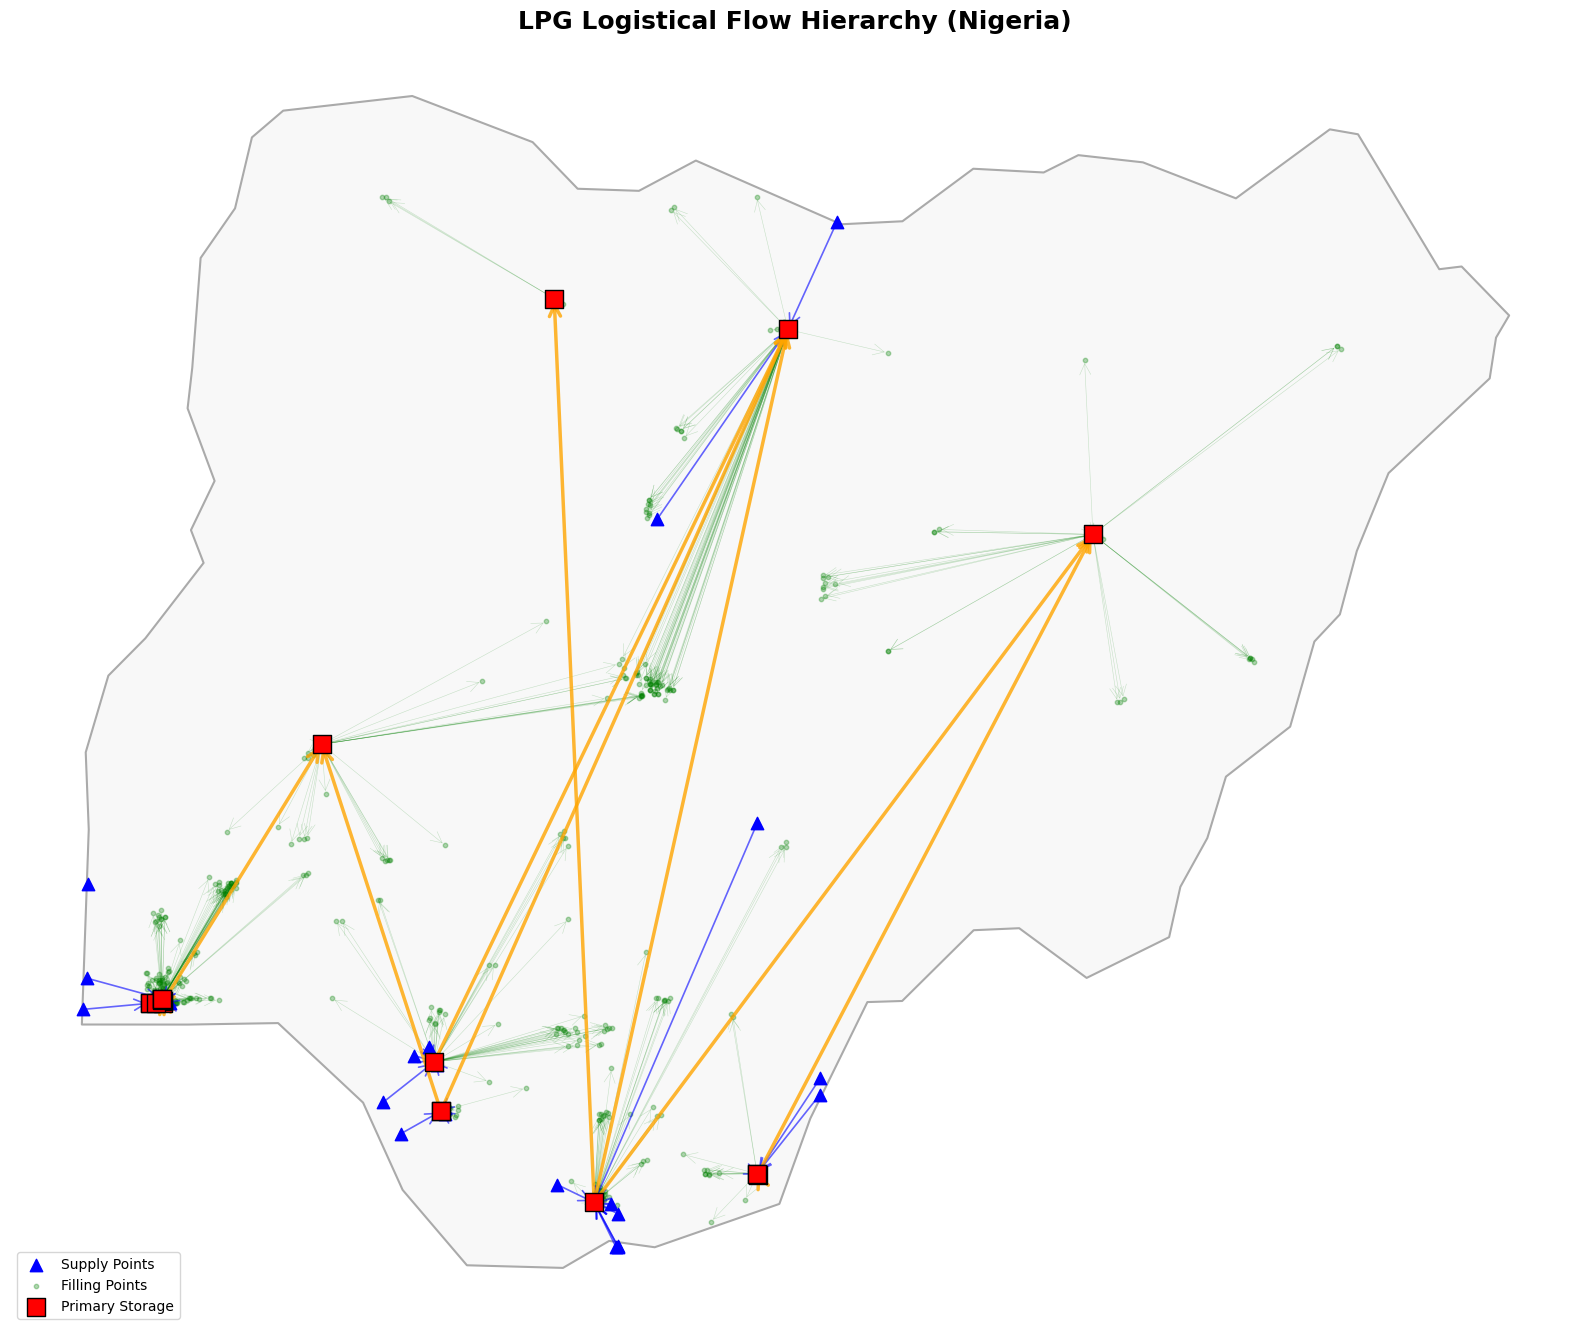

saved in: dataset\chart_4.1_flows.png


In [26]:
# Visualization of LPG supply chain with directional arrows:
# Blue: Source to Storage | Orange: Rebalancing | Green: Storage to Filling

warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS.*')

# 1. Load Data & Align CRS
ps = points['primary_storage'].copy()
if 'filling_points' in points and points['filling_points'] is not None:
    filling = points['filling_points'].copy()
else:
    filling_path = Path("dataset/filling_point_assigned.gpkg")
    filling = gpd.read_file(filling_path)

# Ensure CRS alignment
if filling.crs != ps.crs:
    filling = filling.to_crs(ps.crs)

# 2. Load Nigeria Background
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/NGA.geo.json"
nigeria_bg = gpd.read_file(url).to_crs(ps.crs)
print("Background map downloaded.")

# 3. Collect Supply Layers
supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
supply_list = []
for lyr in supply_layers:
    gdf = points.get(lyr)
    if gdf is None or gdf.empty:
        continue
    if gdf.crs != ps.crs:
        gdf = gdf.to_crs(ps.crs)
    supply_list.append(gdf)

supply = pd.concat(supply_list, ignore_index=True) if supply_list else gpd.GeoDataFrame()
ps_dict = {row['id_supply']: row.geometry.centroid for _, row in ps.iterrows()}

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 16))

# Plot Background
if nigeria_bg is not None and not nigeria_bg.empty:
    nigeria_bg.plot(ax=ax, color='#f8f8f8', edgecolor='#aaaaaa', linewidth=1.5, zorder=0)
else:
    ax.set_facecolor('#fafafa')

def draw_arrow(start, end, color, lw, alpha, zorder=2, head_width=0.08):
    """
    Draw a styled arrow between two point geometries on the map.
    Uses annotate for consistent arrowheads and z-order control.
    Skips drawing when either endpoint is missing.
    Designed for readable, thin flow overlays.
    """
    if start is None or end is None:
        return
    ax.annotate("", xy=(end.x, end.y), xytext=(start.x, start.y),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw, 
                                alpha=alpha, shrinkA=2, shrinkB=2, 
                                mutation_scale=20), zorder=zorder)

# 4. Draw Flows as Arrows
# A. Supply -> Primary Storage (Blue)
for _, row in supply.iterrows():
    tid = str(row.get('tank_id_supply', ''))
    if tid in ps_dict:
        draw_arrow(row.geometry.centroid, ps_dict[tid], 'blue', 1.2, 0.6)

# B. Rebalancing (Orange) - Thicker arrows
if 'allocation_matrix' in globals() and 'n_storage' in globals():
    for i in range(n_storage):
        for j in range(n_storage):
            if i != j and allocation_matrix[i, j] > 0.001:
                draw_arrow(ps.iloc[i].geometry.centroid, ps.iloc[j].geometry.centroid, 
                           'orange', 2.5, 0.8, zorder=3)

# C. Primary -> Filling (Green) - Subtle arrows
for _, row in filling.iterrows():
    tid = str(row.get('tank_id_supply', ''))
    if tid in ps_dict:
        draw_arrow(ps_dict[tid], row.geometry.centroid, 'green', 0.4, 0.2, zorder=1)

# 5. Plot Infrastructure Points
if not supply.empty:
    supply.centroid.plot(ax=ax, color='blue', marker='^', markersize=80, label='Supply Points', zorder=4)
filling.centroid.plot(ax=ax, color='green', marker='o', markersize=10, alpha=0.3, label='Filling Points', zorder=1)
ps.centroid.plot(ax=ax, color='red', marker='s', markersize=150, edgecolor='black', label='Primary Storage', zorder=5)

# Formatting
ax.set_title('LPG Logistical Flow Hierarchy (Nigeria)', fontsize=18, fontweight='bold')
ax.axis('off')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower left', frameon=True)

plt.tight_layout()

output_image_path = data_dir / "chart_4.1_flows.png"

plt.savefig(output_image_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print(f"saved in: {output_image_path}")

# Final export of all layers to first_step.gpkg
save_first_step(points, "final export")

### 4.2. Cost components bar and pie

Charts saved:
  - dataset\chart_4.2.1_complete_cost.png
  - dataset\chart_4.2.2_logistics_cost.png
  - dataset\chart_4.2.3_transport_pie.png


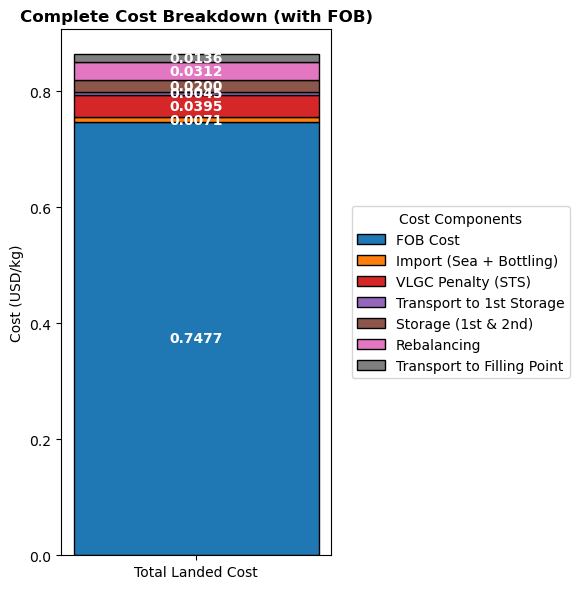

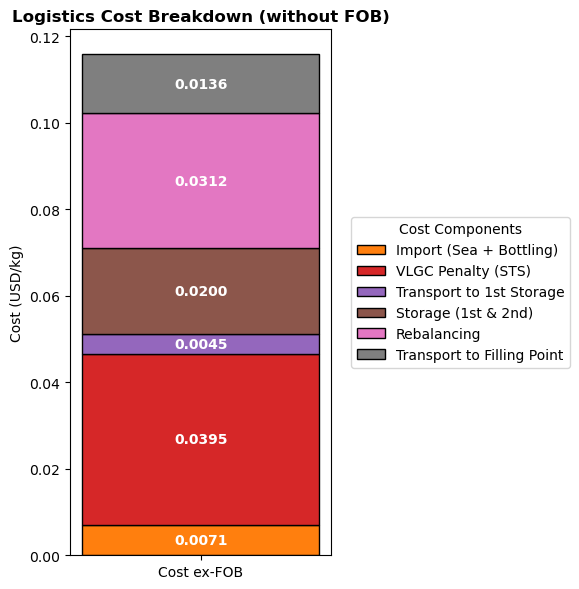

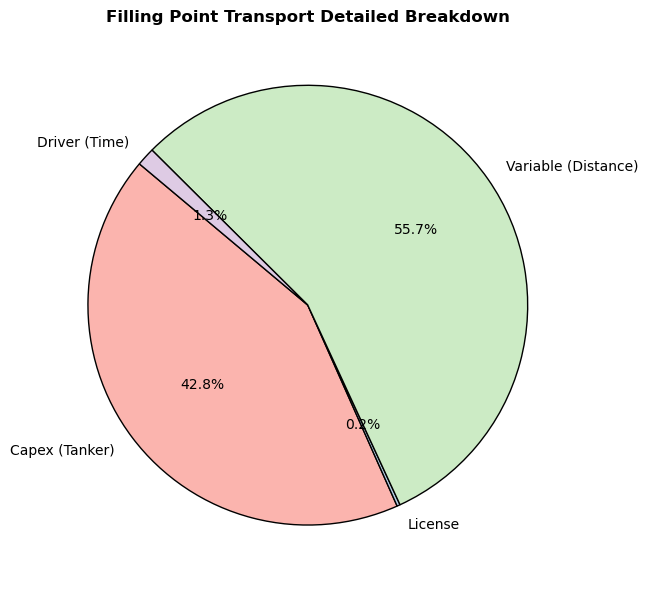

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load data
filling = points['filling_points'].copy()

# Calculate actual weighted averages directly from the filling points layer
# Grouping similar sub-components for the plot as per your original logic
avg_import_sea = filling['cost_import_sea'].fillna(0).mean()
avg_pre_bottling = filling['cost_pre_bottling'].fillna(0).mean()
avg_sts = filling['cost_sts'].fillna(0).mean()
avg_import_land = filling['cost_import_land'].fillna(0).mean() + filling['cost_border_wait'].fillna(0).mean() + filling['cost_ferry'].fillna(0).mean()
avg_transp1 = filling['cost_transport_to_storage'].fillna(0).mean()
avg_storage_total = filling['cost_storage'].fillna(0).mean() + filling['cost_storage_second'].fillna(0).mean()
avg_rebal = filling['cost_rebalancing'].fillna(0).mean()
avg_transp2 = filling['cost_transport_from_storage'].fillna(0).mean()
avg_fob = filling['cost_source'].fillna(0).mean()  

cost_components = {
    'FOB Cost': avg_fob,
    'Import (Sea + Bottling)': avg_import_sea,
    'Import (Land + Border)': avg_import_land,
    'VLGC Penalty (STS)': avg_sts,
    'Transport to 1st Storage': avg_transp1,
    'Storage (1st & 2nd)': avg_storage_total,
    'Rebalancing': avg_rebal,
    'Transport to Filling Point': avg_transp2
}

# 2. Detailed breakdown

avg_dist_transp = filling['tank_distance'].fillna(0).mean()
avg_time_transp = filling['tank_traveltime'].fillna(0).mean()

effective_load_kg = tanker_capacity_kg * utilization_factor
variable_cost_per_km = 0.635
driver_hourly_cost_usd = (driver_annual_salary_usd * salary_multiplier) / (hours_per_day * days_per_year)
fixed_loading_unloading_hours = 1.0

annual_capital_cost_usd = tanker_overnight_cost_usd * crf(discount_rate, tanker_life_years)
annual_license_cost_usd = license_cost_usd * crf(discount_rate, licence_life_years)

# Using avg_dist_transp for the round trip calculation
avg_round_trip_km = 2.0 * avg_dist_transp
trips_per_year = tanker_annual_km / avg_round_trip_km if avg_round_trip_km > 0 else 1

capex_per_kg = annual_capital_cost_usd / (effective_load_kg * trips_per_year)
license_per_kg = annual_license_cost_usd / (effective_load_kg * trips_per_year)

round_trip_hours = (avg_time_transp * 2.0 / 60.0) + fixed_loading_unloading_hours
round_trip_distance_km = 2.0 * avg_dist_transp

distance_var_per_kg = (variable_cost_per_km * round_trip_distance_km) / effective_load_kg
driver_per_kg = (driver_hourly_cost_usd * round_trip_hours) / effective_load_kg

transport_components = {
    'Capex (Tanker)': capex_per_kg,
    'License': license_per_kg,
    'Variable (Distance)': distance_var_per_kg,
    'Driver (Time)': driver_per_kg
}

# 3. Plot

colors = plt.cm.tab10.colors
bar_width = 0.2 

# Chart 1: Complete Stacked Bar Chart (Total Cost)
fig1, ax1 = plt.subplots(figsize=(6, 6))
bottom_total = 0
for i, (key, value) in enumerate(cost_components.items()):
    if value > 0:  
        ax1.bar('Total Landed Cost', value, bottom=bottom_total, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        # Centered text inside the block
        ax1.text(0, bottom_total + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        bottom_total += value

ax1.set_title('Complete Cost Breakdown (with FOB)', fontweight='bold')
ax1.set_ylabel('Cost (USD/kg)')
ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
fig1.tight_layout()
out1 = data_dir / "chart_4.2.1_complete_cost.png"
fig1.savefig(out1, dpi=300, bbox_inches='tight')

# Chart 2: Stacked Bar Chart WITHOUT FOB
fig2, ax2 = plt.subplots(figsize=(6, 6))
bottom_ex_fob = 0
for i, (key, value) in enumerate(cost_components.items()):
    if key != 'FOB Cost' and value > 0:  
        ax2.bar('Cost ex-FOB', value, bottom=bottom_ex_fob, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        ax2.text(0, bottom_ex_fob + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        bottom_ex_fob += value

ax2.set_title('Logistics Cost Breakdown (without FOB)', fontweight='bold')
ax2.set_ylabel('Cost (USD/kg)')
ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
fig2.tight_layout()
out2 = data_dir / "chart_4.2.2_logistics_cost.png"
fig2.savefig(out2, dpi=300, bbox_inches='tight')

# Chart 3: Detailed Transport Breakdown (Pie Chart)
fig3, ax3 = plt.subplots(figsize=(7, 6))
ax3.pie(transport_components.values(), labels=transport_components.keys(), autopct='%1.1f%%', 
        colors=plt.cm.Pastel1.colors, startangle=140, wedgeprops={'edgecolor': 'black'})
ax3.set_title('Filling Point Transport Detailed Breakdown', fontweight='bold')
fig3.tight_layout()
out3 = data_dir / "chart_4.2.3_transport_pie.png"
fig3.savefig(out3, dpi=300, bbox_inches='tight')

print(f"Charts saved:\n  - {out1}\n  - {out2}\n  - {out3}")